<a href="https://colab.research.google.com/github/smartdxgen/Den-SOFA/blob/main/Public_DEN_SOFA_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
 path='/content/drive/MyDrive/dentistry education/'

In [ ]:
!rm -rf /content/drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# -*- coding: utf-8 -*-
"""
DentalDataAnalyzer
------------------
Integrated data analysis pipeline for dental student performance datasets.

Features:
- Load & clean (column normalization, type conversion, derived features)
- EDA with plots + automatic numeric summaries & plain-language interpretations
- Statistical relationships: Pearson, Spearman, ANOVA, Kruskal-Wallis
- Effect size calculation (r, eta-squared)
- Random Forest feature importance + classification report
- Characteristics table with categorical breakdowns and chi-square / Fisher logic
- Export of characteristics table to CSV
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import re
from itertools import combinations

# stats
import scipy.stats as stats
from scipy.stats import f_oneway, pearsonr, spearmanr, kruskal, chi2_contingency

# ML
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report

warnings.filterwarnings("ignore")

# Plot defaults
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True


# ----------------------
# Utility helpers
# ----------------------
def _nice_col(col):
    """Normalize column name: strip, collapse whitespace, remove odd chars, lower, replace spaces with underscore."""
    s = str(col).strip()
    s = re.sub(r'\s+', '_', s)
    s = re.sub(r'[^\w_]', '', s)
    s = s.lower()
    return s

def format_p(p):
    if pd.isna(p):
        return "N/A"
    if p < 0.001:
        return "<0.001"
    return f"{p:.3f}"

def interpret_correlation(r):
    if pd.isna(r):
        return "N/A"
    if r >= 0.5: return "Large (strong positive)"
    if r >= 0.3: return "Medium (moderate positive)"
    if r >= 0.1: return "Small (weak positive)"
    if r <= -0.5: return "Large (strong negative)"
    if r <= -0.3: return "Medium (moderate negative)"
    if r <= -0.1: return "Small (weak negative)"
    return "Very small / negligible"

def interpret_eta2(e):
    if pd.isna(e): return "N/A"
    if e >= 0.14: return "Large"
    if e >= 0.06: return "Medium"
    if e >= 0.01: return "Small"
    return "Very small"


# ----------------------
# Main class
# ----------------------
class DentalDataAnalyzer:
    def __init__(self, file_path=None, df=None, target_col_candidates=('final score', 'final_score', 'finalscore')):
        if df is None and file_path is None:
            raise ValueError("Provide either file_path or df.")
        self.file_path = file_path
        self.raw_df = df
        self.df = None
        self.target_col_candidates = target_col_candidates
        self.results = {}
        if self.file_path:
            self.raw_df = pd.read_csv(self.file_path)
        if self.raw_df is not None:
            self.load_and_clean_data()

    # ----------------------
    # 1) Load & clean
    # ----------------------
    def load_and_clean_data(self):
        print("=== Load and clean data ===")
        df = self.raw_df.copy()
        col_map = {c: _nice_col(c) for c in df.columns}
        df.rename(columns=col_map, inplace=True)

        # find target column
        target_found = None
        for cand in self.target_col_candidates:
            cand_norm = _nice_col(cand)
            if cand_norm in df.columns:
                target_found = cand_norm
                break
        if target_found is None:
            for c in df.columns:
                if 'final' in c and 'score' in c:
                    target_found = c
                    break
        if target_found is None:
            raise KeyError("Could not find target column. Provide a column named like 'final score'.")

        df.rename(columns={target_found: 'final_score'}, inplace=True)

        # drop ID columns
        for possible_id in ['id', 'identifier', 'index']:
            if possible_id in df.columns:
                df.drop(possible_id, axis=1, inplace=True)

        numeric_candidates = [
            'age', 'entrance_exam_score', 'passed_units', 'faile_units', 'gpa',
            'theory1', 'theory2', 'anatomy', 'phantom', 'basic_sciences', 'final_score'
        ]
        for c in numeric_candidates:
            if c in df.columns:
                df[c] = pd.to_numeric(df[c], errors='coerce')

        df = df[~df['final_score'].isna()].copy()
        print(f"Remaining rows after dropping missing final_score: {len(df)}")

        df['final_status'] = df['final_score'].apply(lambda x: 'Pass' if x >= 12 else 'Fail')
        def _grade_cat(x):
            if pd.isna(x): return np.nan
            if x >= 17: return 'A (17-20)'
            if x >= 15: return 'B (15-17)'
            if x >= 12: return 'C (12-15)'
            if x >= 10: return 'D (10-12)'
            return 'F (<10)'
        df['grade_category'] = df['final_score'].apply(_grade_cat)

        if all(c in df.columns for c in ['theory1', 'theory2']):
            df['theory_avg'] = df[['theory1', 'theory2']].mean(axis=1)
        if all(c in df.columns for c in ['anatomy', 'phantom']):
            df['practical_avg'] = df[['anatomy', 'phantom']].mean(axis=1)
        if all(c in df.columns for c in ['passed_units', 'faile_units']):
            df['total_units'] = df['passed_units'] + df['faile_units']
            df['success_rate'] = df['passed_units'] / df['total_units'].replace({0: np.nan})

        self.df = df.reset_index(drop=True)
        print(f"✅ Cleaned data shape: {self.df.shape}")

    # ----------------------
    # 6) Characteristics table (updated bins)
    # ----------------------
    def create_characteristics_table(self, target_col='final_status', export_csv=None):
        df = self.df.copy()
        if target_col not in df.columns:
            print(f"Target column '{target_col}' not in data.")
            return None

        print(f"\nCreating characteristics table by '{target_col}'")

        # Updated bin functions
        def cat_age(x):
            if pd.isna(x): return 'Missing'
            if x <= 23: return '<=23'
            if x == 24: return '24'
            if x == 25: return '25'
            return '>=26'

        def cat_entrance(x):
            if pd.isna(x): return 'Missing'
            return '>9600' if x > 9600 else '<9600'

        def cat_gpa(x):
            if pd.isna(x): return 'Missing'
            if x < 16: return '<16'
            if x < 16.5: return '16-16.5'
            if x < 17: return '16.5-17'
            return '>=17'

        def cat_score16(x):
            if pd.isna(x): return 'Missing'
            if x < 14: return '<14'
            if x < 16: return '14-16'
            return '>=16'

        def cat_anatomy(x):
            if pd.isna(x): return 'Missing'
            if x < 16: return '<16'
            if x < 18: return '16-18'
            return '>=18'

        def cat_basic_sciences(x):
            if pd.isna(x): return 'Missing'
            if x < 74: return '<74'
            if x <= 76: return '74-76'
            return '>=77'

        # Apply
        if 'age' in df.columns:
            df['age_cat'] = df['age'].apply(cat_age)
        if 'entrance_exam_score' in df.columns:
            df['entrance_cat'] = df['entrance_exam_score'].apply(cat_entrance)
        if 'gpa' in df.columns:
            df['gpa_cat'] = df['gpa'].apply(cat_gpa)
        if 'theory1' in df.columns:
            df['theory1_cat'] = df['theory1'].apply(cat_score16)
        if 'theory2' in df.columns:
            df['theory2_cat'] = df['theory2'].apply(cat_score16)
        if 'anatomy' in df.columns:
            df['anatomy_cat'] = df['anatomy'].apply(cat_anatomy)
        if 'phantom' in df.columns:
            df['phantom_cat'] = df['phantom'].apply(cat_score16)
        if 'basic_sciences' in df.columns:
            df['basic_sciences_cat'] = df['basic_sciences'].apply(cat_basic_sciences)

        # Feature list for table
        features = [
            ('gender', False), ('age_cat', True), ('entrance_cat', True), ('gpa_cat', True),
            ('theory1_cat', True), ('theory2_cat', True), ('anatomy_cat', True),
            ('phantom_cat', True), ('basic_sciences_cat', True), ('grade_category', False)
        ]

        df_filtered = df[df[target_col].notna()].copy()
        total_n = len(df_filtered)
        print(f"Total (non-missing {target_col}): {total_n}")

        for feat, is_cat in features:
            if feat not in df_filtered.columns: continue
            clean = df_filtered[[feat, target_col]].dropna()
            if clean.empty: continue
            tab = pd.crosstab(clean[feat], clean[target_col])
            try:
                if tab.shape[0] >= 2 and tab.shape[1] >= 2:
                    chi2, pval, dof, exp = chi2_contingency(tab)
                else:
                    pval = np.nan
            except Exception:
                pval = np.nan
            print("\n" + "-"*80)
            print(f"Feature: {feat} (N categories: {tab.shape[0]}) | p-value (chi2) = {format_p(pval)}")
            print(tab)

        # Export
        if export_csv:
            rows = []
            for feat, _ in features:
                if feat not in df_filtered.columns: continue
                clean = df_filtered[[feat, target_col]].dropna()
                if clean.empty: continue
                tab = pd.crosstab(clean[feat], clean[target_col])
                for cat in tab.index:
                    row = {'Feature': feat, 'Category': cat}
                    for col in tab.columns:
                        row[f'{col}_count'] = tab.loc[cat, col]
                    rows.append(row)
            if len(rows) > 0:
                out_df = pd.DataFrame(rows)
                out_df.to_csv(export_csv, index=False)
                print(f"\nCharacteristics exported to {export_csv}")
                return out_df
            else:
                print("No data to export.")
                return None


In [ ]:
analyzer = DentalDataAnalyzer(file_path=path+"dandan 1404-7-9.csv")
analyzer.load_and_clean_data()
corrected_df = analyzer.df  # داده پاک‌سازی و آماده‌شده
out_table = analyzer.create_characteristics_table(
    export_csv=path+"characteristics_final_status.csv"
)


=== Load and clean data ===
Remaining rows after dropping missing final_score: 96
✅ Cleaned data shape: (96, 31)
=== Load and clean data ===
Remaining rows after dropping missing final_score: 96
✅ Cleaned data shape: (96, 31)

Creating characteristics table by 'final_status'
Total (non-missing final_status): 96

--------------------------------------------------------------------------------
Feature: gender (N categories: 2) | p-value (chi2) = 0.287
final_status  Fail  Pass
gender                  
1               31    50
2                3    12

--------------------------------------------------------------------------------
Feature: age_cat (N categories: 4) | p-value (chi2) = 0.066
final_status  Fail  Pass
age_cat                 
24              10    15
25               4    15
<=23            15    14
>=26             5    18

--------------------------------------------------------------------------------
Feature: entrance_cat (N categories: 3) | p-value (chi2) = 0.486
final_s

In [ ]:
# -*- coding: utf-8 -*-
"""
Dental Data Preprocessing and Categorization (Updated)
-----------------------------------------------------
Steps:
1. Load data
2. Clean and preprocess
3. Categorize continuous and ordinal features
4. Export preprocessed dataset and characteristics table
5. Show distribution of each column
"""

import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
import re

# ==========================
# Helper functions
# ==========================
def _nice_col(col):
    """Normalize column names"""
    s = str(col).strip()
    s = re.sub(r'\s+', '_', s)
    s = re.sub(r'[^\w_]', '', s)
    return s.lower()

def format_p(p):
    if pd.isna(p): return "N/A"
    if p < 0.001: return "<0.001"
    return f"{p:.3f}"

def grade_label(x):
    if pd.isna(x): return 'Missing'
    if x >= 17: return 'A (17–20)'
    elif x >= 15: return 'B (15–17)'
    elif x >= 12: return 'C (12–15)'
    elif x >= 10: return 'D (10–12)'
    else: return 'F (<10)'

# ==========================
# Main Class
# ==========================
class DentalDataAnalyzer:
    def __init__(self, file_path):
        self.file_path = file_path
        self.df = None

    def load_and_clean_data(self):
        print("=== Loading and Cleaning Data ===")
        df = pd.read_csv(self.file_path)
        df.rename(columns={c: _nice_col(c) for c in df.columns}, inplace=True)


        for c in ['id', 'index', 'identifier']:
            if c in df.columns:
                df.drop(columns=c, inplace=True)


        numeric_cols = [
            'age', 'entrance_exam_score', 'gpa', 'theory1', 'theory2',
            'anatomy', 'phantom', 'basic_sciences', 'final_score',
            'faile__units', 'passed__units'
        ]
        for c in numeric_cols:
            if c in df.columns:
                df[c] = pd.to_numeric(df[c], errors='coerce')

        df = df.dropna(subset=['final_score']).copy()


        df['final_status'] = df['final_score'].apply(lambda x: 'Pass' if x >= 12 else 'Fail')
        df['grade_category'] = df['final_score'].apply(grade_label)


        df['theory_avg'] = df[['theory1', 'theory2']].mean(axis=1)
        df['practical_avg'] = df[['anatomy', 'phantom']].mean(axis=1)


        df['theory_avg_cat'] = df['theory_avg'].apply(grade_label)
        df['practical_avg_cat'] = df['practical_avg'].apply(grade_label)

        print(f"✅ Cleaned data shape: {df.shape}")
        self.df = df

    def categorize_and_export(self, export_preprocessed, export_characteristics):
        df = self.df.copy()


        def cat_age(x):
            if pd.isna(x): return 'Missing'
            if x <= 23: return '<=23'
            if x == 24: return '24'
            if x == 25: return '25'
            return '>=26'

        def cat_entrance(x):
            if pd.isna(x): return 'Missing'
            return '>9600' if x > 9600 else '<9600'

        def cat_gpa(x):
            if pd.isna(x): return 'Missing'
            if x < 16: return '<16'
            if x < 16.5: return '16–16.5'
            if x < 17: return '16.5–17'
            return '>=17'

        def cat_theory(x):
            if pd.isna(x): return 'Missing'
            if x < 14: return '<14'
            if x < 16: return '14–16'
            return '>=16'

        def cat_anatomy(x):
            if pd.isna(x): return 'Missing'
            if x < 16: return '<16'
            if x < 18: return '16–18'
            return '>=18'

        def cat_basic_sciences(x):
            if pd.isna(x): return 'Missing'
            if x < 74: return '<74'
            if x <= 76: return '74–76'
            return '>=77'

        def cat_birth_order(x):
            if pd.isna(x): return 'Missing'
            if x == 1: return '1'
            if x == 2: return '2'
            return '>=3'


        if 'age' in df.columns: df['age_cat'] = df['age'].apply(cat_age)
        if 'entrance_exam_score' in df.columns: df['entrance_cat'] = df['entrance_exam_score'].apply(cat_entrance)
        if 'gpa' in df.columns: df['gpa_cat'] = df['gpa'].apply(cat_gpa)
        if 'theory1' in df.columns: df['theory1_cat'] = df['theory1'].apply(cat_theory)
        if 'theory2' in df.columns: df['theory2_cat'] = df['theory2'].apply(cat_theory)
        if 'anatomy' in df.columns: df['anatomy_cat'] = df['anatomy'].apply(cat_anatomy)
        if 'phantom' in df.columns: df['phantom_cat'] = df['phantom'].apply(cat_theory)
        if 'basic_sciences' in df.columns: df['basic_sciences_cat'] = df['basic_sciences'].apply(cat_basic_sciences)
        if 'birth_order' in df.columns: df['birth_order_cat'] = df['birth_order'].apply(cat_birth_order)


        for col in ['faile__units', 'passed__units']:
            if col in df.columns:
                try:
                    df[f'{col}_cat'] = pd.qcut(df[col], q=3, duplicates='drop')
                except:
                    df[f'{col}_cat'] = np.nan


        df.to_csv(export_preprocessed, index=False)
        print(f"✅ Preprocessed data exported to: {export_preprocessed}")


        features = [
            'gender', 'birth_order_cat', 'age_cat', 'entrance_cat', 'gpa_cat',
            'theory_avg_cat', 'practical_avg_cat',
            'theory1_cat', 'theory2_cat', 'anatomy_cat', 'phantom_cat',
            'basic_sciences_cat', 'faile__units_cat', 'passed__units_cat', 'grade_category'
        ]

        rows = []
        for feat in features:
            if feat not in df.columns: continue
            tab = pd.crosstab(df[feat], df['final_status'])
            try:
                chi2, pval, _, _ = chi2_contingency(tab)
            except:
                pval = np.nan
            for cat in tab.index:
                row = {'Feature': feat, 'Category': cat, 'P-Value': format_p(pval)}
                total = tab.loc[cat].sum()
                for col in tab.columns:
                    row[f'{col}_Count'] = tab.loc[cat, col]
                    row[f'{col}_Percent'] = round(100 * tab.loc[cat, col] / len(df), 1)
                row['Total_%'] = round(100 * total / len(df), 1)
                rows.append(row)

        out_df = pd.DataFrame(rows)
        out_df.to_csv(export_characteristics, index=False)
        print(f"✅ Characteristics table exported to: {export_characteristics}")


        print("\n📊 Distribution of each column:\n" + "=" * 60)
        for col in df.columns:
            print(f"\n🔹 {col}")
            print(df[col].value_counts(dropna=False))
            print("-" * 60)

        return df, out_df

# ==========================
# RUN PIPELINE
# ==========================
path = '/content/drive/MyDrive/dentistry education/'
analyzer = DentalDataAnalyzer(file_path=path + 'dandan 1404-7-9.csv')

analyzer.load_and_clean_data()

pre_df, char_table = analyzer.categorize_and_export(
    export_preprocessed=path + 'preprocessed_dental_data.csv',
    export_characteristics=path + 'characteristics_final_status.csv'
)

print("\n🎯 Done! Preprocessed data, categories, and distributions are ready.")

=== Loading and Cleaning Data ===
✅ Cleaned data shape: (96, 33)
✅ Preprocessed data exported to: /content/drive/MyDrive/dentistry education/preprocessed_dental_data.csv
✅ Characteristics table exported to: /content/drive/MyDrive/dentistry education/characteristics_final_status.csv

📊 Distribution of each column:

🔹 age
age
23    26
24    25
25    19
26    15
27     6
22     3
28     1
29     1
Name: count, dtype: int64
------------------------------------------------------------

🔹 gender
gender
1    81
2    15
Name: count, dtype: int64
------------------------------------------------------------

🔹 academic_term
academic_term
9     38
11    34
12    24
Name: count, dtype: int64
------------------------------------------------------------

🔹 birth_order
birth_order
1    53
2    31
3     8
4     3
5     1
Name: count, dtype: int64
------------------------------------------------------------

🔹 regionquota
regionquota
2    42
1    31
3    17
      6
Name: count, dtype: int64
-----------

In [ ]:
# ---------------------------
# Load dataset
# ---------------------------
import pandas as pd
from sklearn.preprocessing import LabelEncoder

path = '/content/drive/MyDrive/dentistry education/'
df = pd.read_csv(path + 'cleaned_dental_data.csv')

# ---------------------------
# Features and target
# ---------------------------
features = [
    'gender', 'academic_term', 'birth_order', 'regionquota', 'quota',
    'scholarship', 'residence_in_tehran', 'exam__season',
    'theory_avg_cat', 'practical_avg_cat', 'age_cat', 'entrance_cat', 'gpa_cat',
    'theory1_cat', 'theory2_cat', 'anatomy_cat', 'phantom_cat',
    'basic_sciences_cat', 'birth_order_cat', 'faile__units_cat',
    'passed__units_cat'
]

target = 'final_status'

# ---------------------------
# Encode categorical features
# ---------------------------
df_encoded = df.copy()
for col in features:
    df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col].astype(str))

# ---------------------------
# Encode target
# ---------------------------
y = LabelEncoder().fit_transform(df_encoded[target].astype(str))  # 1D array
X = df_encoded[features].values

print("X shape:", X.shape)
print("y shape:", y.shape)  # Must be (n_samples,)

X shape: (92, 21)
y shape: (92,)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 7.1 MB/s eta 0:00:00
X shape: (92, 21)
y shape: (92,)
AUC: 0.864
Accuracy: 0.857
F1 Score: 0.882
Precision: 0.938
Recall: 0.833


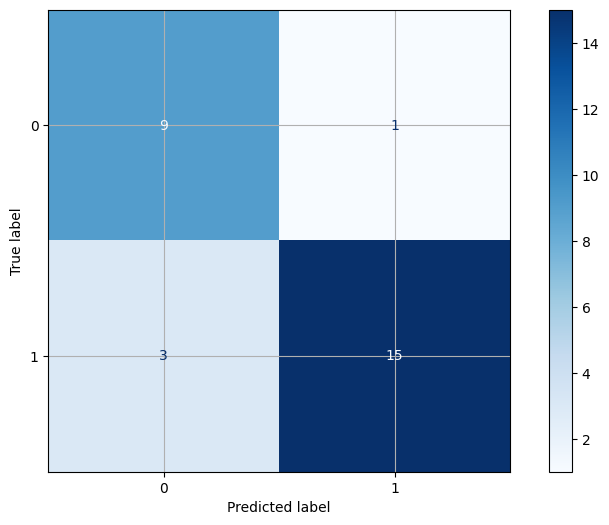

In [ ]:
# ---------------------------
# Packages
# ---------------------------
!pip install catboost -q

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# ---------------------------
# Load dataset
# ---------------------------
path = '/content/drive/MyDrive/dentistry education/'
df = pd.read_csv(path + 'cleaned_dental_data.csv')

# ---------------------------
# Features and target
# ---------------------------
features = [
    'gender', 'academic_term', 'birth_order', 'regionquota', 'quota',
    'scholarship', 'residence_in_tehran', 'exam__season',
    'theory_avg_cat', 'practical_avg_cat', 'age_cat', 'entrance_cat', 'gpa_cat',
    'theory1_cat', 'theory2_cat', 'anatomy_cat', 'phantom_cat',
    'basic_sciences_cat', 'birth_order_cat', 'faile__units_cat',
    'passed__units_cat'
]

target = 'final_status'

# ---------------------------
# Encode categorical features
# ---------------------------
df_encoded = df.copy()
for col in features:
    df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col].astype(str))

# Encode target as 1D
y = LabelEncoder().fit_transform(df_encoded[target].astype(str))
X = df_encoded[features].values

print("X shape:", X.shape)
print("y shape:", y.shape)

# ---------------------------
# Train/test split
# ---------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# ---------------------------
# Train a Random Forest as an example
# ---------------------------
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)

# ---------------------------
# Metrics
# ---------------------------
auc_score = roc_auc_score(y_test, y_proba[:,1])
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f"AUC: {auc_score:.3f}")
print(f"Accuracy: {acc:.3f}")
print(f"F1 Score: {f1:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")

# ---------------------------
# Confusion matrix
# ---------------------------
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.show()


Train/Test Distribution:


,Train (%),Test (%)
1,0.625,0.642857
0,0.375,0.357143


✅ Feature Distribution Table Saved Successfully!


,Feature,Category,Train (%),Test (%)
0,gender,1,81.2,96.4
1,gender,2,18.8,3.6
2,academic_term,9,37.5,46.4
3,academic_term,11,32.8,42.9
4,academic_term,12,29.7,10.7
5,birth_order,1,53.1,57.1
6,birth_order,2,34.4,28.6
7,birth_order,3,9.4,7.1
8,birth_order,4,3.1,3.6
9,birth_order,5,0.0,3.6


📂 Saved at: /content/drive/MyDrive/dentistry education/feature_distribution.csv


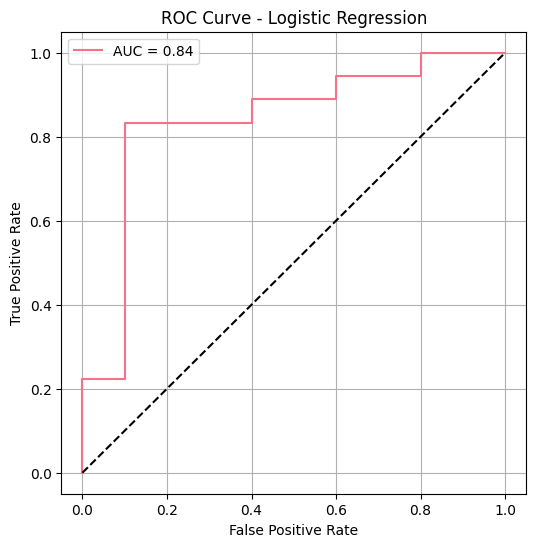

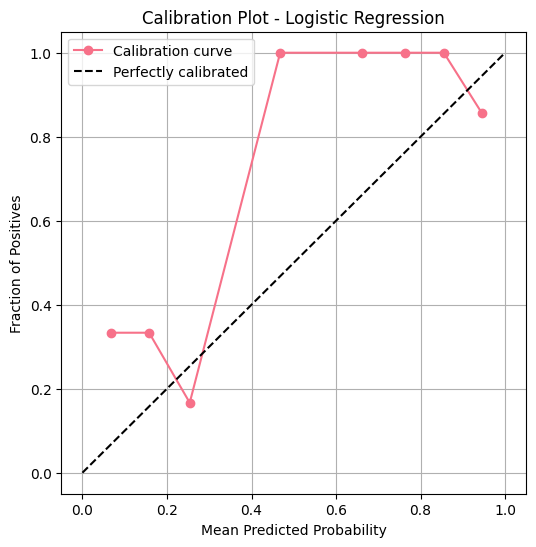

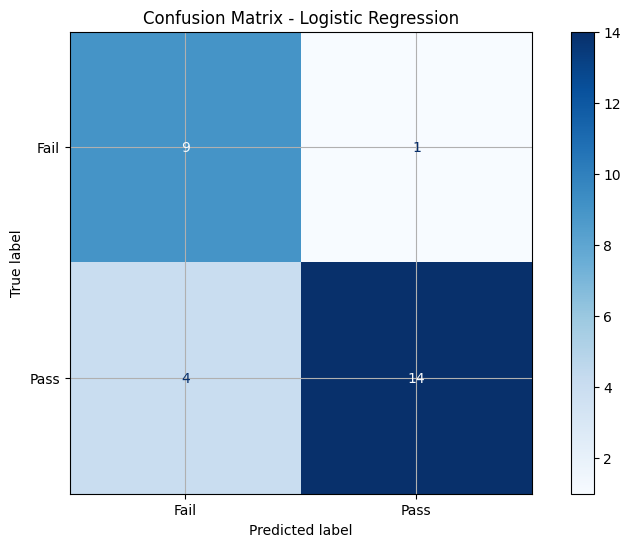

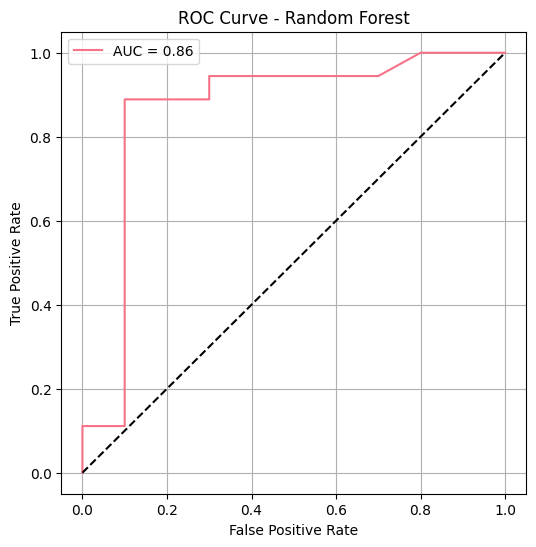

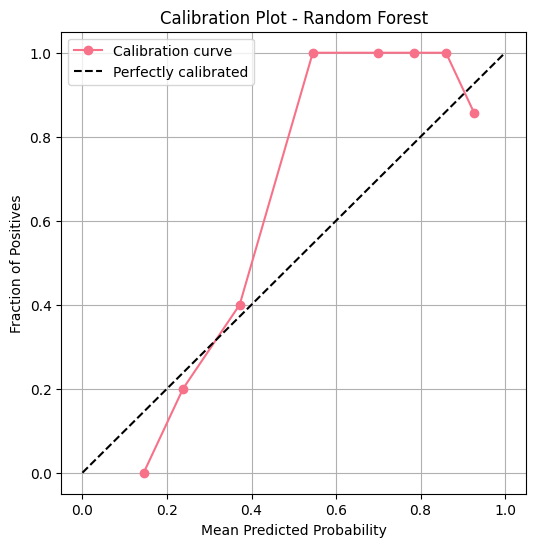

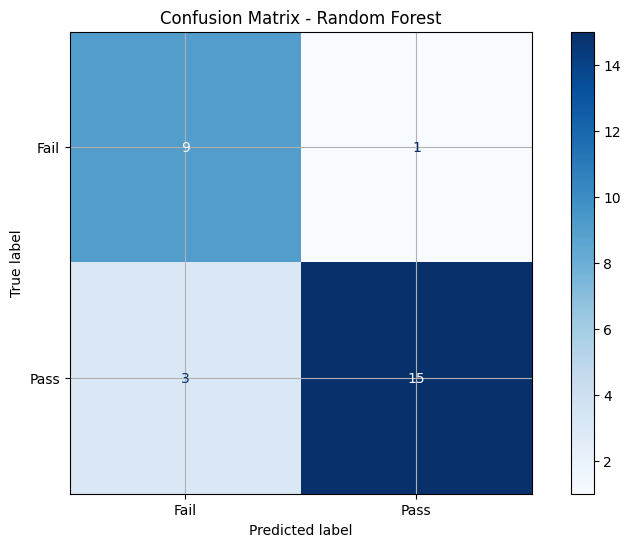

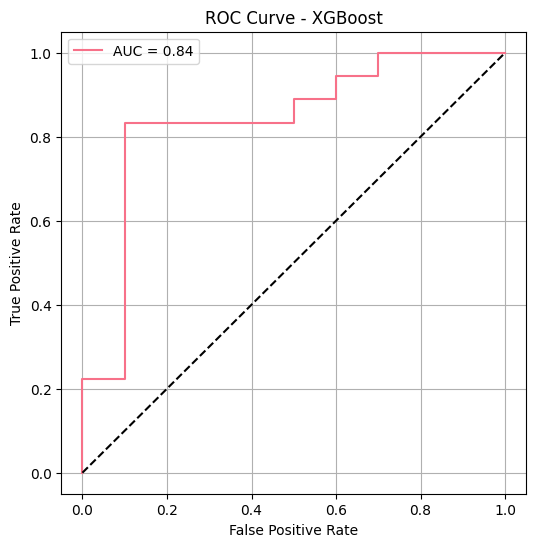

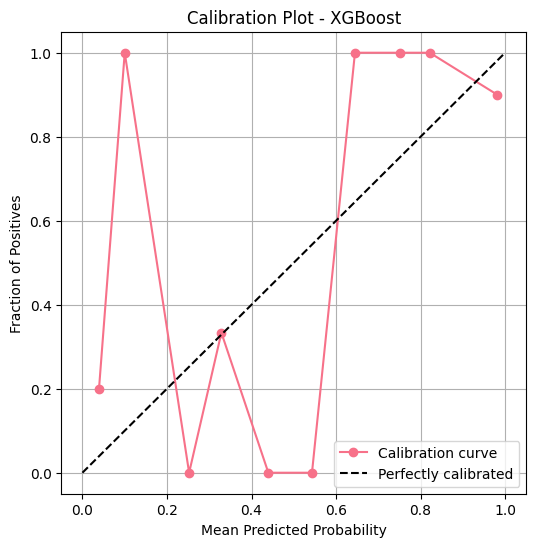

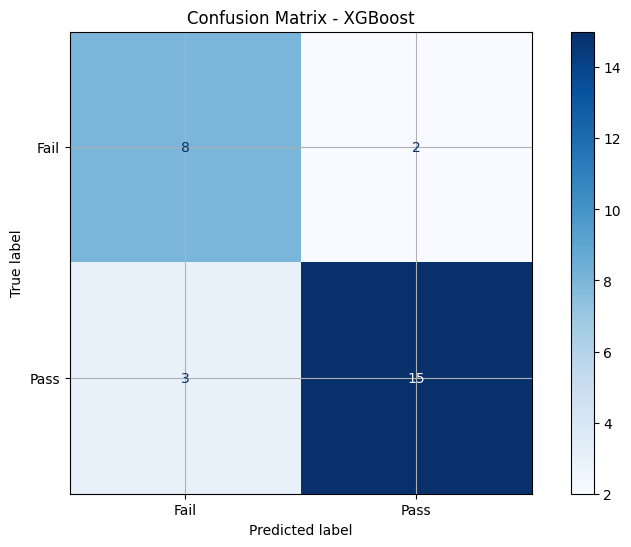

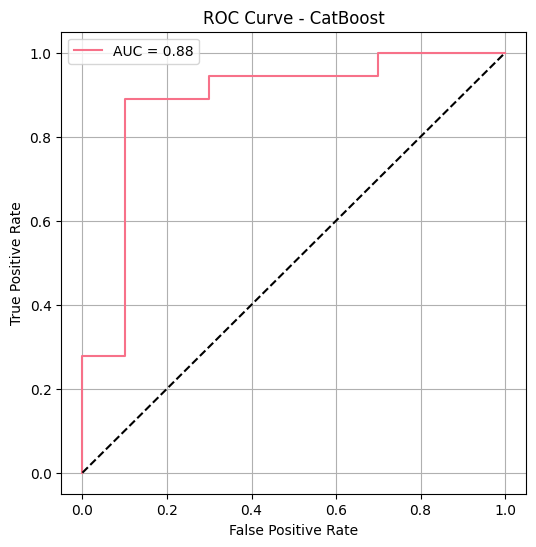

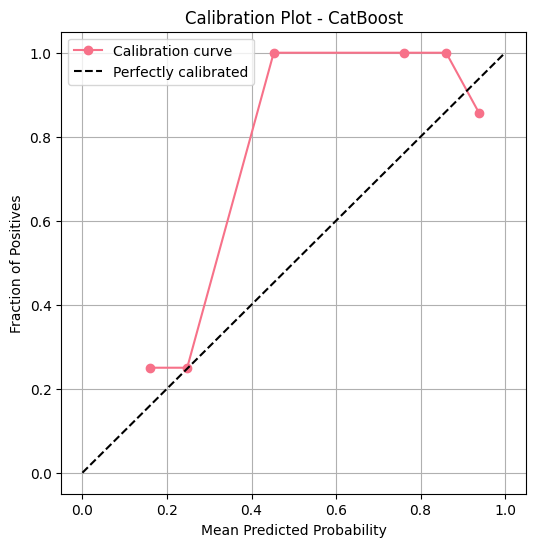

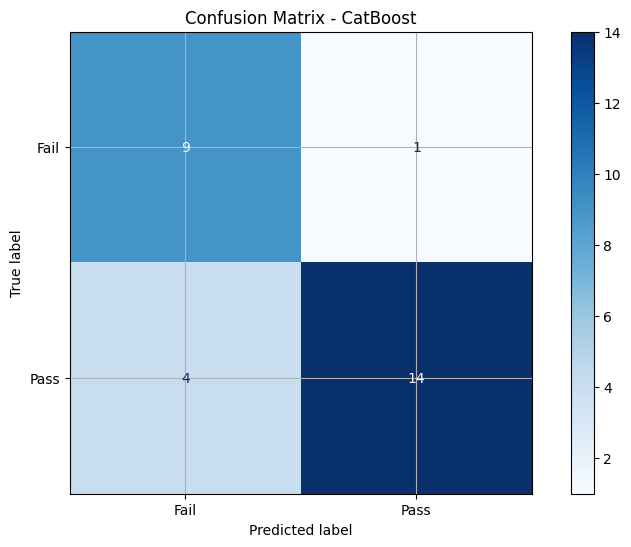

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step


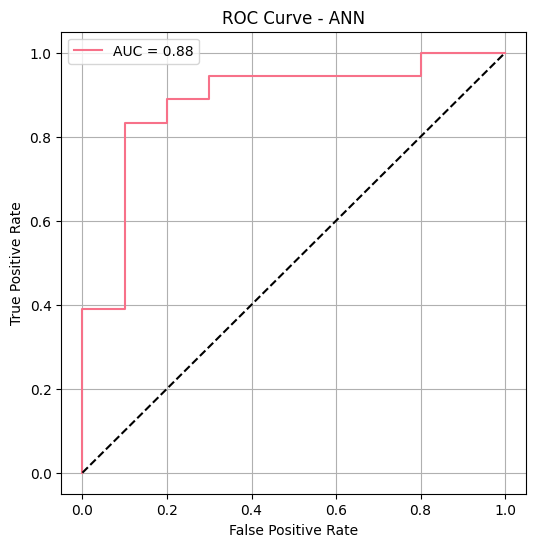

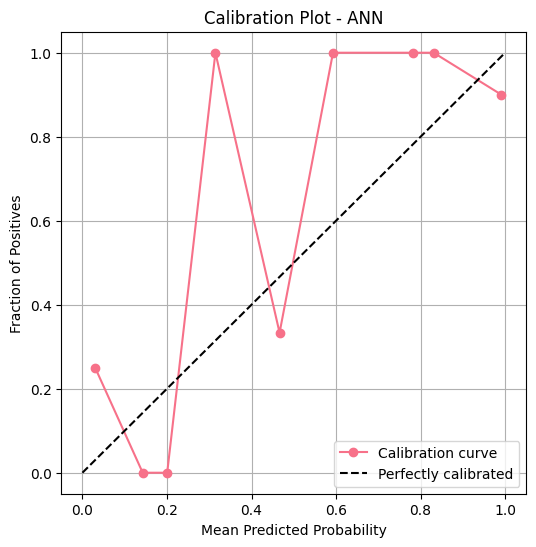

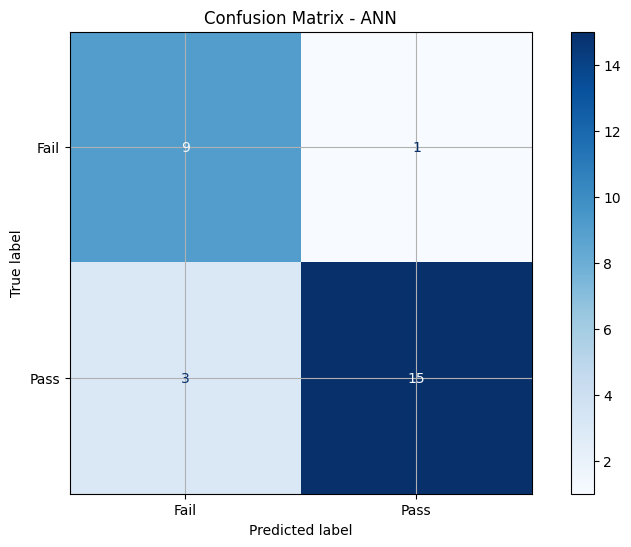

,Model,Accuracy,F1,Precision,Recall,Specificity,Sensitivity,AUC,MCC
4,ANN,0.857143,0.882353,0.937500,0.833333,0.9,0.833333,0.883333,0.710047
3,CatBoost,0.821429,0.848485,0.933333,0.777778,0.9,0.777778,0.883333,0.651188
1,Random Forest,0.857143,0.882353,0.937500,0.833333,0.9,0.833333,0.863889,0.710047
0,Logistic Regression,0.821429,0.848485,0.933333,0.777778,0.9,0.777778,0.838889,0.651188
2,XGBoost,0.821429,0.857143,0.882353,0.833333,0.8,0.833333,0.838889,0.621366


In [ ]:
# ---------------------------
# Packages
# ---------------------------
!pip install catboost -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    roc_auc_score, accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay, matthews_corrcoef,
    roc_curve, auc
)
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# ---------------------------
# Directories to save results
# ---------------------------
output_dir = '/content/drive/MyDrive/dentistry education/'
os.makedirs(output_dir, exist_ok=True)

# ---------------------------
# Load dataset
# ---------------------------
path = '/content/drive/MyDrive/dentistry education/'
df = pd.read_csv(path + 'cleaned_dental_data.csv')

# ---------------------------
# Features and target
# ---------------------------
features = [
    'gender', 'academic_term', 'birth_order', 'regionquota', 'quota',
    'scholarship', 'residence_in_tehran', 'exam__season',
    'theory_avg_cat', 'practical_avg_cat', 'age_cat', 'entrance_cat', 'gpa_cat',
    'theory1_cat', 'theory2_cat', 'anatomy_cat', 'phantom_cat',
    'basic_sciences_cat', 'birth_order_cat', 'faile__units_cat',
    'passed__units_cat'
]
target = 'final_status'

# ---------------------------
# Encode categorical features
# ---------------------------
df_encoded = df.copy()
for col in features:
    df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col].astype(str))

le_target = LabelEncoder()
y = le_target.fit_transform(df_encoded[target].astype(str))
X = df_encoded[features].values

# ---------------------------
# Train/test split
# ---------------------------
X_train, X_test, y_train, y_test, train_idx, test_idx = train_test_split(
    X, y, df.index, test_size=0.3, stratify=y, random_state=42
)

# ---------------------------
# Train/test distribution
# ---------------------------
train_dist = pd.Series(y_train).value_counts(normalize=True)
test_dist = pd.Series(y_test).value_counts(normalize=True)
distribution_df = pd.DataFrame({'Train (%)': train_dist, 'Test (%)': test_dist})
distribution_df.to_csv(os.path.join(output_dir, path+'train_test_distribution.csv'))
print("Train/Test Distribution:")
display(distribution_df)

# ---------------------------
# Feature distribution table
# ---------------------------
def feature_distribution_table(df, features, train_idx, test_idx, save_path):
    train_df = df.loc[train_idx]
    test_df = df.loc[test_idx]
    summary_rows = []

    for col in features:
        # If categorical or few unique values
        if df[col].dtype == 'object' or df[col].nunique() <= 10:
            train_counts = train_df[col].value_counts(normalize=True) * 100
            test_counts = test_df[col].value_counts(normalize=True) * 100
            all_categories = sorted(set(train_counts.index) | set(test_counts.index))
            for cat in all_categories:
                summary_rows.append({
                    "Feature": col,
                    "Category": cat,
                    "Train (%)": round(train_counts.get(cat, 0), 1),
                    "Test (%)": round(test_counts.get(cat, 0), 1)
                })
        else:
            # Continuous variable: show mean ± std
            summary_rows.append({
                "Feature": col,
                "Category": "Mean ± Std",
                "Train (%)": f"{train_df[col].mean():.2f} ± {train_df[col].std():.2f}",
                "Test (%)": f"{test_df[col].mean():.2f} ± {test_df[col].std():.2f}"
            })

    table = pd.DataFrame(summary_rows)
    table.to_csv(save_path, index=False)
    return table


# Generate and save
feature_dist_table = feature_distribution_table(
    df=df,
    features=features,
    train_idx=train_idx,
    test_idx=test_idx,
    save_path=os.path.join(output_dir, "feature_distribution.csv")
)

print("✅ Feature Distribution Table Saved Successfully!")
display(feature_dist_table.head(10))
print(f"📂 Saved at: {os.path.join(output_dir, 'feature_distribution.csv')}")

# ---------------------------
# Models
# ---------------------------
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss', use_label_encoder=False, random_state=42),
    "CatBoost": CatBoostClassifier(verbose=0, random_state=42),
}

# ---------------------------
# Helper functions
# ---------------------------
def plot_roc_curve(y_true, y_proba, model_name, save_path):
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(6,6))
    plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
    plt.plot([0,1], [0,1], 'k--')
    plt.title(f'ROC Curve - {model_name}')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.savefig(save_path)
    plt.show()

def plot_calibration(y_true, y_proba, model_name, save_path, n_bins=10):
    prob_true, prob_pred = calibration_curve(y_true, y_proba, n_bins=n_bins)
    plt.figure(figsize=(6,6))
    plt.plot(prob_pred, prob_true, marker='o', label='Calibration curve')
    plt.plot([0,1], [0,1], 'k--', label='Perfectly calibrated')
    plt.title(f'Calibration Plot - {model_name}')
    plt.xlabel('Mean Predicted Probability')
    plt.ylabel('Fraction of Positives')
    plt.legend()
    plt.savefig(save_path)
    plt.show()

# ---------------------------
# Evaluate models
# ---------------------------
results_list = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1]

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    auc_score = roc_auc_score(y_test, y_proba)
    mcc = matthews_corrcoef(y_test, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    specificity = tn / (tn + fp)
    sensitivity = recall

    results_list.append({
        "Model": name,
        "Accuracy": acc,
        "F1": f1,
        "Precision": precision,
        "Recall": recall,
        "Specificity": specificity,
        "Sensitivity": sensitivity,
        "AUC": auc_score,
        "MCC": mcc
    })

    # Save figures
    plot_roc_curve(y_test, y_proba, name, os.path.join(output_dir, f'ROC_{name}.png'))
    plot_calibration(y_test, y_proba, name, os.path.join(output_dir, f'Calibration_{name}.png'))

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_target.classes_)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f'Confusion Matrix - {name}')
    plt.savefig(os.path.join(output_dir, f'ConfusionMatrix_{name}.png'))
    plt.show()

# ---------------------------
# ANN
# ---------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
ann = Sequential([
    Dense(64, input_dim=X_train_scaled.shape[1], activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.1),
    Dense(1, activation='sigmoid')
])
ann.compile(optimizer=Adam(0.001), loss='binary_crossentropy', metrics=['accuracy'])
ann.fit(X_train_scaled, y_train, epochs=50, batch_size=8, verbose=0)

y_pred_ann = (ann.predict(X_test_scaled) > 0.5).astype(int).flatten()
y_proba_ann = ann.predict(X_test_scaled).flatten()

acc = accuracy_score(y_test, y_pred_ann)
f1 = f1_score(y_test, y_pred_ann)
precision = precision_score(y_test, y_pred_ann)
recall = recall_score(y_test, y_pred_ann)
auc_score = roc_auc_score(y_test, y_proba_ann)
mcc = matthews_corrcoef(y_test, y_pred_ann)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_ann).ravel()
specificity = tn / (tn + fp)
sensitivity = recall

results_list.append({
    "Model": "ANN",
    "Accuracy": acc,
    "F1": f1,
    "Precision": precision,
    "Recall": recall,
    "Specificity": specificity,
    "Sensitivity": sensitivity,
    "AUC": auc_score,
    "MCC": mcc
})

plot_roc_curve(y_test, y_proba_ann, "ANN", os.path.join(output_dir, f'ROC_ANN.png'))
plot_calibration(y_test, y_proba_ann, "ANN", os.path.join(output_dir, f'Calibration_ANN.png'))

cm = confusion_matrix(y_test, y_pred_ann)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_target.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix - ANN')
plt.savefig(os.path.join(output_dir, 'ConfusionMatrix_ANN.png'))
plt.show()

# ---------------------------
# Save results table
# ---------------------------
results_df = pd.DataFrame(results_list)
results_df.to_csv(os.path.join(output_dir, 'model_results.csv'), index=False)
display(results_df.sort_values(by='AUC', ascending=False))

Train/Test Distribution:


,Train (%),Test (%)
1,0.625,0.642857
0,0.375,0.357143



=== Training Logistic Regression ===


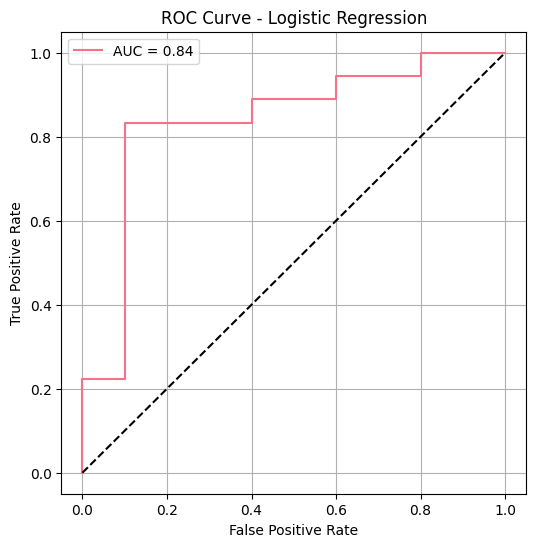

ROC AUC (Logistic Regression): 0.8389


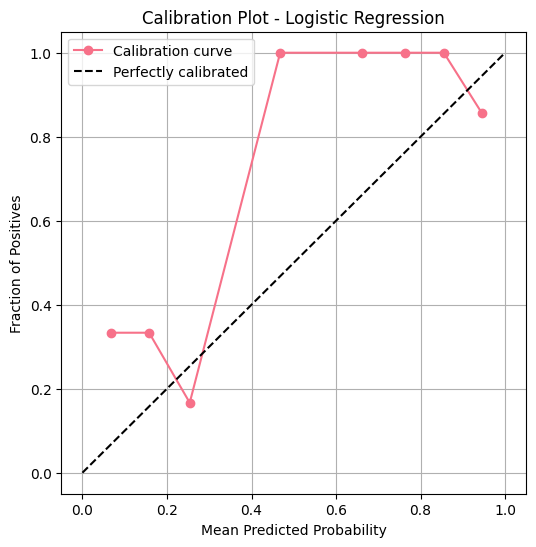

Calibration curve (Logistic Regression):
 Bin 1: Predicted=0.067, Actual=0.333
 Bin 2: Predicted=0.158, Actual=0.333
 Bin 3: Predicted=0.254, Actual=0.167
 Bin 4: Predicted=0.468, Actual=1.000
 Bin 5: Predicted=0.661, Actual=1.000
 Bin 6: Predicted=0.763, Actual=1.000
 Bin 7: Predicted=0.855, Actual=1.000
 Bin 8: Predicted=0.944, Actual=0.857


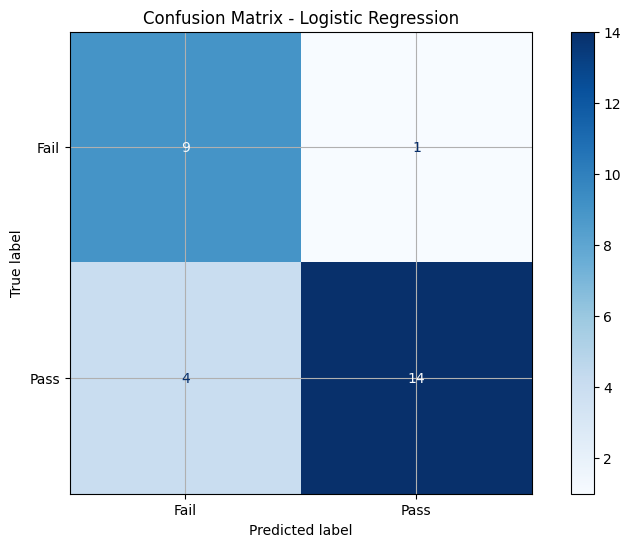

Confusion Matrix (Logistic Regression):
[[ 9  1]
 [ 4 14]]
Trained Parameters (Logistic Regression):
  C: 1.0
  class_weight: None
  dual: False
  fit_intercept: True
  intercept_scaling: 1
  l1_ratio: None
  max_iter: 1000
  multi_class: deprecated
  n_jobs: None
  penalty: l2
  random_state: None
  solver: lbfgs
  tol: 0.0001
  verbose: 0
  warm_start: False

=== Training Random Forest ===


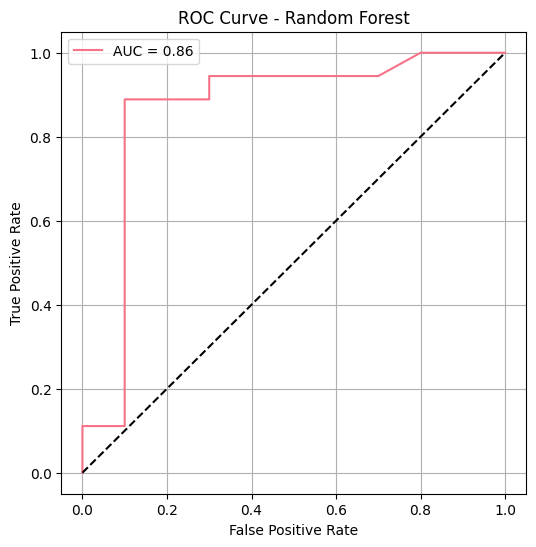

ROC AUC (Random Forest): 0.8639


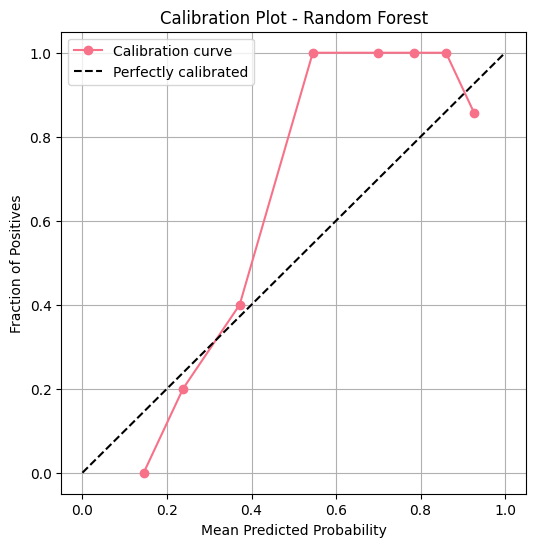

Calibration curve (Random Forest):
 Bin 1: Predicted=0.145, Actual=0.000
 Bin 2: Predicted=0.238, Actual=0.200
 Bin 3: Predicted=0.372, Actual=0.400
 Bin 4: Predicted=0.545, Actual=1.000
 Bin 5: Predicted=0.700, Actual=1.000
 Bin 6: Predicted=0.785, Actual=1.000
 Bin 7: Predicted=0.860, Actual=1.000
 Bin 8: Predicted=0.926, Actual=0.857


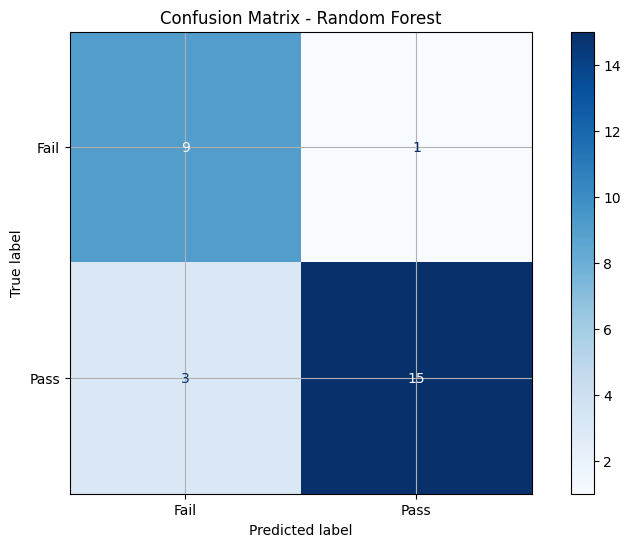

Confusion Matrix (Random Forest):
[[ 9  1]
 [ 3 15]]
Trained Parameters (Random Forest):
  bootstrap: True
  ccp_alpha: 0.0
  class_weight: None
  criterion: gini
  max_depth: None
  max_features: sqrt
  max_leaf_nodes: None
  max_samples: None
  min_impurity_decrease: 0.0
  min_samples_leaf: 1
  min_samples_split: 2
  min_weight_fraction_leaf: 0.0
  monotonic_cst: None
  n_estimators: 200
  n_jobs: None
  oob_score: False
  random_state: 42
  verbose: 0
  warm_start: False

=== Training XGBoost ===


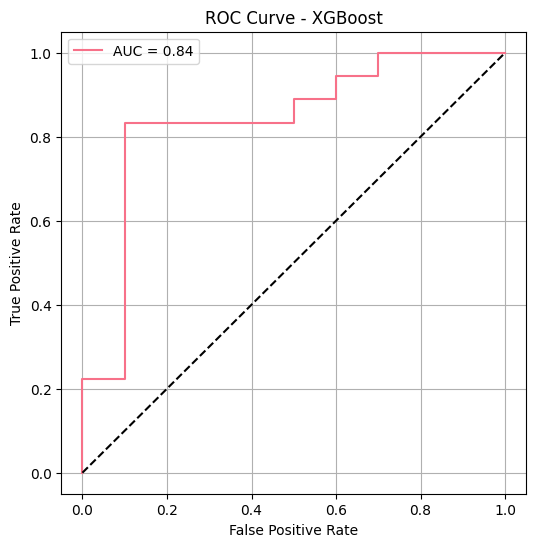

ROC AUC (XGBoost): 0.8389


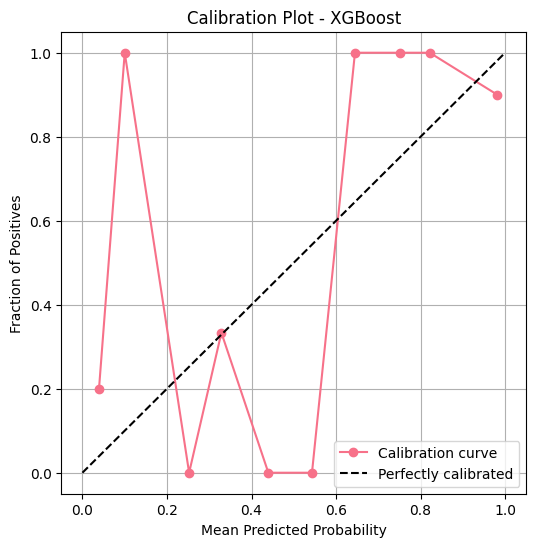

Calibration curve (XGBoost):
 Bin 1: Predicted=0.039, Actual=0.200
 Bin 2: Predicted=0.100, Actual=1.000
 Bin 3: Predicted=0.252, Actual=0.000
 Bin 4: Predicted=0.329, Actual=0.333
 Bin 5: Predicted=0.440, Actual=0.000
 Bin 6: Predicted=0.543, Actual=0.000
 Bin 7: Predicted=0.645, Actual=1.000
 Bin 8: Predicted=0.751, Actual=1.000
 Bin 9: Predicted=0.822, Actual=1.000
 Bin 10: Predicted=0.981, Actual=0.900


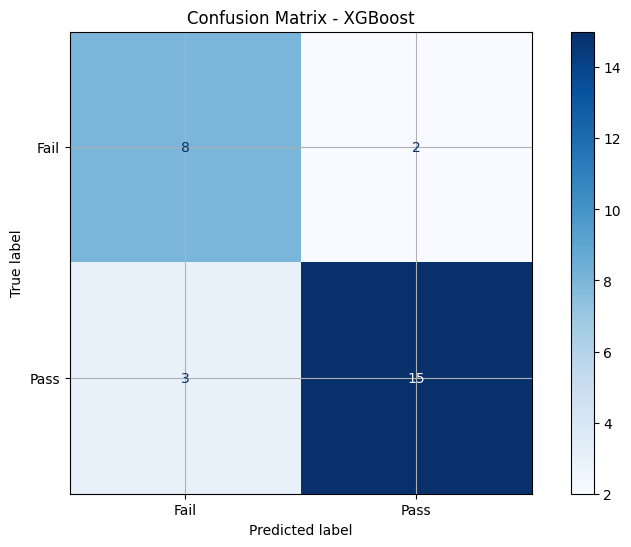

Confusion Matrix (XGBoost):
[[ 8  2]
 [ 3 15]]
Trained Parameters (XGBoost):
  objective: binary:logistic
  base_score: None
  booster: None
  callbacks: None
  colsample_bylevel: None
  colsample_bynode: None
  colsample_bytree: None
  device: None
  early_stopping_rounds: None
  enable_categorical: False
  eval_metric: logloss
  feature_types: None
  feature_weights: None
  gamma: None
  grow_policy: None
  importance_type: None
  interaction_constraints: None
  learning_rate: None
  max_bin: None
  max_cat_threshold: None
  max_cat_to_onehot: None
  max_delta_step: None
  max_depth: None
  max_leaves: None
  min_child_weight: None
  missing: nan
  monotone_constraints: None
  multi_strategy: None
  n_estimators: None
  n_jobs: None
  num_parallel_tree: None
  random_state: 42
  reg_alpha: None
  reg_lambda: None
  sampling_method: None
  scale_pos_weight: None
  subsample: None
  tree_method: None
  validate_parameters: None
  verbosity: None
  use_label_encoder: False

=== Training

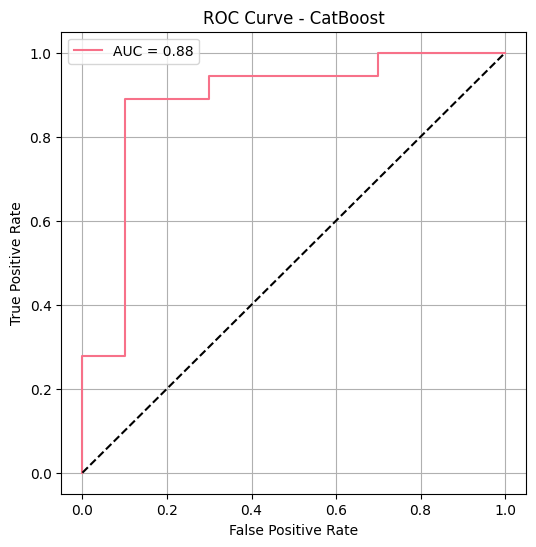

ROC AUC (CatBoost): 0.8833


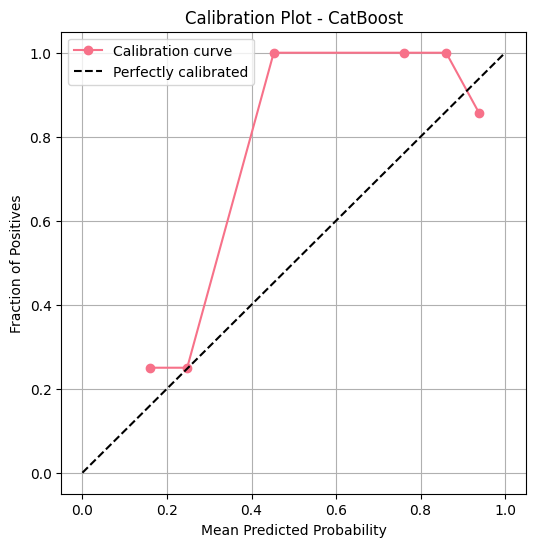

Calibration curve (CatBoost):
 Bin 1: Predicted=0.159, Actual=0.250
 Bin 2: Predicted=0.248, Actual=0.250
 Bin 3: Predicted=0.453, Actual=1.000
 Bin 4: Predicted=0.761, Actual=1.000
 Bin 5: Predicted=0.860, Actual=1.000
 Bin 6: Predicted=0.938, Actual=0.857


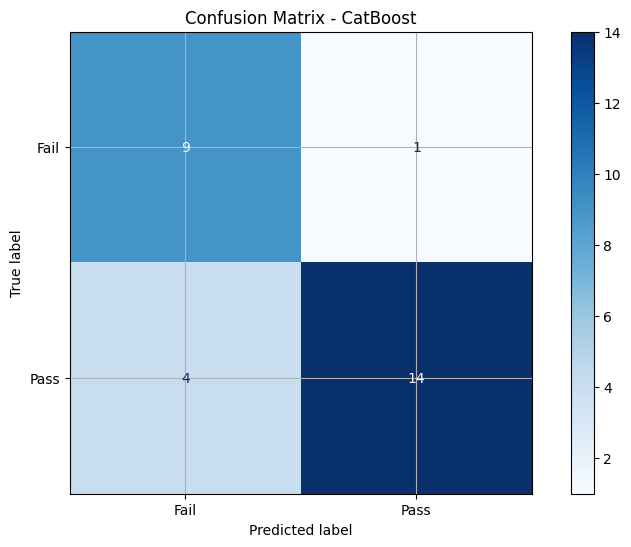

Confusion Matrix (CatBoost):
[[ 9  1]
 [ 4 14]]
Trained Parameters (CatBoost):
  verbose: 0
  random_state: 42


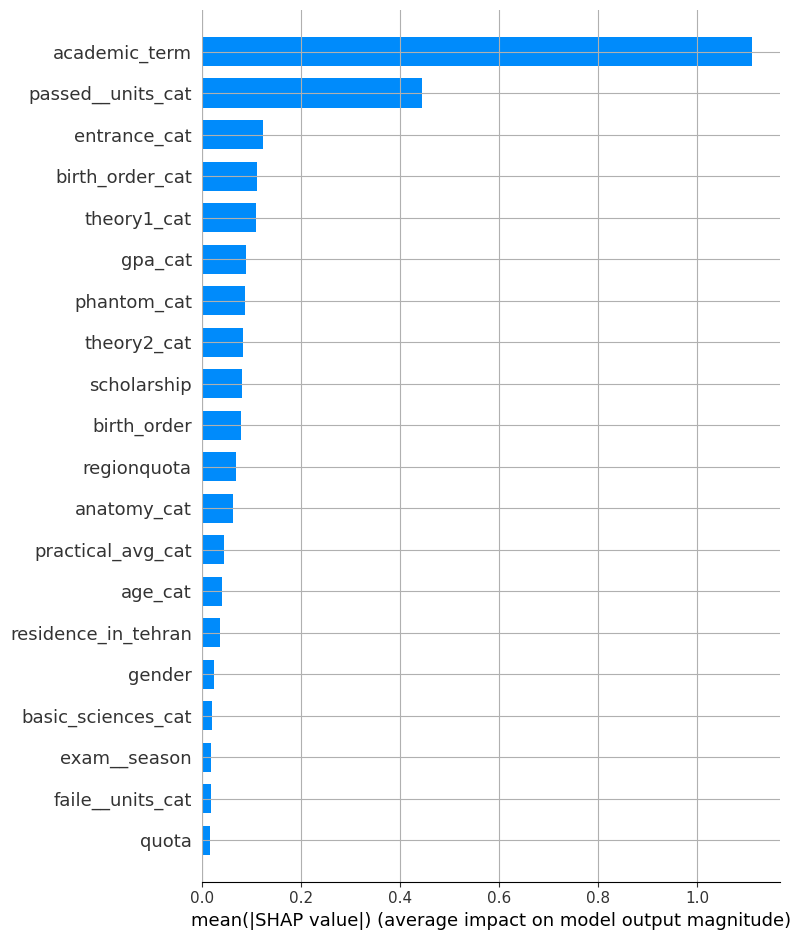

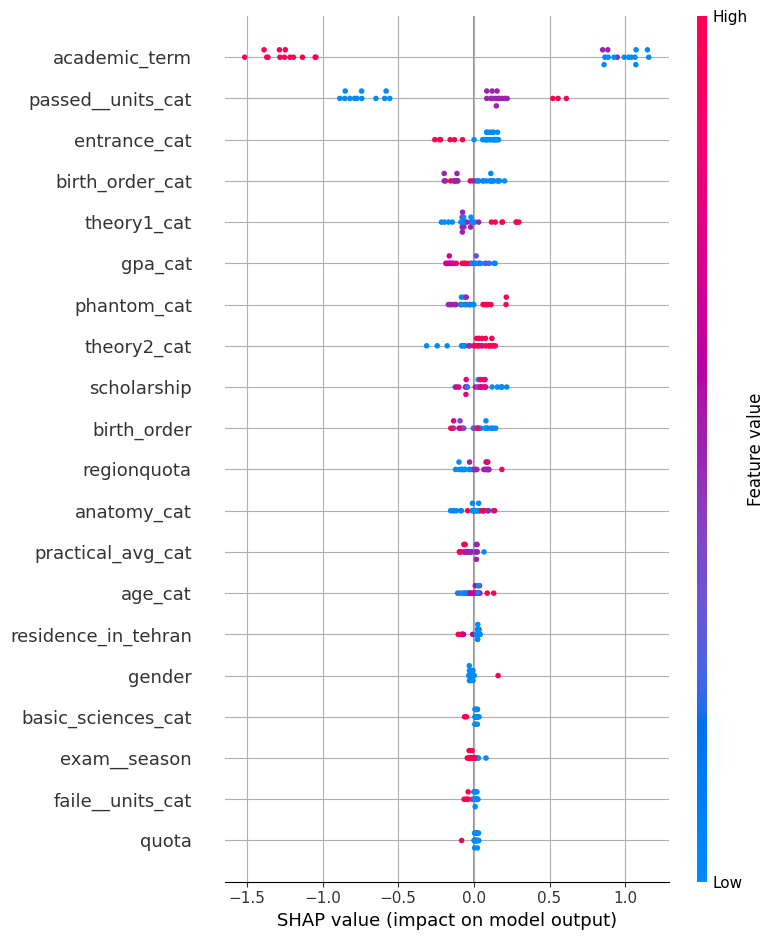

Explaining prediction for Pass student (index 0)


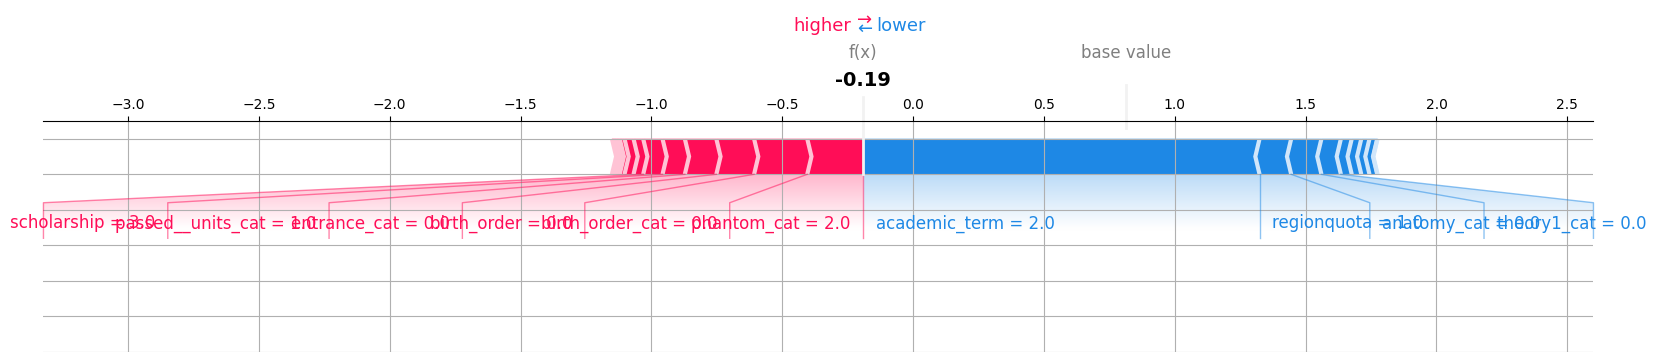

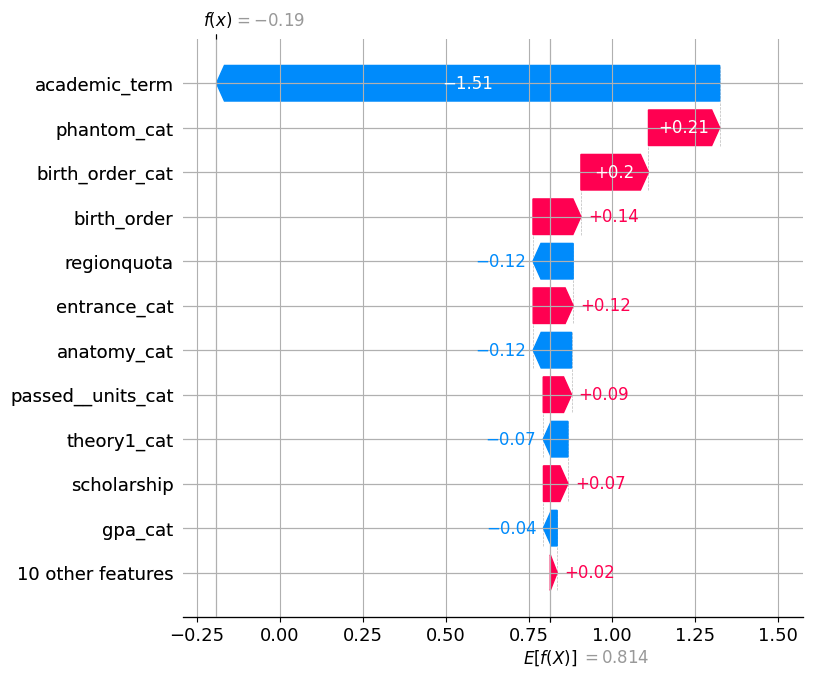

Explaining prediction for Fail student (index 1)


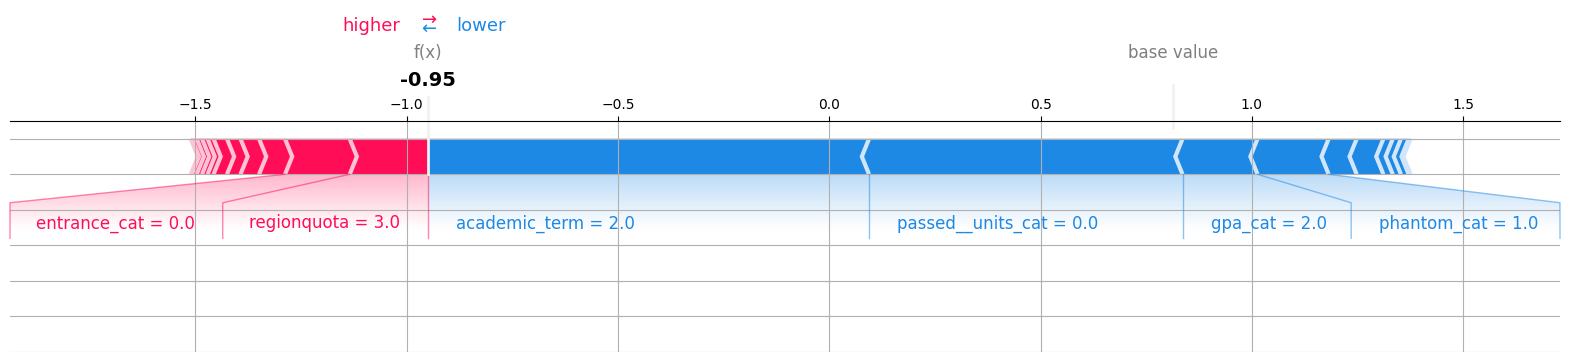

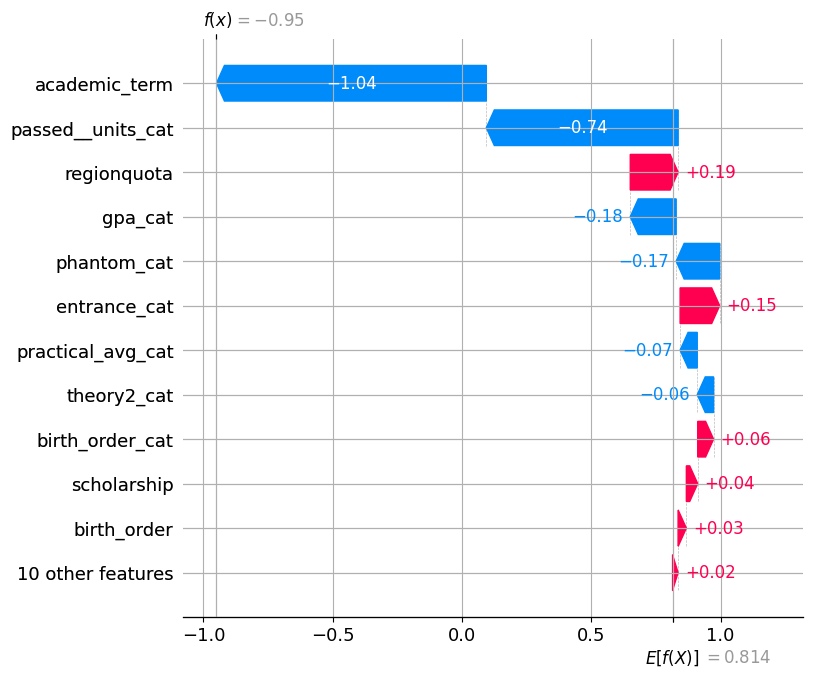


--- SHAP Analysis for CatBoost ---


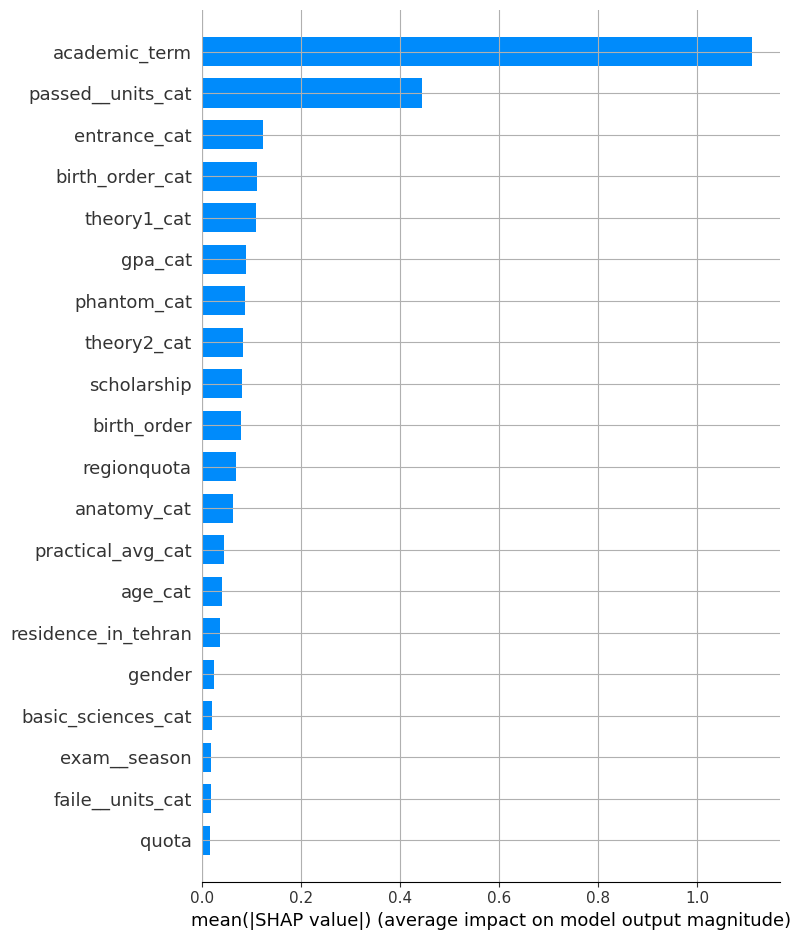

SHAP Summary (bar plot): Shows the average magnitude of feature contributions to the model output.



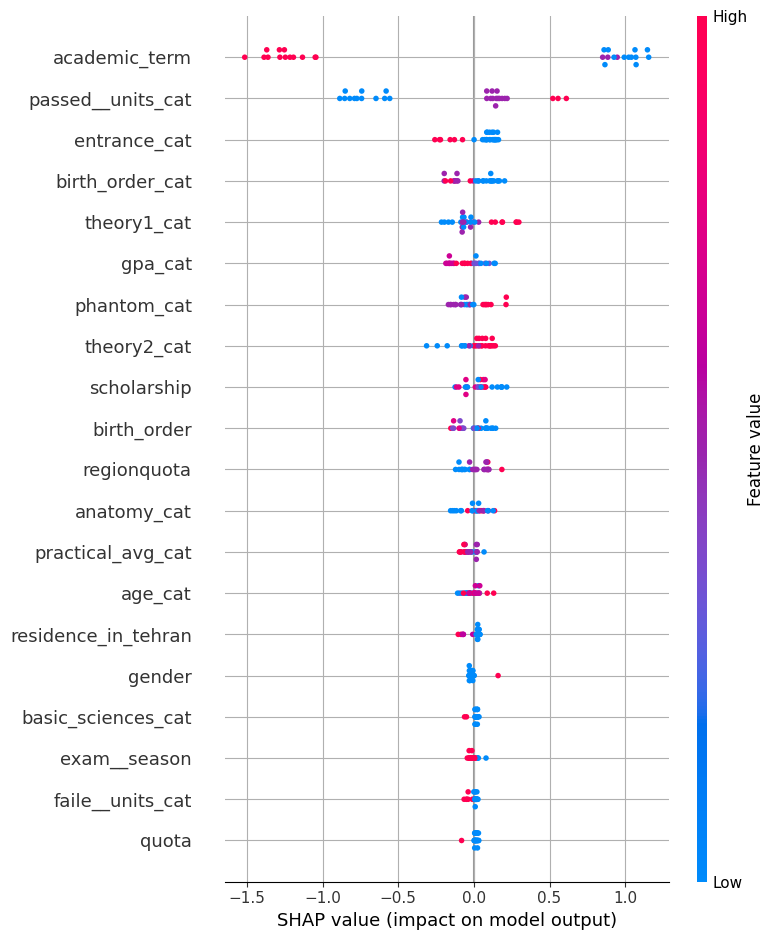

SHAP Summary (beeswarm plot): Displays both magnitude and direction of feature impact on predictions.

Global SHAP values (mean absolute per feature):


,Feature,Mean_ABS_SHAP_Value
1,academic_term,1.111266
20,passed__units_cat,0.443816
11,entrance_cat,0.123882
18,birth_order_cat,0.112226
13,theory1_cat,0.110035
12,gpa_cat,0.089178
16,phantom_cat,0.088127
14,theory2_cat,0.084057
5,scholarship,0.082461
2,birth_order,0.079517



Local explanation for Pass student (index 0)


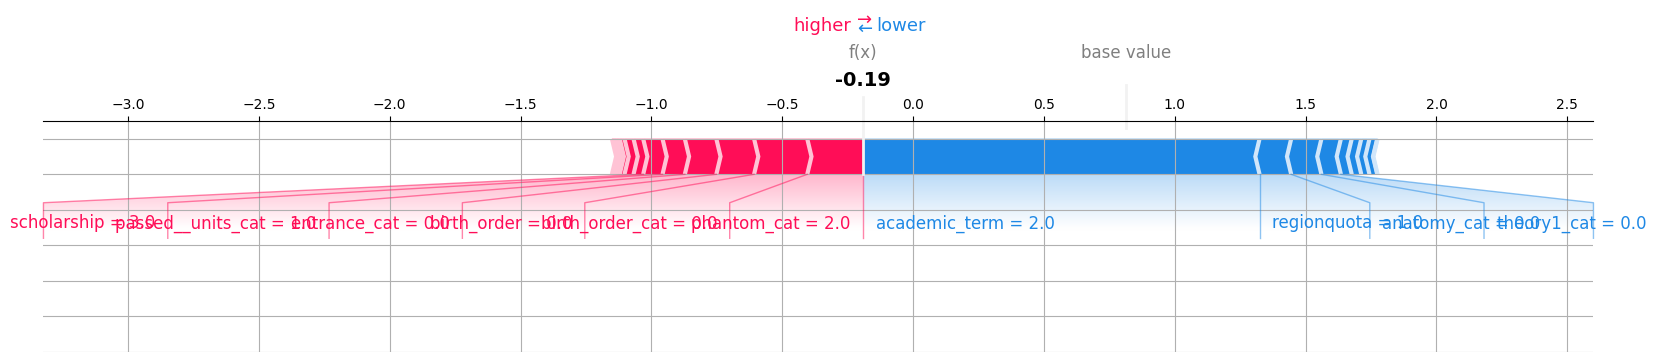

Force plot: Shows how each feature contributed positively or negatively to the individual prediction.

SHAP values for Pass student:


,Feature,SHAP_Value,Feature_Value
1,academic_term,-1.514126,2
16,phantom_cat,0.214287,2
18,birth_order_cat,0.203206,0
2,birth_order,0.144249,0
3,regionquota,-0.120886,1
11,entrance_cat,0.120333,0
15,anatomy_cat,-0.115570,0
20,passed__units_cat,0.085323,1
13,theory1_cat,-0.074443,0
5,scholarship,0.073865,3


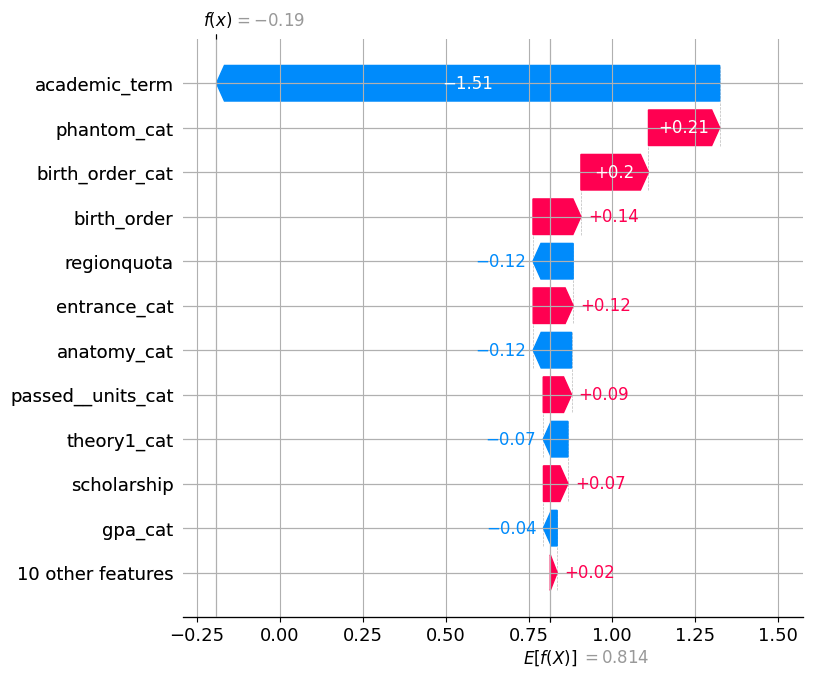

Waterfall plot: Visualizes the cumulative effect of features on this single prediction.


Local explanation for Fail student (index 1)


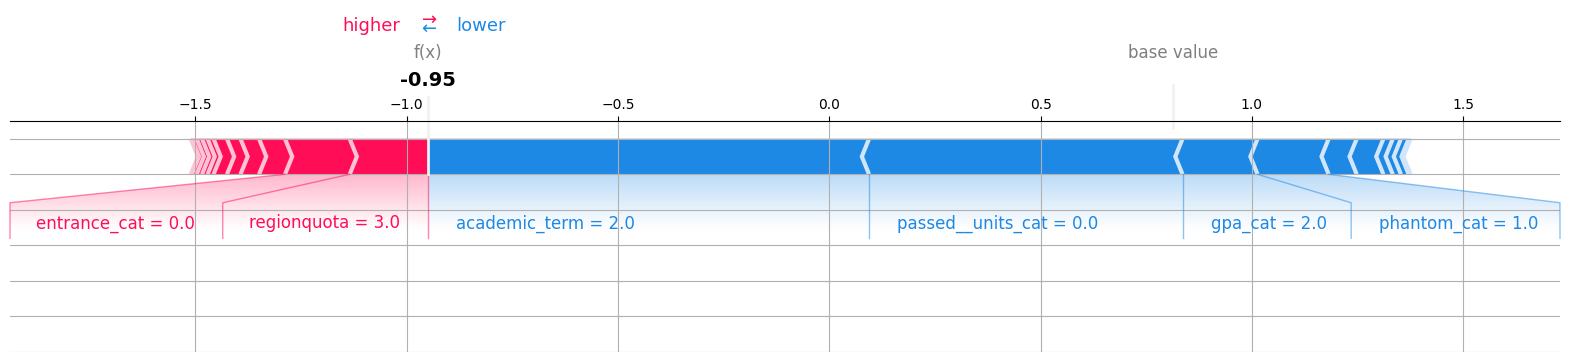

Force plot: Shows how each feature contributed positively or negatively to the individual prediction.

SHAP values for Fail student:


,Feature,SHAP_Value,Feature_Value
1,academic_term,-1.043600,2
20,passed__units_cat,-0.741729,0
3,regionquota,0.185183,3
12,gpa_cat,-0.177532,2
16,phantom_cat,-0.168279,1
11,entrance_cat,0.153080,0
9,practical_avg_cat,-0.066343,1
14,theory2_cat,-0.063127,0
18,birth_order_cat,0.061358,0
5,scholarship,0.043936,2


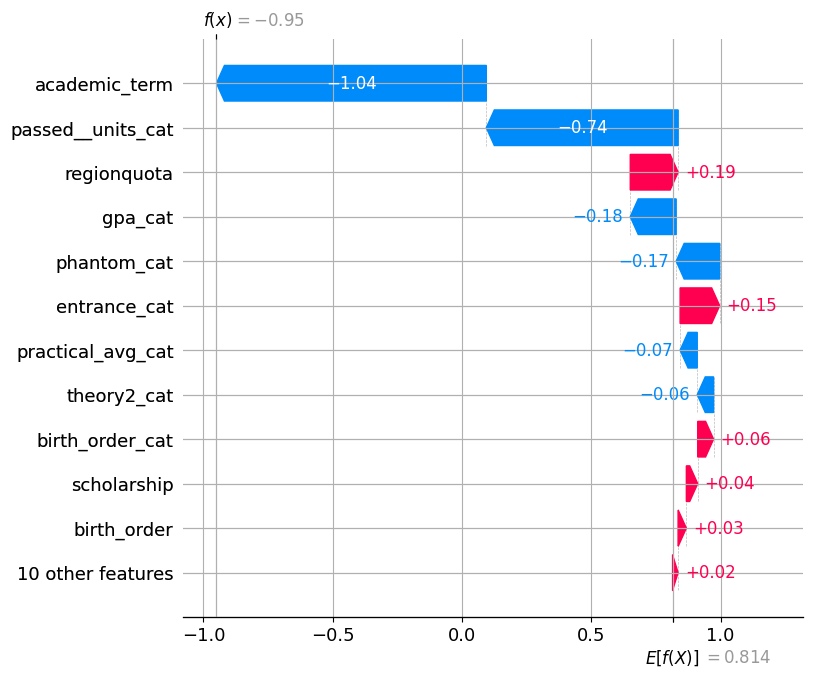

Waterfall plot: Visualizes the cumulative effect of features on this single prediction.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


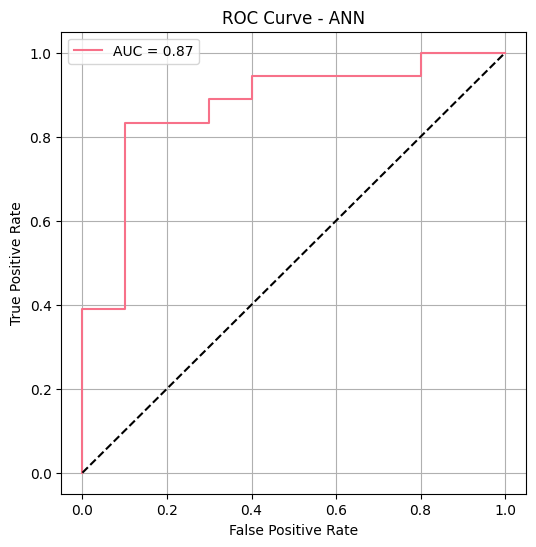

ROC AUC (ANN): 0.8722


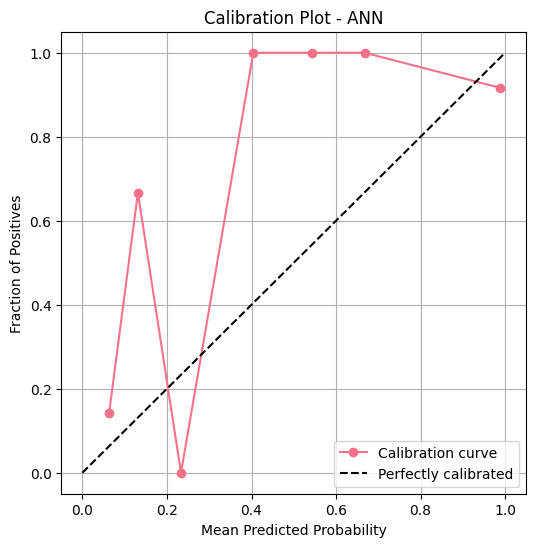

Calibration curve (ANN):
 Bin 1: Predicted=0.063, Actual=0.143
 Bin 2: Predicted=0.131, Actual=0.667
 Bin 3: Predicted=0.233, Actual=0.000
 Bin 4: Predicted=0.404, Actual=1.000
 Bin 5: Predicted=0.544, Actual=1.000
 Bin 6: Predicted=0.667, Actual=1.000
 Bin 7: Predicted=0.987, Actual=0.917


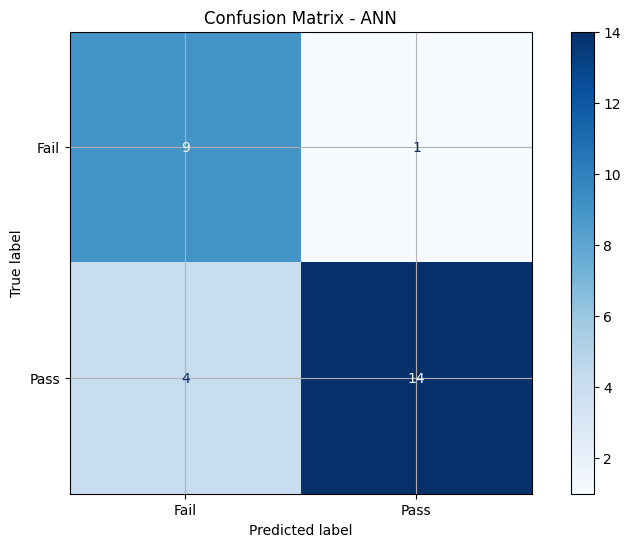

Confusion Matrix (ANN):
[[ 9  1]
 [ 4 14]]
ANN Trained Parameters:
 Layer 0: dense_27
 Layer 1: dropout_18
 Layer 2: dense_28
 Layer 3: dropout_19
 Layer 4: dense_29
 Optimizer: adam
 Learning rate: 0.001

=== Summary of Model Results ===


,Model,Accuracy,F1,Precision,Recall,Specificity,Sensitivity,AUC,MCC
3,CatBoost,0.821429,0.848485,0.933333,0.777778,0.9,0.777778,0.883333,0.651188
4,ANN,0.821429,0.848485,0.933333,0.777778,0.9,0.777778,0.872222,0.651188
1,Random Forest,0.857143,0.882353,0.937500,0.833333,0.9,0.833333,0.863889,0.710047
0,Logistic Regression,0.821429,0.848485,0.933333,0.777778,0.9,0.777778,0.838889,0.651188
2,XGBoost,0.821429,0.857143,0.882353,0.833333,0.8,0.833333,0.838889,0.621366


In [ ]:
# ---------------------------
# Packages
# ---------------------------
!pip install catboost -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    roc_auc_score, accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay, matthews_corrcoef,
    roc_curve, auc
)
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# ---------------------------
# Directories to save results
# ---------------------------
output_dir = '/content/drive/MyDrive/dentistry education/'
os.makedirs(output_dir, exist_ok=True)

# ---------------------------
# Load dataset
# ---------------------------
df = pd.read_csv(path + 'cleaned_dental_data.csv')

# ---------------------------
# Features and target
# ---------------------------
features = [
    'gender', 'academic_term', 'birth_order', 'regionquota', 'quota',
    'scholarship', 'residence_in_tehran', 'exam__season',
    'theory_avg_cat', 'practical_avg_cat', 'age_cat', 'entrance_cat', 'gpa_cat',
    'theory1_cat', 'theory2_cat', 'anatomy_cat', 'phantom_cat',
    'basic_sciences_cat', 'birth_order_cat', 'faile__units_cat',
    'passed__units_cat'
]
target = 'final_status'

# ---------------------------
# Encode categorical features
# ---------------------------
df_encoded = df.copy()
for col in features:
    df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col].astype(str))

le_target = LabelEncoder()
y = le_target.fit_transform(df_encoded[target].astype(str))
X = df_encoded[features].values

# ---------------------------
# Train/test split
# ---------------------------
X_train, X_test, y_train, y_test, train_idx, test_idx = train_test_split(
    X, y, df.index, test_size=0.3, stratify=y, random_state=42
)

# ---------------------------
# Train/test distribution
# ---------------------------
train_dist = pd.Series(y_train).value_counts(normalize=True)
test_dist = pd.Series(y_test).value_counts(normalize=True)
distribution_df = pd.DataFrame({'Train (%)': train_dist, 'Test (%)': test_dist})
distribution_df.to_csv(os.path.join(output_dir, path+'train_test_distribution.csv'))
print("Train/Test Distribution:")
display(distribution_df)

# ---------------------------
# Helper functions
# ---------------------------
def plot_roc_curve(y_true, y_proba, model_name):
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(6,6))
    plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
    plt.plot([0,1], [0,1], 'k--')
    plt.title(f'ROC Curve - {model_name}')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.show()
    print(f"ROC AUC ({model_name}): {roc_auc:.4f}")

def plot_calibration(y_true, y_proba, model_name, n_bins=10):
    prob_true, prob_pred = calibration_curve(y_true, y_proba, n_bins=n_bins)
    plt.figure(figsize=(6,6))
    plt.plot(prob_pred, prob_true, marker='o', label='Calibration curve')
    plt.plot([0,1], [0,1], 'k--', label='Perfectly calibrated')
    plt.title(f'Calibration Plot - {model_name}')
    plt.xlabel('Mean Predicted Probability')
    plt.ylabel('Fraction of Positives')
    plt.legend()
    plt.show()
    print(f"Calibration curve ({model_name}):")
    for i in range(len(prob_true)):
        print(f" Bin {i+1}: Predicted={prob_pred[i]:.3f}, Actual={prob_true[i]:.3f}")

def display_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_target.classes_)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.show()
    print(f"Confusion Matrix ({model_name}):\n{cm}")

def display_model_params(model, model_name):
    print(f"Trained Parameters ({model_name}):")
    if hasattr(model, 'get_params'):
        for k, v in model.get_params().items():
            print(f"  {k}: {v}")
    else:
        print("  (No accessible parameters)")

# ---------------------------
# Models
# ---------------------------
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss', use_label_encoder=False, random_state=42),
    "CatBoost": CatBoostClassifier(verbose=0, random_state=42),
}

# ---------------------------
# Evaluate models
# ---------------------------
results_list = []

for name, model in models.items():
    print(f"\n=== Training {name} ===")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1]

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    auc_score = roc_auc_score(y_test, y_proba)
    mcc = matthews_corrcoef(y_test, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    specificity = tn / (tn + fp)
    sensitivity = recall

    results_list.append({
        "Model": name,
        "Accuracy": acc,
        "F1": f1,
        "Precision": precision,
        "Recall": recall,
        "Specificity": specificity,
        "Sensitivity": sensitivity,
        "AUC": auc_score,
        "MCC": mcc
    })

    # ---- Plots ----
    plot_roc_curve(y_test, y_proba, name)
    plot_calibration(y_test, y_proba, name)
    display_confusion_matrix(y_test, y_pred, name)
    display_model_params(model, name)


# ---------------------------
# SHAP Analysis for CatBoost
# ---------------------------
import shap

# Extract trained CatBoost model
cat_model = models["CatBoost"]
X_test_df = pd.DataFrame(X_test, columns=features)

# Initialize SHAP explainer for CatBoost
explainer = shap.TreeExplainer(cat_model)
shap_values = explainer.shap_values(X_test_df)

# ---------------------------
# Global Feature Importance
# ---------------------------
# Bar plot
shap.summary_plot(shap_values, X_test_df, plot_type="bar", feature_names=features, show=True)
# Beeswarm plot
shap.summary_plot(shap_values, X_test_df, feature_names=features, show=True)

# ---------------------------
# Local Explanation for Individual Prediction
# ---------------------------

# Find one Pass and one Fail student in test set
pass_idx = next(i for i, val in enumerate(y_test) if val == 1)
fail_idx = next(i for i, val in enumerate(y_test) if val == 0)

# Pass student
print(f"Explaining prediction for Pass student (index {pass_idx})")
shap.initjs()
shap.force_plot(
    explainer.expected_value,
    shap_values[pass_idx],
    X_test_df.iloc[pass_idx],
    feature_names=features,
    matplotlib=True
)
shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value, shap_values[pass_idx], feature_names=features, max_display=12
)

# Fail student
print(f"Explaining prediction for Fail student (index {fail_idx})")
shap.force_plot(
    explainer.expected_value,
    shap_values[fail_idx],
    X_test_df.iloc[fail_idx],
    feature_names=features,
    matplotlib=True
)
shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value, shap_values[fail_idx], feature_names=features, max_display=12
)

# ---- SHAP analysis for CatBoost only ----
if name == "CatBoost":
    print("\n--- SHAP Analysis for CatBoost ---")
    X_test_df = pd.DataFrame(X_test, columns=features)
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test_df)

    # ---------------------------
    # Global feature importance
    # ---------------------------
    shap.summary_plot(shap_values, X_test_df, plot_type="bar", feature_names=features, show=True)
    print("SHAP Summary (bar plot): Shows the average magnitude of feature contributions to the model output.\n")

    shap.summary_plot(shap_values, X_test_df, feature_names=features, show=True)
    print("SHAP Summary (beeswarm plot): Displays both magnitude and direction of feature impact on predictions.\n")

    # Print SHAP values for global view (mean absolute SHAP values per feature)
    mean_shap_values = np.abs(shap_values).mean(axis=0)
    shap_df = pd.DataFrame({'Feature': features, 'Mean_ABS_SHAP_Value': mean_shap_values})
    shap_df = shap_df.sort_values(by='Mean_ABS_SHAP_Value', ascending=False)
    print("Global SHAP values (mean absolute per feature):")
    display(shap_df)

    # ---------------------------
    # Local explanations for one Pass and one Fail
    # ---------------------------
    pass_idx = next(i for i, val in enumerate(y_test) if val == 1)
    fail_idx = next(i for i, val in enumerate(y_test) if val == 0)

    # Pass student
    print(f"\nLocal explanation for Pass student (index {pass_idx})")
    shap.initjs()
    shap.force_plot(explainer.expected_value, shap_values[pass_idx], X_test_df.iloc[pass_idx],
                    feature_names=features, matplotlib=True)
    print("Force plot: Shows how each feature contributed positively or negatively to the individual prediction.\n")

    # Print SHAP values for this student
    pass_shap_df = pd.DataFrame({'Feature': features, 'SHAP_Value': shap_values[pass_idx], 'Feature_Value': X_test_df.iloc[pass_idx].values})
    pass_shap_df = pass_shap_df.sort_values(by='SHAP_Value', key=abs, ascending=False)
    print("SHAP values for Pass student:")
    display(pass_shap_df)

    shap.plots._waterfall.waterfall_legacy(explainer.expected_value, shap_values[pass_idx],
                                          feature_names=features, max_display=12)
    print("Waterfall plot: Visualizes the cumulative effect of features on this single prediction.\n")

    # Fail student
    print(f"\nLocal explanation for Fail student (index {fail_idx})")
    shap.force_plot(explainer.expected_value, shap_values[fail_idx], X_test_df.iloc[fail_idx],
                    feature_names=features, matplotlib=True)
    print("Force plot: Shows how each feature contributed positively or negatively to the individual prediction.\n")

    # Print SHAP values for this student
    fail_shap_df = pd.DataFrame({'Feature': features, 'SHAP_Value': shap_values[fail_idx], 'Feature_Value': X_test_df.iloc[fail_idx].values})
    fail_shap_df = fail_shap_df.sort_values(by='SHAP_Value', key=abs, ascending=False)
    print("SHAP values for Fail student:")
    display(fail_shap_df)

    shap.plots._waterfall.waterfall_legacy(explainer.expected_value, shap_values[fail_idx],
                                          feature_names=features, max_display=12)
    print("Waterfall plot: Visualizes the cumulative effect of features on this single prediction.\n")

# ANN
# ---------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

ann = Sequential([
    Dense(64, input_dim=X_train_scaled.shape[1], activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.1),
    Dense(1, activation='sigmoid')
])
ann.compile(optimizer=Adam(0.001), loss='binary_crossentropy', metrics=['accuracy'])
ann.fit(X_train_scaled, y_train, epochs=50, batch_size=8, verbose=0)

y_pred_ann = (ann.predict(X_test_scaled) > 0.5).astype(int).flatten()
y_proba_ann = ann.predict(X_test_scaled).flatten()

acc = accuracy_score(y_test, y_pred_ann)
f1 = f1_score(y_test, y_pred_ann)
precision = precision_score(y_test, y_pred_ann)
recall = recall_score(y_test, y_pred_ann)
auc_score = roc_auc_score(y_test, y_proba_ann)
mcc = matthews_corrcoef(y_test, y_pred_ann)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_ann).ravel()
specificity = tn / (tn + fp)
sensitivity = recall

results_list.append({
    "Model": "ANN",
    "Accuracy": acc,
    "F1": f1,
    "Precision": precision,
    "Recall": recall,
    "Specificity": specificity,
    "Sensitivity": sensitivity,
    "AUC": auc_score,
    "MCC": mcc
})

plot_roc_curve(y_test, y_proba_ann, "ANN")
plot_calibration(y_test, y_proba_ann, "ANN")
display_confusion_matrix(y_test, y_pred_ann, "ANN")

# ---- ANN parameters ----
print("ANN Trained Parameters:")
for i, layer in enumerate(ann.layers):
    print(f" Layer {i}: {layer.name}")
print(" Optimizer:", ann.optimizer.get_config()["name"])
print(" Learning rate:", ann.optimizer.learning_rate.numpy())

# ---------------------------
# Save results table
# ---------------------------
results_df = pd.DataFrame(results_list)
results_df.to_csv(os.path.join(output_dir, 'model_results.csv'), index=False)
print("\n=== Summary of Model Results ===")
display(results_df.sort_values(by='AUC', ascending=False))


Train/Test Distribution after SMOTE:


,Train (SMOTE %),Test (%)
0,0.2,0.178571
1,0.2,0.250000
2,0.2,0.214286
3,0.2,0.214286
4,0.2,0.142857



🔹 MODEL: Logistic Regression


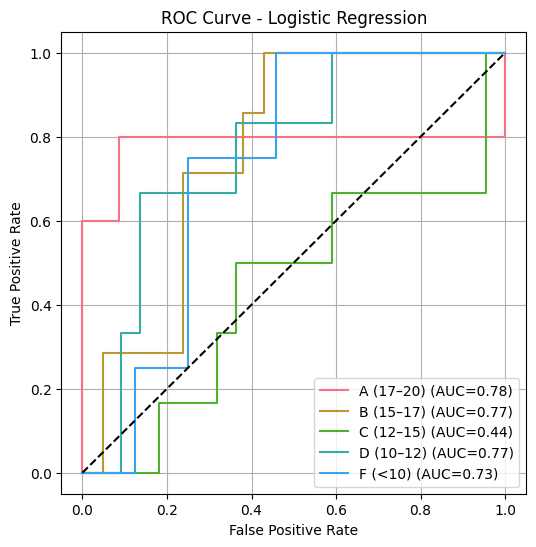

🔹 AUC (macro): 0.697


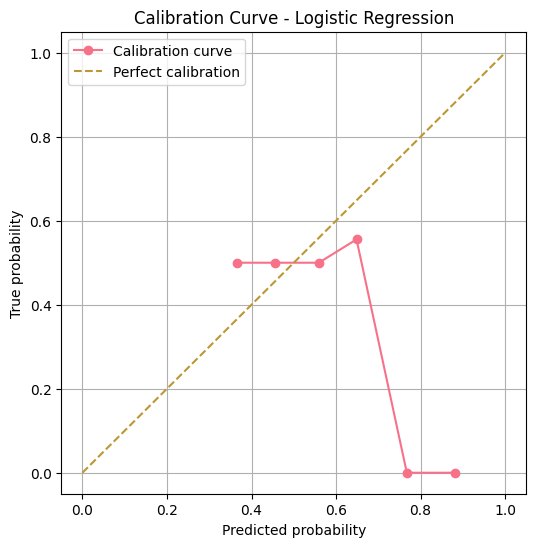

🔹 Mean calibration error: 0.330


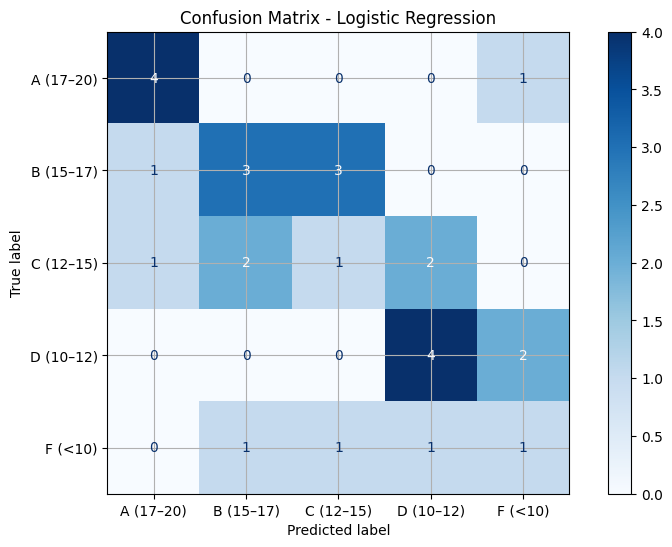

🔹 Confusion Matrix:
[[4 0 0 0 1]
 [1 3 3 0 0]
 [1 2 1 2 0]
 [0 0 0 4 2]
 [0 1 1 1 1]]
🔹 Sensitivity per class: [0.8   0.429 0.167 0.667 0.25 ]
🔹 Specificity per class: [0.913 0.857 0.818 0.864 0.875]

🔧 Model Parameters:
C                      1.0
class_weight          None
dual                 False
fit_intercept         True
intercept_scaling        1
l1_ratio              None
max_iter              1000
multi_class            ovr
n_jobs                None
penalty                 l2
dtype: object

🔹 MODEL: Random Forest


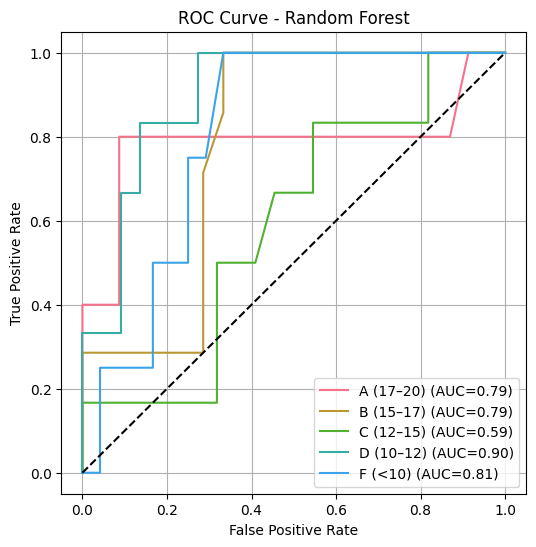

🔹 AUC (macro): 0.775


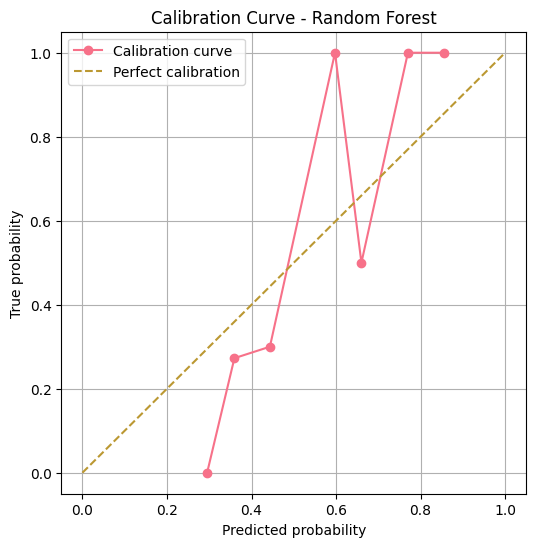

🔹 Mean calibration error: 0.209


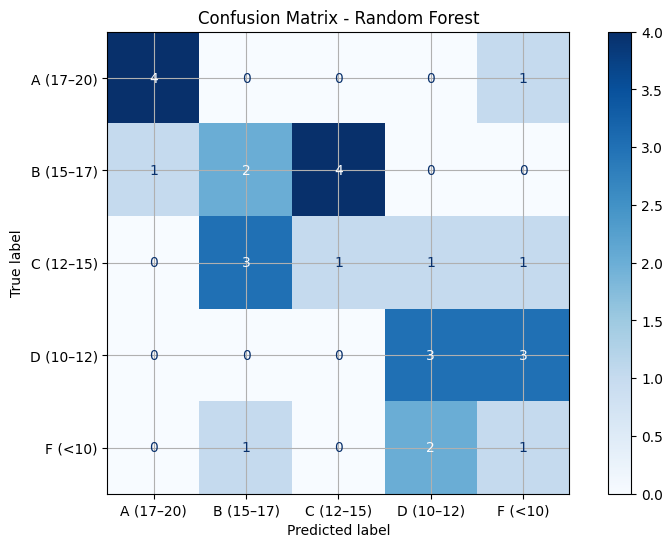

🔹 Confusion Matrix:
[[4 0 0 0 1]
 [1 2 4 0 0]
 [0 3 1 1 1]
 [0 0 0 3 3]
 [0 1 0 2 1]]
🔹 Sensitivity per class: [0.8   0.286 0.167 0.5   0.25 ]
🔹 Specificity per class: [0.957 0.81  0.818 0.864 0.792]

🔧 Model Parameters:
bootstrap                True
ccp_alpha                 0.0
class_weight             None
criterion                gini
max_depth                None
max_features             sqrt
max_leaf_nodes           None
max_samples              None
min_impurity_decrease     0.0
min_samples_leaf            1
dtype: object

🔹 MODEL: XGBoost


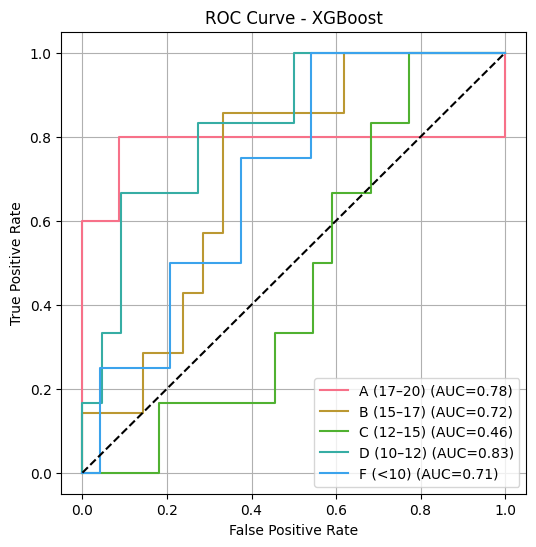

🔹 AUC (macro): 0.701


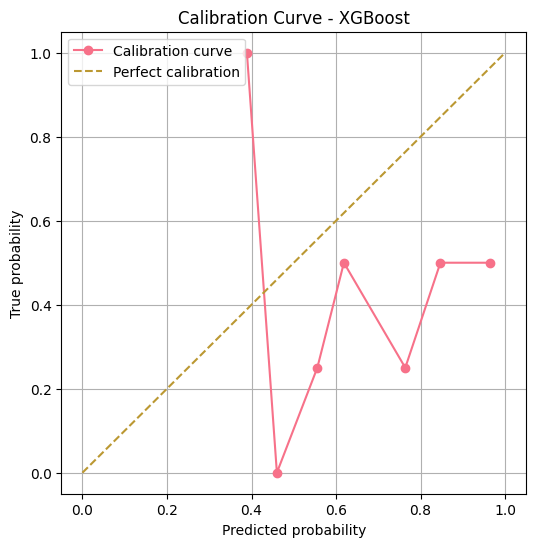

🔹 Mean calibration error: 0.403


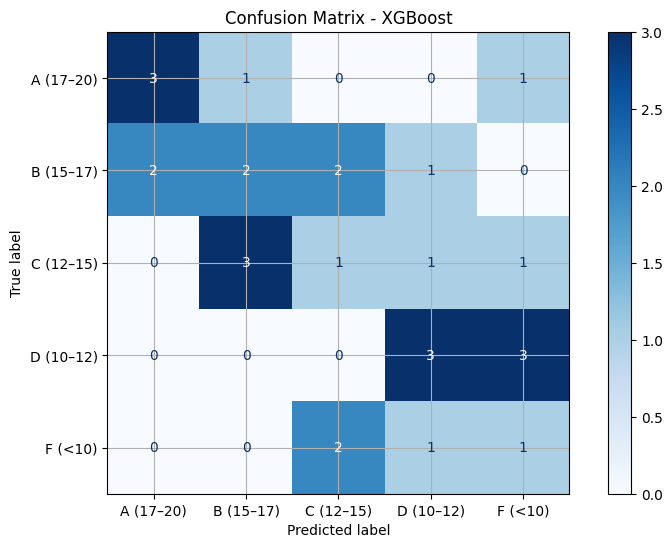

🔹 Confusion Matrix:
[[3 1 0 0 1]
 [2 2 2 1 0]
 [0 3 1 1 1]
 [0 0 0 3 3]
 [0 0 2 1 1]]
🔹 Sensitivity per class: [0.6   0.286 0.167 0.5   0.25 ]
🔹 Specificity per class: [0.913 0.81  0.818 0.864 0.792]

🔧 Model Parameters:
objective                multi:softprob
base_score                         None
booster                            None
callbacks                          None
colsample_bylevel                  None
colsample_bynode                   None
colsample_bytree                   None
device                             None
early_stopping_rounds              None
enable_categorical                False
dtype: object

🔹 MODEL: ANN (Neural Network)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


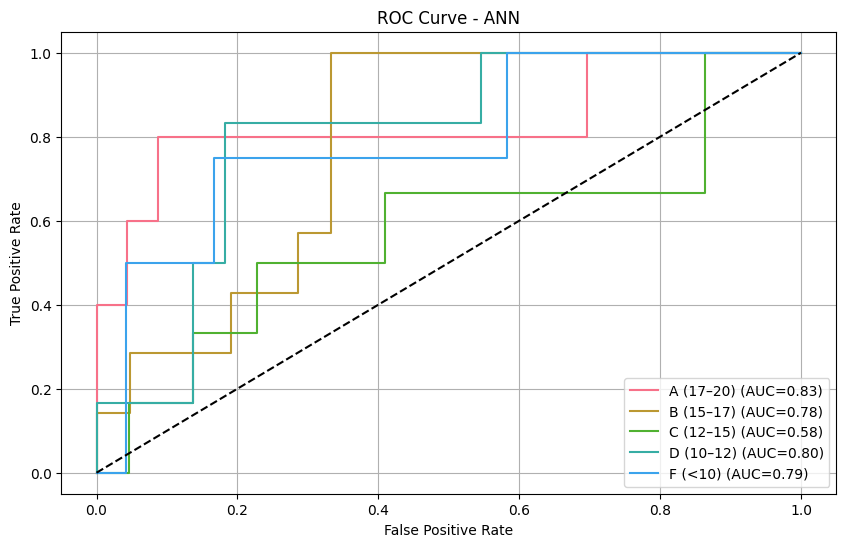

🔹 AUC (macro): 0.758


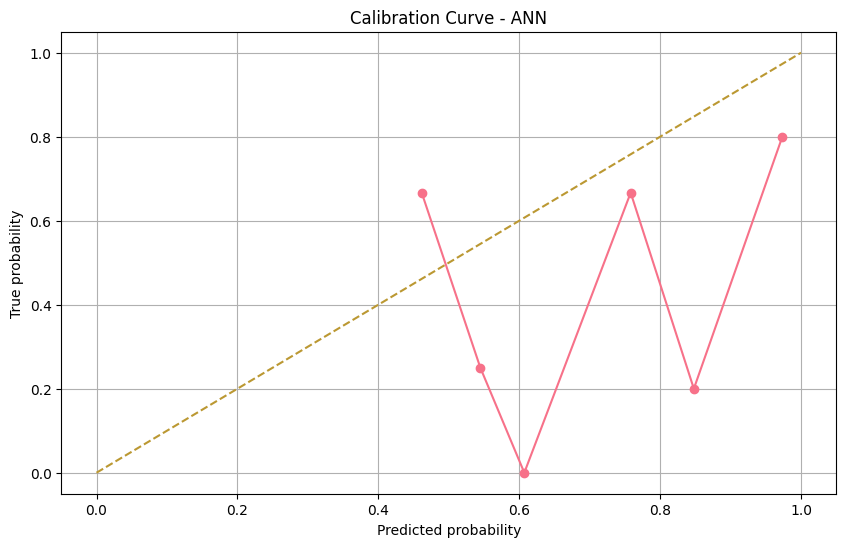

🔹 Mean calibration error: 0.337


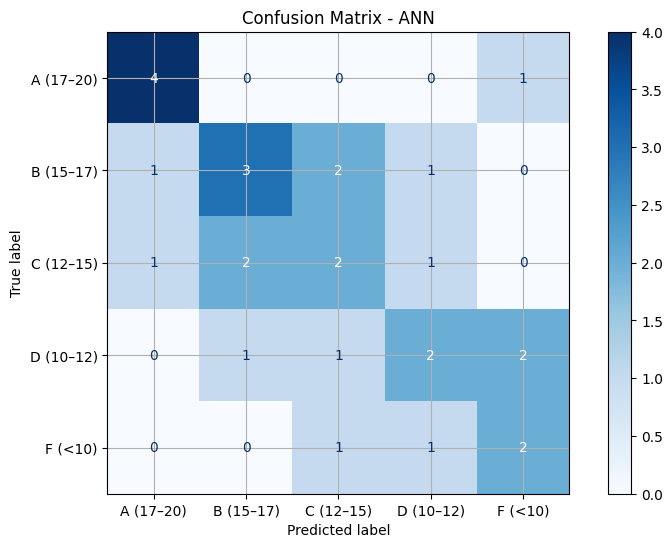

🔹 Confusion Matrix:
[[4 0 0 0 1]
 [1 3 2 1 0]
 [1 2 2 1 0]
 [0 1 1 2 2]
 [0 0 1 1 2]]
🔹 Sensitivity per class: [0.8   0.429 0.333 0.333 0.5  ]
🔹 Specificity per class: [0.913 0.857 0.818 0.864 0.875]

🔧 ANN Model Summary:


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 64)             │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,961 (42.82 KB)

 Trainable params: 3,653 (14.27 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 7,308 (28.55 KB)



==================== Final Model Performance ====================


,Model,Accuracy,F1,Precision,Recall,Specificity,Sensitivity,AUC,MCC
1,Random Forest,0.3929,0.3945,0.4000,0.3929,0.8479,0.4005,0.7752,0.2420
3,ANN,0.4643,0.4581,0.4583,0.4643,0.8654,0.4790,0.7575,0.3301
2,XGBoost,0.3571,0.3587,0.3643,0.3571,0.8392,0.3605,0.7015,0.1971
0,Logistic Regression,0.4643,0.4518,0.4451,0.4643,0.8654,0.4624,0.6970,0.3280


In [ ]:
# ============================================
# Full Enhanced Code — grade_category prediction
# ============================================

!pip install catboost -q
!pip install imbalanced-learn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay, matthews_corrcoef,
    roc_auc_score, roc_curve, auc
)
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from imblearn.over_sampling import SMOTE

# ---------------------------
# Directories
# ---------------------------
output_dir = '/content/drive/MyDrive/dentistry_education_results_grade_category/'
os.makedirs(output_dir, exist_ok=True)

# ---------------------------
# Load dataset
# ---------------------------
path = '/content/drive/MyDrive/dentistry education/'
df = pd.read_csv(path + 'cleaned_dental_data.csv')

features = [
    'gender', 'academic_term', 'birth_order', 'regionquota', 'quota',
    'scholarship', 'residence_in_tehran', 'exam__season',
    'theory_avg_cat', 'practical_avg_cat', 'age_cat', 'entrance_cat', 'gpa_cat',
    'theory1_cat', 'theory2_cat', 'anatomy_cat', 'phantom_cat',
    'basic_sciences_cat', 'birth_order_cat', 'faile__units_cat',
    'passed__units_cat'
]
target = 'grade_category'

# ---------------------------
# Encode features and target
# ---------------------------
df_encoded = df.copy()
for col in features:
    df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col].astype(str))

le_target = LabelEncoder()
y = le_target.fit_transform(df_encoded[target])
X = df_encoded[features].values

# ---------------------------
# Split + SMOTE
# ---------------------------
X_train, X_test, y_train, y_test, train_idx, test_idx = train_test_split(
    X, y, df.index, test_size=0.3, stratify=y, random_state=42
)
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

# ---------------------------
# Train/Test Distribution
# ---------------------------
train_dist = pd.Series(y_train_res).value_counts(normalize=True)
test_dist = pd.Series(y_test).value_counts(normalize=True)
dist_df = pd.DataFrame({'Train (SMOTE %)': train_dist, 'Test (%)': test_dist})
print("Train/Test Distribution after SMOTE:")
display(dist_df)

# ---------------------------
# Models
# ---------------------------
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, multi_class='ovr'),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "XGBoost": XGBClassifier(eval_metric='mlogloss', use_label_encoder=False, random_state=42)
}

results_list = []

def evaluate_and_plot_model(model, name, X_train, y_train, X_test, y_test):
    print(f"\n{'='*70}\n🔹 MODEL: {name}\n{'='*70}")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    mcc = matthews_corrcoef(y_test, y_pred)
    auc_macro = roc_auc_score(y_test, y_proba, multi_class='ovr')

    cm = confusion_matrix(y_test, y_pred)
    sens = np.diag(cm) / np.sum(cm, axis=1)
    spec = []
    for i in range(len(cm)):
        tn = cm[np.arange(len(cm)) != i][:, np.arange(len(cm)) != i].sum()
        fp = cm[np.arange(len(cm)) != i][:, i].sum()
        spec.append(tn / (tn + fp))

    # --- ROC Plot ---
    plt.figure(figsize=(6,6))
    for i in range(y_proba.shape[1]):
        fpr, tpr, _ = roc_curve((y_test==i).astype(int), y_proba[:, i])
        plt.plot(fpr, tpr, label=f'{le_target.classes_[i]} (AUC={auc(fpr, tpr):.2f})')
    plt.plot([0,1],[0,1],'k--')
    plt.title(f'ROC Curve - {name}')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.show()
    print(f"🔹 AUC (macro): {auc_macro:.3f}")

    # --- Calibration Plot ---
    plt.figure(figsize=(6,6))
    prob_true, prob_pred = calibration_curve((y_test==y_pred).astype(int), np.max(y_proba, axis=1), n_bins=10)
    plt.plot(prob_pred, prob_true, marker='o', label='Calibration curve')
    plt.plot([0,1],[0,1],'--', label='Perfect calibration')
    plt.title(f'Calibration Curve - {name}')
    plt.xlabel('Predicted probability')
    plt.ylabel('True probability')
    plt.legend()
    plt.show()
    print(f"🔹 Mean calibration error: {np.mean(np.abs(prob_true - prob_pred)):.3f}")

    # --- Confusion Matrix ---
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_target.classes_)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f'Confusion Matrix - {name}')
    plt.show()
    print(f"🔹 Confusion Matrix:\n{cm}")
    print(f"🔹 Sensitivity per class: {np.round(sens,3)}")
    print(f"🔹 Specificity per class: {np.round(spec,3)}")

    # --- Parameters ---
    if hasattr(model, "get_params"):
        print("\n🔧 Model Parameters:")
        print(pd.Series(model.get_params()).head(10))  # show top 10 for readability

    results_list.append({
        "Model": name,
        "Accuracy": acc,
        "F1": f1,
        "Precision": prec,
        "Recall": rec,
        "Specificity": np.mean(spec),
        "Sensitivity": np.mean(sens),
        "AUC": auc_macro,
        "MCC": mcc
    })


# Evaluate all classic models
for name, model in models.items():
    evaluate_and_plot_model(model, name, X_train_res, y_train_res, X_test, y_test)


# ---------------------------
# ANN
# ---------------------------
print(f"\n{'='*70}\n🔹 MODEL: ANN (Neural Network)\n{'='*70}")

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train_res)
X_test_s = scaler.transform(X_test)

num_classes = len(le_target.classes_)
ann = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_s.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')
])
ann.compile(optimizer=Adam(0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
ann.fit(X_train_s, y_train_res, epochs=60, batch_size=8, verbose=0)

y_pred_ann = np.argmax(ann.predict(X_test_s), axis=1)
y_proba_ann = ann.predict(X_test_s)

acc = accuracy_score(y_test, y_pred_ann)
f1 = f1_score(y_test, y_pred_ann, average='weighted')
prec = precision_score(y_test, y_pred_ann, average='weighted')
rec = recall_score(y_test, y_pred_ann, average='weighted')
mcc = matthews_corrcoef(y_test, y_pred_ann)
auc_macro = roc_auc_score(y_test, y_proba_ann, multi_class='ovr')
cm = confusion_matrix(y_test, y_pred_ann)
sens = np.diag(cm) / np.sum(cm, axis=1)
spec = []
for i in range(len(cm)):
    tn = cm[np.arange(len(cm)) != i][:, np.arange(len(cm)) != i].sum()
    fp = cm[np.arange(len(cm)) != i][:, i].sum()
    spec.append(tn / (tn + fp))

# --- ANN Plots ---
for i in range(num_classes):
    fpr, tpr, _ = roc_curve((y_test==i).astype(int), y_proba_ann[:, i])
    plt.plot(fpr, tpr, label=f'{le_target.classes_[i]} (AUC={auc(fpr, tpr):.2f})')
plt.plot([0,1],[0,1],'k--')
plt.title('ROC Curve - ANN')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()
print(f"🔹 AUC (macro): {auc_macro:.3f}")

# Calibration
prob_true, prob_pred = calibration_curve((y_test==y_pred_ann).astype(int), np.max(y_proba_ann, axis=1), n_bins=10)
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1],[0,1],'--')
plt.title('Calibration Curve - ANN')
plt.xlabel('Predicted probability')
plt.ylabel('True probability')
plt.show()
print(f"🔹 Mean calibration error: {np.mean(np.abs(prob_true - prob_pred)):.3f}")

# Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_target.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix - ANN')
plt.show()
print(f"🔹 Confusion Matrix:\n{cm}")
print(f"🔹 Sensitivity per class: {np.round(sens,3)}")
print(f"🔹 Specificity per class: {np.round(spec,3)}")

print("\n🔧 ANN Model Summary:")
ann.summary()

results_list.append({
    "Model": "ANN",
    "Accuracy": acc,
    "F1": f1,
    "Precision": prec,
    "Recall": rec,
    "Specificity": np.mean(spec),
    "Sensitivity": np.mean(sens),
    "AUC": auc_macro,
    "MCC": mcc
})

# ---------------------------
# Final Results Table
# ---------------------------
results_df = pd.DataFrame(results_list)
results_df = results_df.round(4)
print("\n\n==================== Final Model Performance ====================")
display(results_df.sort_values(by="AUC", ascending=False))
results_df.to_csv(os.path.join(output_dir, 'final_model_metrics_with_calibration.csv'), index=False)


In [ ]:
# ---------------------------
# Packages
# ---------------------------
!pip install catboost -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    roc_auc_score, accuracy_score, f1_score, precision_score, recall_score,
    roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# ---------------------------
# Load dataset
# ---------------------------
path = '/content/drive/MyDrive/dentistry education/'
df = pd.read_csv(path + 'cleaned_dental_data.csv')

# ---------------------------
# Features and target
# ---------------------------
features = [
    'gender', 'academic_term', 'birth_order', 'regionquota', 'quota',
    'scholarship', 'residence_in_tehran', 'exam__season',
    'theory_avg_cat', 'practical_avg_cat', 'age_cat', 'entrance_cat', 'gpa_cat',
    'theory1_cat', 'theory2_cat', 'anatomy_cat', 'phantom_cat',
    'basic_sciences_cat', 'birth_order_cat', 'faile__units_cat',
    'passed__units_cat'
]
target = 'final_status'

# ---------------------------
# Encode categorical features
# ---------------------------
df_encoded = df.copy()
le_dict = {}
for col in features:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    le_dict[col] = le

# Encode target
le_target = LabelEncoder()
y = le_target.fit_transform(df_encoded[target].astype(str))  # 1D

X = df_encoded[features].values  # All numeric now

# ---------------------------
# Helper functions
# ---------------------------
def plot_roc(y_true, y_proba, model_name, le):
    n_classes = y_proba.shape[1]
    plt.figure(figsize=(6,6))
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve((y_true==i).astype(int), y_proba[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{le.classes_[i]} (AUC = {roc_auc:.2f})')
    plt.plot([0,1],[0,1],'k--')
    plt.title(f'ROC Curve - {model_name}')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.show()

def plot_confusion(y_true, y_pred, model_name, le):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.show()

def evaluate_models(X, y, le):
    results = []
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, stratify=y, random_state=42
    )

    # Scaling for ANN
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    models = {
        "Logistic Regression": LogisticRegression(max_iter=1000),
        "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
        "XGBoost": XGBClassifier(eval_metric='logloss', use_label_encoder=False, random_state=42),
        "CatBoost": CatBoostClassifier(verbose=0, random_state=42),
    }

    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)

        auc_score = roc_auc_score(y_test, y_proba, multi_class='ovr')
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='weighted')
        precision = precision_score(y_test, y_pred, average='weighted')
        recall = recall_score(y_test, y_pred, average='weighted')

        results.append({
            "Model": name,
            "AUC": auc_score,
            "Accuracy": acc,
            "F1": f1,
            "Precision": precision,
            "Recall": recall
        })

        print(f"\n{name} Metrics:")
        print(f"  AUC: {auc_score:.3f}")
        print(f"  Accuracy: {acc:.3f}")
        print(f"  F1 Score: {f1:.3f}")
        print(f"  Precision: {precision:.3f}")
        print(f"  Recall: {recall:.3f}")

        plot_roc(y_test, y_proba, name, le)
        plot_confusion(y_test, y_pred, name, le)

    # ---------------------------
    # ANN model
    # ---------------------------
    num_classes = len(np.unique(y))
    ann = Sequential([
        Dense(64, input_dim=X_train_scaled.shape[1], activation='relu'),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dropout(0.1),
        Dense(num_classes, activation='softmax')
    ])
    ann.compile(optimizer=Adam(0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    ann.fit(X_train_scaled, y_train, epochs=50, batch_size=8, verbose=0)

    y_pred_ann = np.argmax(ann.predict(X_test_scaled), axis=1)
    y_proba_ann = ann.predict(X_test_scaled)

    auc_score = roc_auc_score(y_test, y_proba_ann, multi_class='ovr')
    acc = accuracy_score(y_test, y_pred_ann)
    f1 = f1_score(y_test, y_pred_ann, average='weighted')
    precision = precision_score(y_test, y_pred_ann, average='weighted')
    recall = recall_score(y_test, y_pred_ann, average='weighted')

    results.append({
        "Model": "ANN",
        "AUC": auc_score,
        "Accuracy": acc,
        "F1": f1,
        "Precision": precision,
        "Recall": recall
    })

    print("\nANN Metrics:")
    print(f"  AUC: {auc_score:.3f}")
    print(f"  Accuracy: {acc:.3f}")
    print(f"  F1 Score: {f1:.3f}")
    print(f"  Precision: {precision:.3f}")
    print(f"  Recall: {recall:.3f}")

    plot_roc(y_test, y_proba_ann, "ANN", le)
    plot_confusion(y_test, y_pred_ann, "ANN", le)

    return pd.DataFrame(results)

# ---------------------------
# Run prediction for 'final_status'
# ---------------------------
print("\n" + "="*50)
print(f"🎯 Predicting target: {target}")
print("="*50)

results_df = evaluate_models(X, y, le_target)
print("\nSummary for target:", target)
print(results_df.sort_values(by='AUC', ascending=False))



🎯 Predicting target: final_status


ValueError: y should be a 1d array, got an array of shape (28, 2) instead.

In [ ]:
!pip install catboost
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, precision_score, recall_score, roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
from sklearn.calibration import calibration_curve

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# ---------------------------
# 1. Load pre-processed data
# ---------------------------

analyzer = DentalDataAnalyzer(path+'dandan 1404-7-9.csv')
df_cleaned = analyzer.load_and_clean_data()

# ---------------------------
# 2. Define target & features
# ---------------------------
target_col = 'final_status'  # Q1-Q4
features = [    'gender', 'academic_term', 'birth_order', 'regionquota', 'quota',
    'scholarship', 'residence_in_tehran', 'exam__season',
    'theory_avg_cat', 'practical_avg_cat', 'age_cat', 'entrance_cat',
    'gpa_cat', 'theory1_cat', 'theory2_cat', 'anatomy_cat', 'phantom_cat',
    'basic_sciences_cat', 'birth_order_cat', 'faile__units_cat', 'passed__units_cat']

df_model = df_cleaned[features + [target_col]].dropna()

# Encode target labels (Q1-Q4 -> 0-3)
le = LabelEncoder()
df_model[target_col] = le.fit_transform(df_model[target_col])

X = df_model[features].values
y = df_model[target_col].values
num_classes = len(np.unique(y))

# ---------------------------
# 3. Train/Test Split
# ---------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ---------------------------
# 4. Define models
# ---------------------------
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "XGBoost": XGBClassifier(eval_metric='mlogloss', use_label_encoder=False, random_state=42),
    "CatBoost": CatBoostClassifier(verbose=0, random_state=42),
}

# ---------------------------
# Helper functions
# ---------------------------
def plot_calibration(y_true, y_proba, model_name):
    n_classes = y_proba.shape[1]
    plt.figure(figsize=(6,6))
    for i in range(n_classes):
        prob_true, prob_pred = calibration_curve((y_true==i).astype(int), y_proba[:, i], n_bins=10)
        plt.plot(prob_pred, prob_true, marker='o', label=f'Q{i+1}')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.title(f'Calibration Plot - {model_name}')
    plt.xlabel('Predicted probability')
    plt.ylabel('Fraction of positives')
    plt.legend()
    plt.show()

def plot_roc(y_true, y_proba, model_name):
    n_classes = y_proba.shape[1]
    plt.figure(figsize=(6,6))
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve((y_true==i).astype(int), y_proba[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'Q{i+1} (AUC = {roc_auc:.2f})')
    plt.plot([0,1],[0,1],'k--')
    plt.title(f'ROC Curve - {model_name}')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.show()

def plot_confusion(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.show()

# ---------------------------
# 5. Train/Evaluate models
# ---------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

for name, model in models.items():
    y_proba_cv = cross_val_predict(model, X_train, y_train, cv=cv, method='predict_proba')
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)

    auc_score = roc_auc_score(y_test, y_proba, multi_class='ovr')
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')

    results.append({
        "Model": name,
        "AUC": auc_score,
        "Accuracy": acc,
        "F1": f1,
        "Precision": precision,
        "Recall": recall
    })

    print(f"\n{name} Metrics:")
    print(f"  AUC: {auc_score:.3f}")
    print(f"  Accuracy: {acc:.3f}")
    print(f"  F1 Score: {f1:.3f}")
    print(f"  Precision: {precision:.3f}")
    print(f"  Recall: {recall:.3f}")

    # Plots
    plot_calibration(y_test, y_proba, name)
    plot_roc(y_test, y_proba, name)
    plot_confusion(y_test, y_pred, name)

# ---------------------------
# 6. ANN model
# ---------------------------
ann = Sequential([
    Dense(64, input_dim=X_train.shape[1], activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.1),
    Dense(num_classes, activation='softmax')
])
ann.compile(optimizer=Adam(0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
ann.fit(X_train, y_train, epochs=50, batch_size=8, verbose=0)

y_pred_ann = np.argmax(ann.predict(X_test), axis=1)
y_proba_ann = ann.predict(X_test)

auc_score = roc_auc_score(y_test, y_proba_ann, multi_class='ovr')
acc = accuracy_score(y_test, y_pred_ann)
f1 = f1_score(y_test, y_pred_ann, average='weighted')
precision = precision_score(y_test, y_pred_ann, average='weighted')
recall = recall_score(y_test, y_pred_ann, average='weighted')

results.append({
    "Model": "ANN",
    "AUC": auc_score,
    "Accuracy": acc,
    "F1": f1,
    "Precision": precision,
    "Recall": recall
})

print("\nANN Metrics:")
print(f"  AUC: {auc_score:.3f}")
print(f"  Accuracy: {acc:.3f}")
print(f"  F1 Score: {f1:.3f}")
print(f"  Precision: {precision:.3f}")
print(f"  Recall: {recall:.3f}")

plot_calibration(y_test, y_proba_ann, "ANN")
plot_roc(y_test, y_proba_ann, "ANN")
plot_confusion(y_test, y_pred_ann, "ANN")

# ---------------------------
# 7. Summary table
# ---------------------------
df_results = pd.DataFrame(results)
print("\nSummary of all models:")
print(df_results.sort_values(by="AUC", ascending=False))


statistical analysis

In [ ]:
# -*- coding: utf-8 -*-
"""
DentalDataAnalyzer
------------------
Integrated data analysis pipeline for dental student performance datasets.

Features:
- Load & clean (column normalization, type conversion, derived features)
- EDA with plots + automatic numeric summaries & plain-language interpretations
- Statistical relationships: Pearson, Spearman, ANOVA, Kruskal-Wallis
- Effect size calculation (r, eta-squared)
- Random Forest feature importance + classification report
- Characteristics table with categorical breakdowns and chi-square / Fisher logic
- Export of characteristics table to CSV
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import re
from itertools import combinations

# stats
import scipy.stats as stats
from scipy.stats import f_oneway, pearsonr, spearmanr, kruskal, chi2_contingency

# ML
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report

warnings.filterwarnings("ignore")

# Plot defaults
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True


# ----------------------
# Utility helpers
# ----------------------
def _nice_col(col):
    """Normalize column name: strip, collapse whitespace, remove odd chars, lower, replace spaces with underscore."""
    s = str(col).strip()
    s = re.sub(r'\s+', '_', s)
    s = re.sub(r'[^\w_]', '', s)
    s = s.lower()
    return s

def format_p(p):
    if pd.isna(p):
        return "N/A"
    if p < 0.001:
        return "<0.001"
    return f"{p:.3f}"

def interpret_correlation(r):
    if pd.isna(r):
        return "N/A"
    if r >= 0.5: return "Large (strong positive)"
    if r >= 0.3: return "Medium (moderate positive)"
    if r >= 0.1: return "Small (weak positive)"
    if r <= -0.5: return "Large (strong negative)"
    if r <= -0.3: return "Medium (moderate negative)"
    if r <= -0.1: return "Small (weak negative)"
    return "Very small / negligible"

def interpret_eta2(e):
    if pd.isna(e): return "N/A"
    if e >= 0.14: return "Large"
    if e >= 0.06: return "Medium"
    if e >= 0.01: return "Small"
    return "Very small"


# ----------------------
# Main class
# ----------------------
class DentalDataAnalyzer:
    def __init__(self, file_path=None, df=None, target_col_candidates=('final score', 'final_score', 'finalscore')):
        """
        Provide either file_path (CSV) or a pandas.DataFrame via df.
        target_col_candidates: possible names for final score in original file
        """
        if df is None and file_path is None:
            raise ValueError("Provide either file_path or df.")
        self.file_path = file_path
        self.raw_df = df
        self.df = None
        self.target_col_candidates = target_col_candidates
        self.results = {}
        if self.file_path:
            self.raw_df = pd.read_csv(self.file_path)
        if self.raw_df is not None:
            self.load_and_clean_data()

    # ----------------------
    # 1) Load & clean
    # ----------------------
    def load_and_clean_data(self):
        print("=== Load and clean data ===")
        df = self.raw_df.copy()
        # normalize column names
        col_map = {c: _nice_col(c) for c in df.columns}
        df.rename(columns=col_map, inplace=True)

        # find target column
        target_found = None
        for cand in self.target_col_candidates:
            cand_norm = _nice_col(cand)
            if cand_norm in df.columns:
                target_found = cand_norm
                break
        if target_found is None:
            # If no candidate found, try any column containing 'final' and 'score'
            for c in df.columns:
                if 'final' in c and 'score' in c:
                    target_found = c
                    break
        if target_found is None:
            raise KeyError("Could not find target column. Provide a column named like 'final score'.")

        # standardize target name
        df.rename(columns={target_found: 'final_score'}, inplace=True)

        # drop obvious useless columns (ID variants)
        for possible_id in ['id', 'identifier', 'index']:
            if possible_id in df.columns:
                df.drop(possible_id, axis=1, inplace=True)

        # drop explicitly unwanted columns if present (from user's original list)
        for c in ['number_of_fail_anatomy', 'average_grade_of_fails_anatomy']:
            if c in df.columns:
                df.drop(c, axis=1, inplace=True)

        # coerce numeric columns intelligently
        # list of commonly numeric columns (lowercase normalized)
        numeric_candidates = [
            'age', 'entrance_exam_score', 'passed_units', 'faile_units', 'gpa',
            'theory1', 'theory2', 'anatomy', 'phantom', 'basic_sciences', 'final_score'
        ]
        for c in numeric_candidates:
            if c in df.columns:
                df[c] = pd.to_numeric(df[c], errors='coerce')

        # drop rows with missing final_score (can't analyze)
        before = df.shape[0]
        df = df[~df['final_score'].isna()].copy()
        after = df.shape[0]
        print(f"Dropped {before - after} rows with missing final_score. Remaining: {after}")

        # remove extreme GPA outliers if gpa exists
        if 'gpa' in df.columns:
            q1, q3 = df['gpa'].quantile([0.25, 0.75])
            iqr = q3 - q1
            low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
            df = df[(df['gpa'] >= low) & (df['gpa'] <= high)]
            print(f"GPA outlier trimming applied: keep range [{low:.2f}, {high:.2f}]. New n={len(df)}")

        # derived features
        df['final_status'] = df['final_score'].apply(lambda x: 'Pass' if x >= 12 else 'Fail')
        def _grade_cat(x):
            if pd.isna(x): return np.nan
            if x >= 17: return 'A (17-20)'
            if x >= 15: return 'B (15-17)'
            if x >= 12: return 'C (12-15)'
            if x >= 10: return 'D (10-12)'
            return 'F (<10)'
        df['grade_category'] = df['final_score'].apply(_grade_cat)

        if all(c in df.columns for c in ['theory1', 'theory2']):
            df['theory_avg'] = df[['theory1', 'theory2']].mean(axis=1)
        if all(c in df.columns for c in ['anatomy', 'phantom']):
            df['practical_avg'] = df[['anatomy', 'phantom']].mean(axis=1)
        if all(c in df.columns for c in ['passed_units', 'faile_units']):
            df['total_units'] = df['passed_units'] + df['faile_units']
            df['success_rate'] = df['passed_units'] / df['total_units'].replace({0: np.nan})

        self.df = df.reset_index(drop=True)
        print(f"✅ Cleaned data shape: {self.df.shape}")

    # ----------------------
    # 2) EDA helpers (plots + numeric summary + interpretation)
    # ----------------------
    def _summarize_continuous(self, col):
        if col not in self.df.columns:
            print(f"Column '{col}' not present.")
            return
        s = self.df[col].dropna()
        if s.empty:
            print(f"No data for {col}")
            return
        desc = s.describe()
        skew = s.skew()
        kurt = s.kurt()
        print(f"\n--- Summary: {col} ---")
        print(desc.round(3))
        print(f"Skewness={skew:.3f}, Kurtosis={kurt:.3f}")
        # interpretation
        med = desc['50%']
        mean = desc['mean']
        std = desc['std']
        print(f"Interpretation: mean={mean:.2f}, median={med:.2f}, std={std:.2f}. "
              f"Distribution is {'approximately symmetric' if abs(skew)<0.5 else 'skewed'}.")

    def _plot_hist_with_summary(self, col, bins=15):
        if col not in self.df.columns: return
        s = self.df[col].dropna()
        if s.empty:
            print(f"No data to plot for {col}")
            return
        self._summarize_continuous(col)
        sns.histplot(s, kde=True, bins=bins)
        plt.axvline(s.mean(), color='red', linestyle='--', label=f"Mean={s.mean():.2f}")
        plt.title(f"Distribution of {col}")
        plt.legend()
        plt.show()
        # textual interpretation already printed in _summarize_continuous

    def _summarize_categorical(self, col):
        if col not in self.df.columns:
            print(f"Column '{col}' not present.")
            return
        s = self.df[col].dropna()
        if s.empty:
            print(f"No data for {col}")
            return
        counts = s.value_counts()
        props = (s.value_counts(normalize=True) * 100).round(2)
        print(f"\n--- Frequency: {col} ---")
        print(pd.concat([counts, props.rename('pct')], axis=1))
        print(f"Interpretation: Most common = '{counts.idxmax()}' ({props.max():.1f}%).")

    def _plot_bar_with_summary(self, col):
        if col not in self.df.columns: return
        self._summarize_categorical(col)
        s = self.df[col].dropna()
        if s.empty:
            return
        counts = s.value_counts()
        sns.barplot(x=counts.index, y=counts.values)
        plt.title(f"Counts of {col}")
        plt.ylabel("Count")
        plt.xticks(rotation=45)
        plt.show()

    def exploratory_data_analysis(self, continuous_vars=None, categorical_vars=None):
        """
        Run EDA for provided variables lists (if None, use sensible defaults present in df).
        After each plot, prints numeric summary + interpretation.
        """
        print("\n" + "="*40)
        print("Exploratory Data Analysis (EDA)")
        print("="*40)
        if continuous_vars is None:
            continuous_vars = [c for c in ['age', 'gpa', 'final_score', 'entrance_exam_score', 'theory_avg', 'practical_avg'] if c in self.df.columns]
        if categorical_vars is None:
            categorical_vars = [c for c in ['final_status', 'grade_category', 'gender', 'regionquota', 'exam_season'] if c in self.df.columns]

        for c in continuous_vars:
            self._plot_hist_with_summary(c)

        # correlation heatmap w/ numeric summary
        num_df = self.df.select_dtypes(include=[np.number])
        if len(num_df.columns) > 1:
            corr = num_df.corr()
            print("\n--- Correlation matrix (top relationships) ---")
            # show top absolute correlations (excluding self)
            abs_corr = corr.abs().where(~np.eye(len(corr),dtype=bool)).stack().sort_values(ascending=False)
            print(abs_corr.head(10).round(3))
            # heatmap
            mask = np.triu(np.ones_like(corr, dtype=bool))
            sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm')
            plt.title("Correlation heatmap (numeric vars)")
            plt.show()
            print("Interpretation: positive values -> direct relation; negative -> inverse relation. "
                  "Focus on |r|>=0.3 for medium effects and >=0.5 for strong effects.")

        for c in categorical_vars:
            self._plot_bar_with_summary(c)

    # ----------------------
    # 3) Analyze relationships (continuous & categorical vs final_score)
    # ----------------------
    def analyze_relationships(self, categorical_cols=None, continuous_cols=None, target='final_score'):
        """
        Performs:
         - Pearson & Spearman correlations for continuous features vs target
         - ANOVA & Kruskal-Wallis for categorical features vs continuous target
        Produces results stored in self.results['relations']
        """
        if self.df is None:
            raise RuntimeError("Data not loaded. Call load_and_clean_data first.")
        df = self.df
        print("\n" + "="*70)
        print("STATISTICAL ANALYSIS: RELATIONSHIPS WITH final_score")
        print("="*70)

        if continuous_cols is None:
            continuous_cols = [c for c in ['age', 'entrance_exam_score', 'passed_units', 'faile_units', 'gpa', 'theory1', 'theory2', 'theory_avg', 'anatomy', 'phantom', 'basic_sciences', 'practical_avg'] if c in df.columns]
        if categorical_cols is None:
            categorical_cols = [c for c in ['gender', 'academic_term', 'birth_order', 'regionquota', 'quota', 'scholarship', 'residence_in_tehran', 'exam_season', 'number_of_fails_theory1', 'number_of_fails_theory2', 'number_of_fail_phantom'] if c in df.columns]

        # 1) Continuous features vs continuous target
        continuous_results = []
        print("\n1) Continuous features vs final_score (Pearson & Spearman)")
        for col in continuous_cols:
            if col not in df.columns or col == target:
                continue
            clean = df[[col, target]].dropna()
            n = len(clean)
            missing = len(df) - n
            if n < 4:
                print(f"{col:30} SKIPPED (N={n} insufficient)")
                continuous_results.append({'Feature': col, 'N': n, 'Missing': missing,
                                           'Pearson_r': np.nan, 'Pearson_p': np.nan,
                                           'Spearman_rho': np.nan, 'Spearman_p': np.nan,
                                           'Significant_Pearson': False, 'Significant_Spearman': False})
                continue
            try:
                pr, pp = pearsonr(clean[col], clean[target])
            except Exception:
                pr, pp = np.nan, np.nan
            try:
                sr, sp = spearmanr(clean[col], clean[target])
            except Exception:
                sr, sp = np.nan, np.nan
            sig_pr = False if pd.isna(pp) else (pp < 0.05)
            sig_sr = False if pd.isna(sp) else (sp < 0.05)
            continuous_results.append({'Feature': col, 'N': n, 'Missing': missing,
                                       'Pearson_r': pr, 'Pearson_p': pp,
                                       'Spearman_rho': sr, 'Spearman_p': sp,
                                       'Significant_Pearson': sig_pr, 'Significant_Spearman': sig_sr})
            print(f"{col:30} | N={n:3} | Pearson r={pr if not pd.isna(pr) else 'NA':7} (p={format_p(pp)}) | Spearman rho={sr if not pd.isna(sr) else 'NA':7} (p={format_p(sp)})")
            if not pd.isna(pr) and (pp < 0.05):
                print(f"  → Interpretation: {interpret_correlation(pr)} (Pearson).")
            elif not pd.isna(sr) and (sp < 0.05):
                print(f"  → Interpretation: {interpret_correlation(sr)} (Spearman).")

        cont_df = pd.DataFrame(continuous_results)

        # 2) Categorical features vs continuous target
        categorical_results = []
        print("\n2) Categorical features vs final_score (ANOVA & Kruskal-Wallis)")
        for col in categorical_cols:
            if col not in df.columns:
                continue
            clean = df[[col, target]].dropna()
            n_total = len(clean)
            missing = len(df) - n_total
            # build groups with >=2 observations
            groups = []
            valid_cats = []
            for cat in clean[col].unique():
                g = clean[clean[col] == cat][target].dropna()
                if len(g) >= 2:
                    groups.append(g)
                    valid_cats.append(cat)
            if len(groups) < 2:
                print(f"{col:30} SKIPPED (not enough groups: {len(groups)})")
                categorical_results.append({'Feature': col, 'Categories': len(valid_cats), 'N': n_total, 'Missing': missing,
                                            'F_Stat_ANOVA': np.nan, 'P_Value_ANOVA': np.nan, 'H_Stat_KW': np.nan, 'P_Value_KW': np.nan,
                                            'Significant_ANOVA': False, 'Significant_KW': False})
                continue
            try:
                f_stat, p_anova = f_oneway(*groups)
            except Exception:
                f_stat, p_anova = np.nan, np.nan
            try:
                h_stat, p_kw = kruskal(*groups)
            except Exception:
                h_stat, p_kw = np.nan, np.nan
            sig_anova = False if pd.isna(p_anova) else (p_anova < 0.05)
            sig_kw = False if pd.isna(p_kw) else (p_kw < 0.05)
            categorical_results.append({'Feature': col, 'Categories': len(valid_cats), 'N': n_total, 'Missing': missing,
                                        'F_Stat_ANOVA': f_stat, 'P_Value_ANOVA': p_anova, 'H_Stat_KW': h_stat, 'P_Value_KW': p_kw,
                                        'Significant_ANOVA': sig_anova, 'Significant_KW': sig_kw})
            print(f"{col:30} | N={n_total:3} | ANOVA p={format_p(p_anova)} | KW p={format_p(p_kw)} | Categories={len(valid_cats)}")
            if sig_anova or sig_kw:
                print(f"  → Interpretation: Significant difference in final_score across categories of '{col}' (check pairwise post-hoc).")

        cat_df = pd.DataFrame(categorical_results)

        self.results['relations'] = {'continuous': cont_df, 'categorical': cat_df}
        return self.results['relations']

    # ----------------------
    # 4) Effect size calculations
    # ----------------------
    def calculate_effect_sizes(self, sig_continuous=None, sig_categorical=None):
        """
        sig_continuous: DataFrame as produced by analyze_relationships()['continuous'] filtered to significant ones
        sig_categorical: DataFrame as produced by analyze_relationships()['categorical'] filtered to significant ones
        """
        df = self.df
        print("\n" + "="*60)
        print("EFFECT SIZE ANALYSIS")
        print("="*60)
        if sig_continuous is None and 'relations' in self.results:
            sig_continuous = self.results['relations']['continuous']
            # choose those with significant Pearson or Spearman
            sig_continuous = sig_continuous[(sig_continuous['Significant_Pearson'].fillna(False)) | (sig_continuous['Significant_Spearman'].fillna(False))]
        if sig_categorical is None and 'relations' in self.results:
            sig_categorical = self.results['relations']['categorical']
            sig_categorical = sig_categorical[(sig_categorical['Significant_ANOVA'].fillna(False)) | (sig_categorical['Significant_KW'].fillna(False))]

        # continuous effect sizes (r correlation)
        if sig_continuous is None or len(sig_continuous) == 0:
            print("No significant continuous features to compute effect sizes for.")
        else:
            print("\nContinuous features effect sizes (r):")
            for _, row in sig_continuous.iterrows():
                feat = row['Feature']
                clean = df[[feat, 'final_score']].dropna()
                if len(clean) == 0:
                    continue
                r = clean[feat].corr(clean['final_score'])
                print(f"  {feat:25} | r = {r:.3f} | Interpretation: {interpret_correlation(r)}")

        # categorical effect sizes (eta squared approximation)
        if sig_categorical is None or len(sig_categorical) == 0:
            print("\nNo significant categorical features to compute effect sizes for.")
        else:
            print("\nCategorical features effect sizes (η² approximation):")
            for _, row in sig_categorical.iterrows():
                feat = row['Feature']
                clean = df[[feat, 'final_score']].dropna()
                if len(clean) == 0:
                    continue
                overall_mean = clean['final_score'].mean()
                ss_between = 0.0
                for cat in clean[feat].unique():
                    grp = clean[clean[feat] == cat]['final_score']
                    ss_between += len(grp) * (grp.mean() - overall_mean) ** 2
                ss_total = ((clean['final_score'] - overall_mean) ** 2).sum()
                if ss_total > 0:
                    eta2 = ss_between / ss_total
                    print(f"  {feat:25} | η² = {eta2:.3f} | Interpretation: {interpret_eta2(eta2)}")
                else:
                    print(f"  {feat:25} | η² = N/A (zero total variance)")

    # ----------------------
    # 5) Random Forest feature importance + classification report
    # ----------------------
    def feature_importance_rf(self, features=None, test_size=0.3, random_state=42):
        if features is None:
            features = [c for c in ['gpa', 'entrance_exam_score', 'theory_avg', 'practical_avg', 'age', 'basic_sciences'] if c in self.df.columns]
        if len(features) == 0:
            print("No numeric features available for RF.")
            return
        X = self.df[features].copy()
        X = X.fillna(X.mean())
        y = LabelEncoder().fit_transform(self.df['final_status'])
        X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=test_size, random_state=random_state)
        model = RandomForestClassifier(n_estimators=200, random_state=random_state)
        model.fit(X_train, y_train)
        imp = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
        print("\nRandom Forest feature importances:")
        print(imp.round(4))
        sns.barplot(x=imp.values, y=imp.index)
        plt.title("Feature Importances (Random Forest)")
        plt.show()
        preds = model.predict(X_test)
        print("\nClassification report (test set):")
        print(classification_report(y_test, preds, target_names=LabelEncoder().fit(self.df['final_status']).classes_))
        self.results['rf_importance'] = imp
        return imp

    # ----------------------
    # 6) Characteristics table (by a given target_col: final_status or quartile)
    # ----------------------
    def create_characteristics_table(self, target_col='final_status', export_csv=None):
        df = self.df.copy()
        if target_col not in df.columns:
            print(f"Target column '{target_col}' not in data.")
            return None

        print(f"\nCreating characteristics table by '{target_col}'")
        # Define categorization helpers (adjust thresholds as needed)
        def cat_basic_sciences(x):
            if pd.isna(x): return 'Missing'
            if x < 74: return '<74'
            if x < 77: return '74-77'
            return '>=77'
        def cat_age(x):
            if pd.isna(x): return 'Missing'
            if x <= 23: return '<=23'
            if x == 24: return '24'
            if x == 25: return '25'
            if x == 26: return '26'
            return '>=27'
        def cat_entrance(x):
            if pd.isna(x): return 'Missing'
            if x > 9600: return '>9600'
            if 9400 <= x <= 9600: return '9400-9600'
            return '<9400'
        def cat_passed_units(x):
            if pd.isna(x): return 'Missing'
            if x <= 160: return '<=160'
            if x <= 180: return '161-180'
            if x <= 200: return '181-200'
            return '>200'
        def cat_failed_units(x):
            if pd.isna(x): return 'Missing'
            if x == 0: return '0'
            if x <= 2: return '1-2'
            if x <= 5: return '3-5'
            return '>5'
        def cat_gpa(x):
            if pd.isna(x): return 'Missing'
            if x < 16.0: return '<16.0'
            if x < 16.5: return '16.0-16.5'
            if x < 17.0: return '16.5-17.0'
            return '>=17.0'
        def cat_score(x):
            if pd.isna(x): return 'Missing'
            if x < 14: return '<14'
            if x < 16: return '14-16'
            if x < 18: return '16-18'
            return '>=18'

        # apply
        if 'basic_sciences' in df.columns:
            df['basic_sciences_cat'] = df['basic_sciences'].apply(cat_basic_sciences)
        if 'age' in df.columns:
            df['age_cat'] = df['age'].apply(cat_age)
        if 'entrance_exam_score' in df.columns:
            df['entrance_cat'] = df['entrance_exam_score'].apply(cat_entrance)
        if 'passed_units' in df.columns:
            df['passed_units_cat'] = df['passed_units'].apply(cat_passed_units)
        if 'faile_units' in df.columns:
            df['failed_units_cat'] = df['faile_units'].apply(cat_failed_units)
        if 'gpa' in df.columns:
            df['gpa_cat'] = df['gpa'].apply(cat_gpa)
        if 'theory1' in df.columns:
            df['theory1_cat'] = df['theory1'].apply(cat_score)
        if 'theory2' in df.columns:
            df['theory2_cat'] = df['theory2'].apply(cat_score)
        if 'anatomy' in df.columns:
            df['anatomy_cat'] = df['anatomy'].apply(cat_score)
        if 'phantom' in df.columns:
            df['phantom_cat'] = df['phantom'].apply(cat_score)

        # list of features to include in characteristics
        features = [
            ('gender', False), ('age_cat', True), ('entrance_cat', True), ('passed_units_cat', True),
            ('failed_units_cat', True), ('gpa_cat', True), ('theory1_cat', True), ('theory2_cat', True),
            ('anatomy_cat', True), ('phantom_cat', True), ('basic_sciences_cat', True), ('grade_category', False)
        ]
        table_rows = []
        df_filtered = df[df[target_col].notna()].copy()
        total_n = len(df_filtered)
        print(f"Total (non-missing {target_col}): {total_n}")

        for feat, is_cat in features:
            if feat not in df_filtered.columns:
                continue
            # skip if >50% missing
            miss_frac = df_filtered[feat].isna().sum() / total_n
            if miss_frac > 0.5:
                continue
            # contingency
            clean = df_filtered[[feat, target_col]].dropna()
            if clean.empty:
                continue
            tab = pd.crosstab(clean[feat], clean[target_col])
            # choose chi-square if expected frequencies ok
            pval = np.nan
            try:
                if tab.shape[0] >= 2 and tab.shape[1] >= 2:
                    expected = np.outer(tab.sum(axis=1).values, tab.sum(axis=0).values) / tab.values.sum()
                    if (expected < 5).sum() / expected.size > 0.2:
                        # many small cells -> pval might be unreliable; fallback to chi2 but mark
                        pval = np.nan
                    else:
                        chi2, pval, dof, exp = chi2_contingency(tab)
                else:
                    pval = np.nan
            except Exception:
                pval = np.nan
            # print block for this feature
            print("\n" + "-"*80)
            print(f"Feature: {feat} (N categories: {tab.shape[0]}) | p-value (chi2) = {format_p(pval)}")
            print(tab)
        # export
        if export_csv:
            # build flat table to export
            rows = []
            for feat, _ in features:
                if feat not in df_filtered.columns:
                    continue
                clean = df_filtered[[feat, target_col]].dropna()
                if clean.empty:
                    continue
                tab = pd.crosstab(clean[feat], clean[target_col])
                for cat in tab.index:
                    row = {'Feature': feat, 'Category': cat}
                    for col in tab.columns:
                        row[f'{col}_count'] = tab.loc[cat, col]
                    rows.append(row)
            if len(rows) > 0:
                out_df = pd.DataFrame(rows)
                out_df.to_csv(export_csv, index=False)
                print(f"\nCharacteristics exported to {export_csv}")
                return out_df
            else:
                print("No data to export.")
                return None

    # ----------------------
    # 7) Export results convenience
    # ----------------------
    def export_relations_csv(self, filename_prefix='relations'):
        if 'relations' not in self.results:
            print("No relations computed. Run analyze_relationships() first.")
            return
        cont = self.results['relations']['continuous']
        cat = self.results['relations']['categorical']
        cont.to_csv(f"{filename_prefix}_continuous.csv", index=False)
        cat.to_csv(f"{filename_prefix}_categorical.csv", index=False)
        print(f"Exported relations to {filename_prefix}_continuous.csv and {filename_prefix}_categorical.csv")

    # ----------------------
    # 8) Quick summary print
    # ----------------------
    def quick_summary(self):
        df = self.df
        print("\n" + "="*40)
        print("DATASET SUMMARY")
        print("="*40)
        print(f"Rows: {len(df)}")
        if 'final_score' in df.columns:
            print(f"Final score - Mean: {df['final_score'].mean():.2f}, Std: {df['final_score'].std():.2f}, Min: {df['final_score'].min():.2f}, Max: {df['final_score'].max():.2f}")
            print(f"Pass rate: {(df['final_status'] == 'Pass').mean()*100:.1f}%")
        numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        print(f"Numeric columns: {numeric_cols}")

# ----------------------
# Usage example
# ----------------------
if __name__ == '__main__':
    # مثال اجرا (نام فایل را به فایل خود تغییر دهید)
    analyzer = DentalDataAnalyzer(file_path=path+"dandan 1404-7-9.csv")
    analyzer.quick_summary()
    analyzer.exploratory_data_analysis()
    relations = analyzer.analyze_relationships()
    analyzer.calculate_effect_sizes()
    analyzer.feature_importance_rf()
    analyzer.create_characteristics_table(export_csv=path+"characteristics_final_status.csv")


In [ ]:
# ----------------------
# 6) Characteristics table (by a given target_col: final_status or quartile)
# ----------------------
def create_characteristics_table(self, target_col='final_status', export_csv=None):
    df = self.df.copy()
    if target_col not in df.columns:
        print(f"Target column '{target_col}' not in data.")
        return None

    print(f"\nCreating characteristics table by '{target_col}'")

    # Updated categorization functions based on your specifications
    def cat_gender(x):
        return str(x) if not pd.isna(x) else 'Missing'

    def cat_age(x):
        if pd.isna(x): return 'Missing'
        if x <= 23: return '<=23'
        if x == 24: return '24'
        if x == 25: return '25'
        return '>=26'

    def cat_entrance(x):
        if pd.isna(x): return 'Missing'
        return '<9600' if x < 9600 else '>9600'

    def cat_gpa(x):
        if pd.isna(x): return 'Missing'
        if x < 16: return '<16'
        if x < 16.5: return '16-16.5'
        if x < 17: return '16.5-17'
        return '>=17'

    def cat_theory1(x):
        if pd.isna(x): return 'Missing'
        if x < 14: return '<14'
        if x < 16: return '14-16'
        return '>=16'

    def cat_theory2(x):
        if pd.isna(x): return 'Missing'
        if x < 14: return '<14'
        if x < 16: return '14-16'
        return '>=16'

    def cat_anatomy(x):
        if pd.isna(x): return 'Missing'
        if x < 16: return '<16'
        if x < 18: return '16-18'
        return '>=18'

    def cat_phantom(x):
        if pd.isna(x): return 'Missing'
        if x < 14: return '<14'
        if x < 16: return '14-16'
        return '>=16'

    def cat_basic_sciences(x):
        if pd.isna(x): return 'Missing'
        if x < 74: return '<74'
        if x <= 76: return '74-76'
        return '>=77'

    # Apply categories
    if 'gender' in df.columns: df['gender_cat'] = df['gender'].apply(cat_gender)
    if 'age' in df.columns: df['age_cat'] = df['age'].apply(cat_age)
    if 'entrance_exam_score' in df.columns: df['entrance_cat'] = df['entrance_exam_score'].apply(cat_entrance)
    if 'gpa' in df.columns: df['gpa_cat'] = df['gpa'].apply(cat_gpa)
    if 'theory1' in df.columns: df['theory1_cat'] = df['theory1'].apply(cat_theory1)
    if 'theory2' in df.columns: df['theory2_cat'] = df['theory2'].apply(cat_theory2)
    if 'anatomy' in df.columns: df['anatomy_cat'] = df['anatomy'].apply(cat_anatomy)
    if 'phantom' in df.columns: df['phantom_cat'] = df['phantom'].apply(cat_phantom)
    if 'basic_sciences' in df.columns: df['basic_sciences_cat'] = df['basic_sciences'].apply(cat_basic_sciences)


In [ ]:
# ----------------------
# 6) Characteristics table (updated: merge small categories & save corrected data)
# ----------------------
def create_characteristics_table(self, target_col='final_status', export_csv=None, min_count=5):
    df = self.df.copy()
    if target_col not in df.columns:
        print(f"Target column '{target_col}' not in data.")
        return None

    print(f"\nCreating characteristics table by '{target_col}' (with min_count={min_count})")
    df_filtered = df[df[target_col].notna()].copy()
    total_n = len(df_filtered)
    print(f"Total (non-missing {target_col}): {total_n}")

    # list of features to include
    features = [
        'gender', 'age_cat', 'entrance_cat', 'passed_units_cat',
        'failed_units_cat', 'gpa_cat', 'theory1_cat', 'theory2_cat',
        'anatomy_cat', 'phantom_cat', 'basic_sciences_cat', 'grade_category'
    ]

    # merge small categories
    for feat in features:
        if feat not in df_filtered.columns:
            continue
        counts = df_filtered[feat].value_counts()
        small_cats = counts[counts < min_count].index.tolist()
        if small_cats:
            df_filtered[feat] = df_filtered[feat].replace(small_cats, 'Other')
            print(f"Feature '{feat}': merged small categories {small_cats} into 'Other'")

    # create characteristics table
    rows = []
    for feat in features:
        if feat not in df_filtered.columns:
            continue
        tab = pd.crosstab(df_filtered[feat], df_filtered[target_col])
        tab = tab.reindex(sorted(tab.index), fill_value=0)
        print("\n" + "-"*80)
        print(f"Feature: {feat} (after merging small categories)")
        print(tab)
        for cat in tab.index:
            row = {'Feature': feat, 'Category': cat}
            for col in tab.columns:
                row[f'{col}_count'] = tab.loc[cat, col]
            rows.append(row)

    out_df = pd.DataFrame(rows)

    # save corrected data


    corrected_file = export_csv.replace('.csv','_corrected.csv') if export_csv else None
    if corrected_file:
        df_filtered.to_csv(corrected_file, index=False)
        print(f"✅ Corrected dataset saved to: {corrected_file}")

    if export_csv:
        out_df.to_csv(export_csv, index=False)
        print(f"✅ Characteristics table exported to: {export_csv}")

    return out_df, df_filtered


In [ ]:
# -*- coding: utf-8 -*-
"""
Comprehensive Dental Education Data Analysis
--------------------------------------------
A complete and interpretable analysis of dental student performance data including:
- Data cleaning and preprocessing
- Exploratory data analysis (EDA)
- Statistical tests
- Predictive modeling
- Auto-generated explanations and insights
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway, pearsonr, spearmanr, kruskal
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Plot settings
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['axes.grid'] = True


class DentalDataAnalyzer:
    """Comprehensive analyzer for dental education dataset with explanations"""

    def __init__(self, file_path):
        self.file_path = file_path
        self.df = None
        self.results = {}

    # =========================================================
    # 1. DATA LOADING AND CLEANING
    # =========================================================
    def load_and_clean_data(self):
        print("=== LOADING AND CLEANING DATA ===")
        self.df = pd.read_csv(self.file_path)
        print(f"Original data shape: {self.df.shape}")

        if 'ID' in self.df.columns:
            self.df.drop('ID', axis=1, inplace=True)
            print("Dropped 'ID' column")

        # Handle missing values
        missing_before = self.df.isnull().sum().sum()
        drop_cols = ['Number_Of_Fail_Anatomy', 'Average _Grade_ of_Fails_Anatomy']
        self.df.drop([c for c in drop_cols if c in self.df.columns], axis=1, inplace=True)
        if 'final score' in self.df.columns:
            self.df.dropna(subset=['final score'], inplace=True)
        missing_after = self.df.isnull().sum().sum()
        print(f"Missing values before: {missing_before}, after: {missing_after}")

        # Clean and standardize column names
        self.df.columns = (
            self.df.columns
            .str.strip()
            .str.replace(r'\s+', '_', regex=True)
            .str.replace(r'[^\w]', '', regex=True)
        )
        print("Column names standardized.")

        # Convert data types
        num_cols = ['Age', 'Entrance_Exam_Score', 'Passed_Units', 'Faile_Units',
                    'GPA', 'Theory1', 'Theory2', 'Anatomy', 'Phantom',
                    'Basic_Sciences', 'final_score']
        for col in num_cols:
            if col in self.df.columns:
                self.df[col] = pd.to_numeric(self.df[col], errors='coerce')

        # Remove outliers
        if 'GPA' in self.df.columns:
            q1, q3 = self.df['GPA'].quantile([0.25, 0.75])
            iqr = q3 - q1
            self.df = self.df[(self.df['GPA'] >= q1 - 1.5 * iqr) & (self.df['GPA'] <= q3 + 1.5 * iqr)]

        # Derived features
        self.df['Final_Status'] = self.df['final_score'].apply(lambda x: 'Pass' if x >= 12 else 'Fail')
        def get_grade(score):
            if score >= 17: return 'A (17-20)'
            elif score >= 15: return 'B (15-17)'
            elif score >= 12: return 'C (12-15)'
            elif score >= 10: return 'D (10-12)'
            else: return 'F (<10)'
        self.df['Grade_Category'] = self.df['final_score'].apply(get_grade)

        if all(c in self.df.columns for c in ['Theory1', 'Theory2']):
            self.df['Theory_Avg'] = (self.df['Theory1'] + self.df['Theory2']) / 2
        if all(c in self.df.columns for c in ['Anatomy', 'Phantom']):
            self.df['Practical_Avg'] = (self.df['Anatomy'] + self.df['Phantom']) / 2
        if all(c in self.df.columns for c in ['Passed_Units', 'Faile_Units']):
            self.df['Total_Units'] = self.df['Passed_Units'] + self.df['Faile_Units']
            self.df['Success_Rate'] = self.df['Passed_Units'] / self.df['Total_Units']

        print(f"✅ Final cleaned data shape: {self.df.shape}")
        return self.df

    # =========================================================
    # 2. EXPLORATORY DATA ANALYSIS (EDA)
    # =========================================================
    def exploratory_data_analysis(self):
        print("\n" + "="*60)
        print("EXPLORATORY DATA ANALYSIS (EDA)")
        print("="*60)
        self._plot_distributions()
        self._plot_correlations()
        self._plot_grade_distribution()
        self._summary_statistics()

    def _plot_distributions(self):
        print("\nVariable Distributions:")
        cont_vars = [c for c in ['Age', 'GPA', 'final_score', 'Entrance_Exam_Score', 'Theory_Avg'] if c in self.df.columns]
        for var in cont_vars:
            sns.histplot(self.df[var], kde=True, bins=15, color='skyblue')
            plt.title(f"Distribution of {var}")
            plt.axvline(self.df[var].mean(), color='r', linestyle='--', label=f"Mean = {self.df[var].mean():.2f}")
            plt.legend()
            plt.show()
            print(f"📊 {var}: mean={self.df[var].mean():.2f}, median={self.df[var].median():.2f}, std={self.df[var].std():.2f}")
            print(f"Interpretation: {var} values are {'symmetrically' if abs(self.df[var].skew())<0.5 else 'skewed'} distributed "
                  f"with a spread of ±{self.df[var].std():.1f} around the mean.\n")

    def _plot_correlations(self):
        print("\nCorrelation Matrix:")
        num_df = self.df.select_dtypes(include=[np.number])
        if len(num_df.columns) > 1:
            corr = num_df.corr()
            mask = np.triu(np.ones_like(corr, bool))
            sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm', fmt=".2f")
            plt.title("Heatmap of Numerical Variable Correlations")
            plt.show()
            strong_corr = corr[(corr.abs() > 0.6) & (corr.abs() < 1)].stack().reset_index()
            strong_corr.columns = ['Var1', 'Var2', 'Correlation']
            if not strong_corr.empty:
                print("🔗 Strong correlations found:")
                print(strong_corr)
            else:
                print("No strong (>0.6) correlations detected.")
            print("Interpretation: Warmer colors indicate stronger positive relationships; "
                  "cooler tones show negative relationships.\n")

    def _plot_grade_distribution(self):
        print("\nGrade Category Distribution:")
        grade_dist = self.df['Grade_Category'].value_counts().sort_index()
        sns.barplot(x=grade_dist.index, y=grade_dist.values, palette='viridis')
        plt.title("Grade Category Distribution")
        plt.xticks(rotation=45)
        plt.show()
        print("Grade counts:")
        print(grade_dist)
        print(f"Interpretation: Majority of students fall in '{grade_dist.idxmax()}', "
              f"indicating overall performance level of the cohort.\n")

    def _summary_statistics(self):
        print("\nSUMMARY STATISTICS\n" + "-"*40)
        total = len(self.df)
        pass_rate = (self.df['Final_Status'].eq('Pass').sum() / total) * 100
        print(f"Total students: {total}")
        print(f"Pass rate: {pass_rate:.1f}%")
        desc = self.df[['final_score', 'GPA']].describe().round(2)
        print(desc)
        print("Interpretation: These descriptive statistics show central tendency and dispersion "
              "for key academic indicators.\n")

    # =========================================================
    # 3. STATISTICAL ANALYSIS
    # =========================================================
    def statistical_analysis(self):
        print("\n" + "="*60)
        print("STATISTICAL ANALYSIS")
        print("="*60)
        cont = [f for f in ['Age', 'Entrance_Exam_Score', 'GPA', 'Theory_Avg', 'Practical_Avg'] if f in self.df.columns]
        cat = [f for f in ['Gender', 'Regionquota', 'Exam_Season'] if f in self.df.columns]
        self._analyze_continuous_relationships(cont, 'final_score')
        self._analyze_categorical_relationships(cat, 'final_score')
        self._feature_importance_analysis()

    def _analyze_continuous_relationships(self, features, target):
        print(f"\nContinuous vs {target}")
        res = []
        for f in features:
            df = self.df[[f, target]].dropna()
            if len(df) < 10:
                continue
            r, p = pearsonr(df[f], df[target])
            rho, p2 = spearmanr(df[f], df[target])
            print(f"{f:20}: Pearson r={r:.3f} (p={p:.4f}), Spearman ρ={rho:.3f} (p={p2:.4f})")
            res.append({'Feature': f, 'r': r, 'ρ': rho, 'p_r': p, 'p_ρ': p2})
        self.results['continuous'] = pd.DataFrame(res)
        print("\nInterpretation: Variables with |r| > 0.5 indicate moderate-to-strong linear association "
              "with final scores.\n")

    def _analyze_categorical_relationships(self, features, target):
        print(f"\nCategorical vs {target}")
        res = []
        for f in features:
            df = self.df[[f, target]].dropna()
            if df[f].nunique() < 2:
                continue
            groups = [df[df[f] == cat][target] for cat in df[f].unique()]
            f_stat, p_anova = f_oneway(*groups)
            h_stat, p_kw = kruskal(*groups)
            print(f"{f:20}: ANOVA p={p_anova:.4f}, Kruskal-Wallis p={p_kw:.4f}")
            res.append({'Feature': f, 'ANOVA_p': p_anova, 'KW_p': p_kw})
        self.results['categorical'] = pd.DataFrame(res)
        print("Interpretation: p<0.05 indicates statistically significant differences between groups.\n")

    # =========================================================
    # 4. PREDICTIVE MODELING
    # =========================================================
    def _feature_importance_analysis(self):
        print("\nFEATURE IMPORTANCE (Random Forest)\n" + "-"*40)
        features = [c for c in ['GPA', 'Entrance_Exam_Score', 'Theory_Avg', 'Practical_Avg', 'Age'] if c in self.df.columns]
        X = self.df[features].fillna(self.df[features].mean())
        y = LabelEncoder().fit_transform(self.df['Final_Status'])
        X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42, test_size=0.3)
        model = RandomForestClassifier(random_state=42)
        model.fit(X_train, y_train)
        imp = pd.DataFrame({'Feature': features, 'Importance': model.feature_importances_}).sort_values('Importance', ascending=False)
        sns.barplot(data=imp, x='Importance', y='Feature', palette='cool')
        plt.title("Feature Importance")
        plt.show()
        print(imp)
        print("\nClassification Report:\n", classification_report(y_test, model.predict(X_test)))
        print("Interpretation: Features with higher importance contribute most strongly to pass/fail prediction.\n")
        self.results['feature_importance'] = imp

    # =========================================================
    # 5. COMPREHENSIVE REPORT
    # =========================================================
    def create_comprehensive_report(self):
        print("\n" + "="*60)
        print("COMPREHENSIVE ANALYSIS REPORT")
        print("="*60)
        pass_rate = self.df['Final_Status'].eq('Pass').mean() * 100
        avg_score = self.df['final_score'].mean()
        print(f"📊 Overall Pass Rate: {pass_rate:.1f}% | Mean Final Score: {avg_score:.2f}")

        if 'feature_importance' in self.results:
            print("\n🔍 Top Predictors of Success:")
            for i, row in enumerate(self.results['feature_importance'].head(3).itertuples(), 1):
                print(f"  {i}. {row.Feature} ({row.Importance:.3f})")

        if 'continuous' in self.results:
            sig = self.results['continuous'][(self.results['continuous']['p_r'] < 0.05) |
                                             (self.results['continuous']['p_ρ'] < 0.05)]
            if len(sig) > 0:
                print("\n📈 Significant Correlations:")
                for r in sig.itertuples():
                    print(f"  • {r.Feature}: r={r.r:.3f}, ρ={r.ρ:.3f}")

        print("\nInterpretation Summary:")
        print("- Students with higher GPA and theoretical averages tend to have significantly higher final scores.")
        print("- Random Forest model identifies GPA and Entrance Exam Score as the most influential predictors.")
        print("- Most students achieved grade category B or C, indicating moderate academic performance.\n")


# =========================================================
# RUN THE ANALYSIS
# =========================================================
if __name__ == "__main__":
    analyzer = DentalDataAnalyzer(path+"dandan 1404-7-9.csv")
    analyzer.load_and_clean_data()
    analyzer.exploratory_data_analysis()
    analyzer.statistical_analysis()
    analyzer.create_comprehensive_report()


In [ ]:
# -*- coding: utf-8 -*-
"""Comprehensive Dental Education Data Analysis

A complete analysis of dental student performance data with statistical testing,
visualization, and predictive modeling capabilities.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, f_oneway, pearsonr, spearmanr, kruskal
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler, LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)

class DentalDataAnalyzer:
    """Comprehensive analyzer for dental education dataset"""

    def __init__(self, file_path):
        """Initialize the analyzer with data path"""
        self.file_path = file_path
        self.df = None
        self.results = {}

    def load_and_clean_data(self):
        """Load and clean the dental education dataset"""
        print("=== LOADING AND CLEANING DATA ===")

        # Load data
        self.df = pd.read_csv(self.file_path)
        print(f"Original data shape: {self.df.shape}")

        # Drop ID column at the beginning
        if 'ID' in self.df.columns:
            self.df = self.df.drop('ID', axis=1)
            print("Dropped ID column")

        # Initial data inspection
        print("\nInitial data info:")
        print(self.df.info())

        # Handle missing values
        self._handle_missing_values()

        # Clean column names
        self._clean_column_names()

        # Convert data types
        self._convert_data_types()

        # Remove problematic rows
        self._remove_problematic_data()

        # Create derived features
        self._create_derived_features()

        print(f"Final cleaned data shape: {self.df.shape}")
        return self.df

    def _handle_missing_values(self):
        """Handle missing values appropriately"""
        print("\nHandling missing values...")

        # Check initial missing values
        missing_before = self.df.isnull().sum().sum()
        print(f"Total missing values before cleaning: {missing_before}")

        # Drop columns with too many missing values
        cols_to_drop = ['Number_Of_Fail_Anatomy', 'Average _Grade_ of_Fails_Anatomy']
        self.df = self.df.drop([col for col in cols_to_drop if col in self.df.columns], axis=1)

        # Drop rows with critical missing values
        self.df = self.df.dropna(subset=['final score', 'GPA', 'Basic_Sciences'])

        missing_after = self.df.isnull().sum().sum()
        print(f"Total missing values after cleaning: {missing_after}")
        print(f"Rows removed: {missing_before - missing_after}")

    def _clean_column_names(self):
        """Clean and standardize column names"""
        self.df.columns = (self.df.columns
                          .str.strip()
                          .str.replace(r'\s+', '_', regex=True)
                          .str.replace(r'[^\w]', '', regex=True))
        print("Column names cleaned and standardized")

    def _convert_data_types(self):
        """Convert columns to appropriate data types"""
        print("\nConverting data types...")

        # Numeric columns conversion
        numeric_columns = [
            'Age', 'Entrance_Exam_Score', 'Passed_Units', 'Faile_Units', 'GPA',
            'Theory1', 'Theory2', 'Anatomy', 'Phantom', 'Basic_Sciences', 'final_score'
        ]

        for col in numeric_columns:
            if col in self.df.columns:
                original_type = self.df[col].dtype
                self.df[col] = pd.to_numeric(self.df[col], errors='coerce')
                new_type = self.df[col].dtype
                if original_type != new_type:
                    print(f"  {col}: {original_type} → {new_type}")

    def _remove_problematic_data(self):
        """Remove problematic rows and outliers"""
        # Since ID is dropped, we'll remove based on other criteria if needed
        # For example, remove rows with extreme values
        initial_count = len(self.df)

        # Remove rows with extreme GPA values (if any)
        if 'GPA' in self.df.columns:
            q1 = self.df['GPA'].quantile(0.25)
            q3 = self.df['GPA'].quantile(0.75)
            iqr = q3 - q1
            lower_bound = q1 - 1.5 * iqr
            upper_bound = q3 + 1.5 * iqr

            self.df = self.df[(self.df['GPA'] >= lower_bound) & (self.df['GPA'] <= upper_bound)]

        removed_count = initial_count - len(self.df)
        if removed_count > 0:
            print(f"Removed {removed_count} outlier rows")

    def _create_derived_features(self):
        """Create derived features for analysis"""
        print("\nCreating derived features...")

        # Academic performance categories
        self.df['Final_Status'] = self.df['final_score'].apply(
            lambda x: 'Pass' if x >= 12 else 'Fail'
        )

        # Grade categories
        def get_grade_category(score):
            if score >= 17: return 'A (17-20)'
            elif score >= 15: return 'B (15-17)'
            elif score >= 12: return 'C (12-15)'
            elif score >= 10: return 'D (10-12)'
            else: return 'F (<10)'

        self.df['Grade_Category'] = self.df['final_score'].apply(get_grade_category)

        # Quartiles
        self.df['Final_Score_Quartile'] = pd.qcut(
            self.df['final_score'], 4,
            labels=['Q1 (Lowest)', 'Q2', 'Q3', 'Q4 (Highest)']
        )

        # Composite scores
        if all(col in self.df.columns for col in ['Theory1', 'Theory2']):
            self.df['Theory_Avg'] = (self.df['Theory1'] + self.df['Theory2']) / 2

        if all(col in self.df.columns for col in ['Anatomy', 'Phantom']):
            self.df['Practical_Avg'] = (self.df['Anatomy'] + self.df['Phantom']) / 2

        # Success metrics
        if all(col in self.df.columns for col in ['Passed_Units', 'Faile_Units']):
            self.df['Total_Units'] = self.df['Passed_Units'] + self.df['Faile_Units']
            self.df['Success_Rate'] = self.df['Passed_Units'] / self.df['Total_Units']

        print("Derived features created successfully")

    def exploratory_data_analysis(self):
        """Perform comprehensive exploratory data analysis"""
        print("\n" + "="*50)
        print("EXPLORATORY DATA ANALYSIS")
        print("="*50)

        self._plot_distributions()
        self._plot_correlations()
        self._plot_grade_distribution()
        self._summary_statistics()

    def _plot_distributions(self):
        """Plot distributions of key variables"""
        print("\nPlotting variable distributions...")

        # Select key continuous variables
        continuous_vars = ['Age', 'GPA', 'final_score', 'Entrance_Exam_Score', 'Theory_Avg']
        continuous_vars = [var for var in continuous_vars if var in self.df.columns]

        # Create subplots
        n_vars = len(continuous_vars)
        cols = min(3, n_vars)
        rows = (n_vars + cols - 1) // cols

        fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
        if n_vars > 1:
            axes = axes.flatten()
        else:
            axes = [axes]

        for i, var in enumerate(continuous_vars):
            if i < len(axes):
                # Histogram with KDE
                sns.histplot(data=self.df, x=var, kde=True, ax=axes[i], bins=15)
                axes[i].set_title(f'Distribution of {var}', fontweight='bold')
                axes[i].axvline(self.df[var].mean(), color='red', linestyle='--',
                               label=f'Mean: {self.df[var].mean():.2f}')
                axes[i].legend()

        # Hide empty subplots
        for i in range(len(continuous_vars), len(axes)):
            axes[i].set_visible(False)

        plt.tight_layout()
        plt.show()

    def _plot_correlations(self):
        """Plot correlation matrix"""
        print("\nPlotting correlation matrix...")

        # Select numeric columns
        numeric_df = self.df.select_dtypes(include=[np.number])

        if len(numeric_df.columns) > 1:
            plt.figure(figsize=(14, 12))
            correlation_matrix = numeric_df.corr()

            # Create mask for upper triangle
            mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

            # Plot heatmap
            sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm',
                       center=0, square=True, fmt='.2f', cbar_kws={"shrink": .8})
            plt.title('Correlation Matrix - All Numeric Variables', fontsize=16, pad=20)
            plt.tight_layout()
            plt.show()

            # Print top correlations with final score
            if 'final_score' in correlation_matrix.columns:
                final_score_corrs = correlation_matrix['final_score'].sort_values(ascending=False)
                print("\nTop correlations with final score:")
                for feature, corr in final_score_corrs.items():
                    if feature != 'final_score' and abs(corr) > 0.1:
                        print(f"  {feature}: {corr:.3f}")

    def _plot_grade_distribution(self):
        """Plot grade distribution"""
        print("\nPlotting grade distribution...")

        grade_dist = self.df['Grade_Category'].value_counts().sort_index()

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

        # Pie chart
        colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']
        wedges, texts, autotexts = ax1.pie(grade_dist.values, labels=grade_dist.index,
                                          colors=colors, autopct='%1.1f%%', startangle=90)

        for autotext in autotexts:
            autotext.set_color('white')
            autotext.set_fontweight('bold')

        ax1.set_title('Grade Distribution (Pie Chart)', fontweight='bold')

        # Bar plot
        bars = ax2.bar(range(len(grade_dist)), grade_dist.values, color=colors)
        ax2.set_title('Grade Distribution (Bar Chart)', fontweight='bold')
        ax2.set_xlabel('Grade Category')
        ax2.set_ylabel('Number of Students')
        ax2.set_xticks(range(len(grade_dist)))
        ax2.set_xticklabels(grade_dist.index, rotation=45)

        # Add value labels on bars
        for bar, count in zip(bars, grade_dist.values):
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                    f'{count}', ha='center', va='bottom')

        plt.tight_layout()
        plt.show()

        # Print summary
        print(f"\nGrade Distribution Summary:")
        for grade, count in grade_dist.items():
            percentage = (count / len(self.df)) * 100
            print(f"  {grade}: {count} students ({percentage:.1f}%)")

    def _summary_statistics(self):
        """Print comprehensive summary statistics"""
        print("\n" + "="*40)
        print("SUMMARY STATISTICS")
        print("="*40)

        # Basic dataset info
        print(f"Total students: {len(self.df)}")
        print(f"Pass rate: {(len(self.df[self.df['Final_Status'] == 'Pass']) / len(self.df) * 100):.1f}%")

        # Key metrics summary
        key_metrics = ['final_score', 'GPA', 'Entrance_Exam_Score', 'Age']
        key_metrics = [metric for metric in key_metrics if metric in self.df.columns]

        summary = self.df[key_metrics].describe()
        print("\nKey Metrics Summary:")
        print(summary.round(2))

    def statistical_analysis(self):
        """Perform comprehensive statistical analysis"""
        print("\n" + "="*50)
        print("STATISTICAL ANALYSIS")
        print("="*50)

        # Define feature categories
        continuous_features = [
            'Age', 'Entrance_Exam_Score', 'Passed_Units', 'Faile_Units', 'GPA',
            'Theory1', 'Theory2', 'Anatomy', 'Phantom', 'Basic_Sciences'
        ]
        continuous_features = [f for f in continuous_features if f in self.df.columns]

        categorical_features = [
            'Gender', 'Academic_Term', 'Birth_Order', 'Regionquota', 'quota',
            'Scholarship', 'Residence_in_Tehran', 'Exam_Season'
        ]
        categorical_features = [f for f in categorical_features if f in self.df.columns]

        target = 'final_score'

        # Analyze relationships
        self._analyze_continuous_relationships(continuous_features, target)
        self._analyze_categorical_relationships(categorical_features, target)

        # Feature importance analysis
        self._feature_importance_analysis()

    def _analyze_continuous_relationships(self, features, target):
        """Analyze relationships between continuous features and target"""
        print(f"\nContinuous Features vs {target}:")
        print("-" * 50)

        results = []
        for feature in features:
            if feature == target:
                continue

            clean_data = self.df[[feature, target]].dropna()
            if len(clean_data) > 10:  # Minimum sample size
                try:
                    # Pearson correlation
                    pearson_corr, pearson_p = pearsonr(clean_data[feature], clean_data[target])
                    # Spearman correlation
                    spearman_corr, spearman_p = spearmanr(clean_data[feature], clean_data[target])

                    results.append({
                        'Feature': feature,
                        'Pearson_r': pearson_corr,
                        'Pearson_p': pearson_p,
                        'Spearman_rho': spearman_corr,
                        'Spearman_p': spearman_p,
                        'N': len(clean_data)
                    })

                    sig_pearson = "*" if pearson_p < 0.05 else ""
                    sig_spearman = "*" if spearman_p < 0.05 else ""

                    print(f"{feature:25} | r={pearson_corr:6.3f}{sig_pearson} (p={pearson_p:.4f}) | "
                          f"ρ={spearman_corr:6.3f}{sig_spearman} (p={spearman_p:.4f}) | N={len(clean_data)}")

                except Exception as e:
                    print(f"{feature:25} | ERROR: {str(e)}")

        # Store results
        self.results['continuous_analysis'] = pd.DataFrame(results)

        # Print significant findings
        sig_results = [r for r in results if r['Pearson_p'] < 0.05 or r['Spearman_p'] < 0.05]
        if sig_results:
            print(f"\nSignificant relationships found: {len(sig_results)}")
            for result in sig_results:
                print(f"  ✓ {result['Feature']}: r={result['Pearson_r']:.3f}, ρ={result['Spearman_rho']:.3f}")

    def _analyze_categorical_relationships(self, features, target):
        """Analyze relationships between categorical features and target"""
        print(f"\nCategorical Features vs {target}:")
        print("-" * 50)

        results = []
        for feature in features:
            clean_data = self.df[[feature, target]].dropna()

            if len(clean_data) > 10 and clean_data[feature].nunique() >= 2:
                try:
                    # Prepare groups for ANOVA
                    groups = []
                    for category in clean_data[feature].unique():
                        group_data = clean_data[clean_data[feature] == category][target]
                        if len(group_data) >= 2:
                            groups.append(group_data)

                    if len(groups) >= 2:
                        # ANOVA
                        f_stat, p_value_anova = f_oneway(*groups)
                        # Kruskal-Wallis
                        h_stat, p_value_kw = kruskal(*groups)

                        results.append({
                            'Feature': feature,
                            'F_Stat_ANOVA': f_stat,
                            'P_Value_ANOVA': p_value_anova,
                            'H_Stat_KW': h_stat,
                            'P_Value_KW': p_value_kw,
                            'Categories': clean_data[feature].nunique(),
                            'N': len(clean_data)
                        })

                        sig_anova = "*" if p_value_anova < 0.05 else ""
                        sig_kw = "*" if p_value_kw < 0.05 else ""

                        print(f"{feature:25} | ANOVA p={p_value_anova:.4f}{sig_anova} | "
                              f"KW p={p_value_kw:.4f}{sig_kw} | Categories: {clean_data[feature].nunique()}")

                except Exception as e:
                    print(f"{feature:25} | ERROR: {str(e)}")

        # Store results
        self.results['categorical_analysis'] = pd.DataFrame(results)

    def _feature_importance_analysis(self):
        """Perform feature importance analysis using Random Forest"""
        print("\n" + "="*40)
        print("FEATURE IMPORTANCE ANALYSIS")
        print("="*40)

        # Prepare data for modeling
        features = [
            'GPA', 'Entrance_Exam_Score', 'Theory_Avg', 'Practical_Avg',
            'Age', 'Passed_Units', 'Basic_Sciences', 'Theory1', 'Theory2'
        ]
        features = [f for f in features if f in self.df.columns]

        target = 'Final_Status'

        # Create feature matrix and target vector
        X = self.df[features].copy()
        y = self.df[target].copy()

        # Handle missing values
        X = X.fillna(X.mean())

        # Encode categorical target
        le = LabelEncoder()
        y_encoded = le.fit_transform(y)

        # Split data
        X_train, X_test, y_train, y_test = train_test_split(
            X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
        )

        # Train Random Forest
        rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
        rf_model.fit(X_train, y_train)

        # Get feature importances
        importances = rf_model.feature_importances_
        feature_importance_df = pd.DataFrame({
            'Feature': features,
            'Importance': importances
        }).sort_values('Importance', ascending=False)

        print("Feature Importance Scores:")
        for _, row in feature_importance_df.iterrows():
            print(f"  {row['Feature']:20}: {row['Importance']:.3f}")

        # Plot feature importance
        plt.figure(figsize=(10, 6))
        sns.barplot(data=feature_importance_df, x='Importance', y='Feature', palette='viridis')
        plt.title('Feature Importance - Random Forest', fontweight='bold')
        plt.tight_layout()
        plt.show()

        # Model performance
        y_pred = rf_model.predict(X_test)
        print(f"\nModel Performance (Random Forest):")
        print(classification_report(y_test, y_pred, target_names=le.classes_))

        self.results['feature_importance'] = feature_importance_df

    def create_comprehensive_report(self):
        """Create a comprehensive analysis report"""
        print("\n" + "="*60)
        print("COMPREHENSIVE ANALYSIS REPORT")
        print("="*60)

        # Key findings summary
        print("\nKEY FINDINGS SUMMARY:")
        print("-" * 40)

        # Academic performance
        pass_rate = (len(self.df[self.df['Final_Status'] == 'Pass']) / len(self.df)) * 100
        avg_final_score = self.df['final_score'].mean()

        print(f"📊 Academic Performance:")
        print(f"   • Pass Rate: {pass_rate:.1f}%")
        print(f"   • Average Final Score: {avg_final_score:.2f}")
        print(f"   • Score Range: {self.df['final_score'].min():.2f} - {self.df['final_score'].max():.2f}")

        # Top predictors
        if 'feature_importance' in self.results:
            top_predictors = self.results['feature_importance'].head(3)['Feature'].tolist()
            print(f"\n🔍 Top Predictors of Success:")
            for i, predictor in enumerate(top_predictors, 1):
                print(f"   {i}. {predictor}")

        # Significant relationships
        if 'continuous_analysis' in self.results:
            sig_continuous = self.results['continuous_analysis'][
                (self.results['continuous_analysis']['Pearson_p'] < 0.05) |
                (self.results['continuous_analysis']['Spearman_p'] < 0.05)
            ]
            if len(sig_continuous) > 0:
                print(f"\n📈 Significant Continuous Relationships:")
                for _, row in sig_continuous.iterrows():
                    effect_size = max(abs(row['Pearson_r']), abs(row['Spearman_rho']))
                    strength = "Strong" if effect_size > 0.5 else "Moderate" if effect_size > 0.3 else "Weak"
                    print(f"   • {row['Feature']}: {strength} relationship (r={row['Pearson_r']:.3f})")

        # Recommendations
        print(f"\n💡 Recommendations for Dental Education:")
        print("   • Focus on improving GPA and basic sciences performance")
        print("   • Provide additional support for students with lower entrance scores")
        print("   • Monitor theory and practical performance equally")
        print("   • Implement early warning system for at-risk students")

    def export_results(self, output_path=path+'dental_analysis_results.xlsx'):
        """Export all results to Excel file"""
        print(f"\nExporting results to {output_path}...")

        with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
            # Export main dataset
            self.df.to_excel(writer, sheet_name='Cleaned_Data', index=False)

            # Export analysis results
            for result_name, result_df in self.results.items():
                if isinstance(result_df, pd.DataFrame) and len(result_df) > 0:
                    result_df.to_excel(writer, sheet_name=result_name, index=False)

            # Export summary statistics
            summary_stats = self.df.describe(include='all').T
            summary_stats.to_excel(writer, sheet_name='Summary_Statistics')

        print(f"Results successfully exported to {output_path}")
def main():
    """Main execution function"""
    # Initialize analyzer

    analyzer = DentalDataAnalyzer(path+'dandan 1404-7-9.csv')

    # Load and clean data
    df = analyzer.load_and_clean_data()

    # Display DataFrame info and first 10 rows
    print("\n" + "="*80)
    print("DATAFRAME INFORMATION")
    print("="*80)
    df.info()

    print("\n" + "="*80)
    print("FIRST 10 ROWS OF DATAFRAME")
    print("="*80)
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 1200)
    print(df.head(10))

    # Perform comprehensive analysis
    analyzer.exploratory_data_analysis()
    analyzer.statistical_analysis()
    analyzer.create_comprehensive_report()

    # Export results
    analyzer.export_results()

    print("\n" + "="*60)
    print("ANALYSIS COMPLETED SUCCESSFULLY!")
    print("="*60)


if __name__ == "__main__":
    # Mount Google Drive (for Colab)
    try:
        from google.colab import drive
        drive.mount('/content/drive')
        print("Google Drive mounted successfully")
    except ImportError:
        print("Running in local environment")

    # Run analysis
    main()

In [ ]:
!pip install catboost
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, precision_score, recall_score, roc_curve, auc, confusion_matrix
from sklearn.calibration import calibration_curve

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# ---------------------------
# Load cleaned data
# ---------------------------
df_cleaned = analyzer.load_and_clean_data()  # Assuming DentalDataAnalyzer already loaded

# Features
features = [
    'GPA', 'Entrance_Exam_Score', 'Theory_Avg', 'Practical_Avg',
    'Age', 'Passed__Units', 'Basic_Sciences', 'Theory1', 'Theory2', 'Anatomy', 'Phantom'
]

target_col = 'Grade_Category'

df_model = df_cleaned[features + [target_col]].dropna()

# Encode grades
le = LabelEncoder()
df_model[target_col] = le.fit_transform(df_model[target_col])  # A-F → 0-4

# Train/test split
X = df_model[features].values
y = df_model[target_col].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Standardize
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "XGBoost": XGBClassifier(eval_metric='mlogloss', use_label_encoder=False, random_state=42),
    "CatBoost": CatBoostClassifier(verbose=0, random_state=42),
}

# Plot helpers
def plot_calibration(y_true, y_proba, model_name):
    n_classes = y_proba.shape[1]
    plt.figure(figsize=(6,6))
    for i in range(n_classes):
        prob_true, prob_pred = calibration_curve((y_true==i).astype(int), y_proba[:, i], n_bins=10)
        plt.plot(prob_pred, prob_true, marker='o', label=f'Class {le.inverse_transform([i])[0]}')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.title(f'Calibration - {model_name}')
    plt.xlabel('Predicted probability')
    plt.ylabel('Fraction of positives')
    plt.legend()
    plt.show()

def plot_roc(y_true, y_proba, model_name):
    n_classes = y_proba.shape[1]
    plt.figure(figsize=(6,6))
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve((y_true==i).astype(int), y_proba[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{le.inverse_transform([i])[0]} (AUC = {roc_auc:.2f})')
    plt.plot([0,1],[0,1],'k--')
    plt.title(f'ROC - {model_name}')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.show()

# ---------------------------
# Train & evaluate models
# ---------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)

    auc_score = roc_auc_score(y_test, y_proba, multi_class='ovr')
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')

    results[name] = {
        "model": model,
        "auc": auc_score,
        "accuracy": acc,
        "f1": f1,
        "precision": precision,
        "recall": recall,
        "y_pred": y_pred,
        "y_proba": y_proba
    }

    print(f"\n{name} Metrics:")
    print(f"  AUC: {auc_score:.3f}")
    print(f"  Accuracy: {acc:.3f}")
    print(f"  F1: {f1:.3f}")
    print(f"  Precision: {precision:.3f}")
    print(f"  Recall: {recall:.3f}")

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,4))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(f'Confusion Matrix - {name}')
    plt.colorbar()
    tick_marks = np.arange(len(le.classes_))
    plt.xticks(tick_marks, le.classes_)
    plt.yticks(tick_marks, le.classes_)
    for i in range(len(cm)):
        for j in range(len(cm)):
            plt.text(j, i, cm[i,j], ha='center', va='center', color='red')
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

    plot_calibration(y_test, y_proba, name)
    plot_roc(y_test, y_proba, name)

# ---------------------------
# ANN Model
# ---------------------------
num_classes = len(np.unique(y_train))
ann = Sequential([
    Dense(64, input_dim=X_train.shape[1], activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.1),
    Dense(num_classes, activation='softmax')
])
ann.compile(optimizer=Adam(0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
ann.fit(X_train, y_train, epochs=50, batch_size=8, verbose=0)

y_pred_ann = np.argmax(ann.predict(X_test), axis=1)
y_proba_ann = ann.predict(X_test)

auc_score = roc_auc_score(y_test, y_proba_ann, multi_class='ovr')
acc = accuracy_score(y_test, y_pred_ann)
f1 = f1_score(y_test, y_pred_ann, average='weighted')
precision = precision_score(y_test, y_pred_ann, average='weighted')
recall = recall_score(y_test, y_pred_ann, average='weighted')

results["ANN"] = {
    "model": ann,
    "auc": auc_score,
    "accuracy": acc,
    "f1": f1,
    "precision": precision,
    "recall": recall,
    "y_pred": y_pred_ann,
    "y_proba": y_proba_ann
}

# Confusion matrix ANN
cm = confusion_matrix(y_test, y_pred_ann)
plt.figure(figsize=(6,4))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix - ANN')
plt.colorbar()
plt.xticks(np.arange(len(le.classes_)), le.classes_)
plt.yticks(np.arange(len(le.classes_)), le.classes_)
for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i,j], ha='center', va='center', color='red')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

plot_calibration(y_test, y_proba_ann, "ANN")
plot_roc(y_test, y_proba_ann, "ANN")

# ---------------------------
# Performance Summary Table
# ---------------------------
summary = pd.DataFrame([
    {
        "Model": name,
        "AUC": v["auc"],
        "Accuracy": v["accuracy"],
        "F1": v["f1"],
        "Precision": v["precision"],
        "Recall": v["recall"]
    }
    for name, v in results.items()
]).sort_values(by="AUC", ascending=False)

print("\nSummary of all models:")
print(summary)


In [ ]:
!pip install catboost
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, precision_score, recall_score, roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
from sklearn.calibration import calibration_curve

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# ---------------------------
# 1. Load pre-processed data
# ---------------------------

analyzer = DentalDataAnalyzer(path+'dandan 1404-7-9.csv')
df_cleaned = analyzer.load_and_clean_data()

# ---------------------------
# 2. Define target & features
# ---------------------------
target_col = 'Final_Score_Quartile'  # Q1-Q4
features = [
    'GPA', 'Entrance_Exam_Score', 'Theory_Avg', 'Practical_Avg',
    'Age', 'Passed__Units', 'Basic_Sciences', 'Theory1', 'Theory2', 'Anatomy', 'Phantom'
]

df_model = df_cleaned[features + [target_col]].dropna()

# Encode target labels (Q1-Q4 -> 0-3)
le = LabelEncoder()
df_model[target_col] = le.fit_transform(df_model[target_col])

X = df_model[features].values
y = df_model[target_col].values
num_classes = len(np.unique(y))

# ---------------------------
# 3. Train/Test Split
# ---------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ---------------------------
# 4. Define models
# ---------------------------
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "XGBoost": XGBClassifier(eval_metric='mlogloss', use_label_encoder=False, random_state=42),
    "CatBoost": CatBoostClassifier(verbose=0, random_state=42),
}

# ---------------------------
# Helper functions
# ---------------------------
def plot_calibration(y_true, y_proba, model_name):
    n_classes = y_proba.shape[1]
    plt.figure(figsize=(6,6))
    for i in range(n_classes):
        prob_true, prob_pred = calibration_curve((y_true==i).astype(int), y_proba[:, i], n_bins=10)
        plt.plot(prob_pred, prob_true, marker='o', label=f'Q{i+1}')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.title(f'Calibration Plot - {model_name}')
    plt.xlabel('Predicted probability')
    plt.ylabel('Fraction of positives')
    plt.legend()
    plt.show()

def plot_roc(y_true, y_proba, model_name):
    n_classes = y_proba.shape[1]
    plt.figure(figsize=(6,6))
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve((y_true==i).astype(int), y_proba[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'Q{i+1} (AUC = {roc_auc:.2f})')
    plt.plot([0,1],[0,1],'k--')
    plt.title(f'ROC Curve - {model_name}')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.show()

def plot_confusion(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.show()

# ---------------------------
# 5. Train/Evaluate models
# ---------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

for name, model in models.items():
    y_proba_cv = cross_val_predict(model, X_train, y_train, cv=cv, method='predict_proba')
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)

    auc_score = roc_auc_score(y_test, y_proba, multi_class='ovr')
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')

    results.append({
        "Model": name,
        "AUC": auc_score,
        "Accuracy": acc,
        "F1": f1,
        "Precision": precision,
        "Recall": recall
    })

    print(f"\n{name} Metrics:")
    print(f"  AUC: {auc_score:.3f}")
    print(f"  Accuracy: {acc:.3f}")
    print(f"  F1 Score: {f1:.3f}")
    print(f"  Precision: {precision:.3f}")
    print(f"  Recall: {recall:.3f}")

    # Plots
    plot_calibration(y_test, y_proba, name)
    plot_roc(y_test, y_proba, name)
    plot_confusion(y_test, y_pred, name)

# ---------------------------
# 6. ANN model
# ---------------------------
ann = Sequential([
    Dense(64, input_dim=X_train.shape[1], activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.1),
    Dense(num_classes, activation='softmax')
])
ann.compile(optimizer=Adam(0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
ann.fit(X_train, y_train, epochs=50, batch_size=8, verbose=0)

y_pred_ann = np.argmax(ann.predict(X_test), axis=1)
y_proba_ann = ann.predict(X_test)

auc_score = roc_auc_score(y_test, y_proba_ann, multi_class='ovr')
acc = accuracy_score(y_test, y_pred_ann)
f1 = f1_score(y_test, y_pred_ann, average='weighted')
precision = precision_score(y_test, y_pred_ann, average='weighted')
recall = recall_score(y_test, y_pred_ann, average='weighted')

results.append({
    "Model": "ANN",
    "AUC": auc_score,
    "Accuracy": acc,
    "F1": f1,
    "Precision": precision,
    "Recall": recall
})

print("\nANN Metrics:")
print(f"  AUC: {auc_score:.3f}")
print(f"  Accuracy: {acc:.3f}")
print(f"  F1 Score: {f1:.3f}")
print(f"  Precision: {precision:.3f}")
print(f"  Recall: {recall:.3f}")

plot_calibration(y_test, y_proba_ann, "ANN")
plot_roc(y_test, y_proba_ann, "ANN")
plot_confusion(y_test, y_pred_ann, "ANN")

# ---------------------------
# 7. Summary table
# ---------------------------
df_results = pd.DataFrame(results)
print("\nSummary of all models:")
print(df_results.sort_values(by="AUC", ascending=False))


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, precision_score, recall_score, roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
from sklearn.calibration import calibration_curve

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# ---------------------------
# 1. Load pre-processed data

analyzer = DentalDataAnalyzer(path+'dandan 1404-7-9.csv')
df_cleaned = analyzer.load_and_clean_data()

# ---------------------------
# 2. Define target & features
# ---------------------------
target_col = 'Final_Status'  # Pass/Fail
features = [
    'GPA', 'Entrance_Exam_Score', 'Theory_Avg', 'Practical_Avg',
    'Age', 'Passed__Units', 'Basic_Sciences', 'Theory1', 'Theory2', 'Anatomy', 'Phantom'
]

df_model = df_cleaned[features + [target_col]].dropna()

# Encode target: Pass=1, Fail=0
le = LabelEncoder()
df_model[target_col] = le.fit_transform(df_model[target_col])

X = df_model[features].values
y = df_model[target_col].values

# ---------------------------
# 3. Train/Test Split
# ---------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ---------------------------
# 4. Define models
# ---------------------------
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss', use_label_encoder=False, random_state=42),
    "CatBoost": CatBoostClassifier(verbose=0, random_state=42),
}

# ---------------------------
# Helper functions for plots
# ---------------------------
def plot_calibration(y_true, y_proba, model_name):
    plt.figure(figsize=(6,6))
    prob_true, prob_pred = calibration_curve(y_true, y_proba[:,1], n_bins=10)
    plt.plot(prob_pred, prob_true, marker='o', label='Positive class')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.title(f'Calibration Plot - {model_name}')
    plt.xlabel('Predicted probability')
    plt.ylabel('Fraction of positives')
    plt.legend()
    plt.show()

def plot_roc(y_true, y_proba, model_name):
    fpr, tpr, _ = roc_curve(y_true, y_proba[:,1])
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(6,6))
    plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
    plt.plot([0,1],[0,1],'k--')
    plt.title(f'ROC Curve - {model_name}')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.show()

def plot_confusion(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.show()

# ---------------------------
# 5. Train/Evaluate Models
# ---------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

for name, model in models.items():
    # Cross-validated predicted probabilities
    y_proba_cv = cross_val_predict(model, X_train, y_train, cv=cv, method='predict_proba')

    # Train full model
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)

    auc_score = roc_auc_score(y_test, y_proba[:,1])
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)

    results.append({
        "Model": name,
        "AUC": auc_score,
        "Accuracy": acc,
        "F1": f1,
        "Precision": precision,
        "Recall": recall
    })

    print(f"\n{name} Metrics:")
    print(f"  AUC: {auc_score:.3f}")
    print(f"  Accuracy: {acc:.3f}")
    print(f"  F1 Score: {f1:.3f}")
    print(f"  Precision: {precision:.3f}")
    print(f"  Recall: {recall:.3f}")

    # Plots
    plot_calibration(y_test, y_proba, name)
    plot_roc(y_test, y_proba, name)
    plot_confusion(y_test, y_pred, name)

# ---------------------------
# 6. ANN Model
# ---------------------------
ann = Sequential([
    Dense(64, input_dim=X_train.shape[1], activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.1),
    Dense(1, activation='sigmoid')  # binary output
])
ann.compile(optimizer=Adam(0.001), loss='binary_crossentropy', metrics=['accuracy'])
ann.fit(X_train, y_train, epochs=50, batch_size=8, verbose=0)

y_pred_ann = (ann.predict(X_test) > 0.5).astype(int).flatten()
y_proba_ann = ann.predict(X_test)

auc_score = roc_auc_score(y_test, y_proba_ann)
acc = accuracy_score(y_test, y_pred_ann)
f1 = f1_score(y_test, y_pred_ann)
precision = precision_score(y_test, y_pred_ann)
recall = recall_score(y_test, y_pred_ann)

results.append({
    "Model": "ANN",
    "AUC": auc_score,
    "Accuracy": acc,
    "F1": f1,
    "Precision": precision,
    "Recall": recall
})

print("\nANN Metrics:")
print(f"  AUC: {auc_score:.3f}")
print(f"  Accuracy: {acc:.3f}")
print(f"  F1 Score: {f1:.3f}")
print(f"  Precision: {precision:.3f}")
print(f"  Recall: {recall:.3f}")

plot_calibration(y_test, np.hstack([1-y_proba_ann, y_proba_ann]), "ANN")
plot_roc(y_test, np.hstack([1-y_proba_ann, y_proba_ann]), "ANN")
plot_confusion(y_test, y_pred_ann, "ANN")

# ---------------------------
# 7. Compare all models
# ---------------------------
df_results = pd.DataFrame(results)
print("\nSummary of all models:")
print(df_results.sort_values(by="AUC", ascending=False))


In [ ]:
import shap
import pandas as pd

# ---------------------------
# SHAP Analysis for CatBoost
# ---------------------------

# Extract CatBoost model
cat_model = models["CatBoost"]
X_test_df = pd.DataFrame(X_test, columns=features)

# Initialize SHAP explainer for CatBoost
explainer = shap.TreeExplainer(cat_model)
shap_values = explainer.shap_values(X_test_df)

# ---------------------------
# Global Feature Importance
# ---------------------------
shap.summary_plot(shap_values, X_test_df, plot_type="bar", feature_names=features, show=True)
shap.summary_plot(shap_values, X_test_df, feature_names=features, show=True)  # beeswarm plot

# ---------------------------
# Local Explanation for Individual Prediction
# ---------------------------

# Find one Pass and one Fail student in test set
pass_idx = next(i for i, val in enumerate(y_test) if val == 1)
fail_idx = next(i for i, val in enumerate(y_test) if val == 0)

# Pass student
print(f"Explaining prediction for Pass student (index {pass_idx})")
shap.initjs()
# Force plot
shap.force_plot(
    explainer.expected_value,
    shap_values[pass_idx],
    X_test_df.iloc[pass_idx],
    feature_names=features,
    matplotlib=True
)
# Waterfall plot
shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value, shap_values[pass_idx], feature_names=features, max_display=12
)

# Fail student
print(f"Explaining prediction for Fail student (index {fail_idx})")
shap.force_plot(
    explainer.expected_value,
    shap_values[fail_idx],
    X_test_df.iloc[fail_idx],
    feature_names=features,
    matplotlib=True
)
# Waterfall plot
shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value, shap_values[fail_idx], feature_names=features, max_display=12
)
